<a href="https://colab.research.google.com/github/enakirimoto/Machine-Learning-and-Analytics/blob/main/Projeto_Eric_MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Template — MVP: *Machine Learning & Analytics*
**Autor:** Eric Koji Nakirimoto  

**Data:** 27/08/2025

**Matrícula:** 4052025000088

**Dataset:**: [Uber Dataset](https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard/data)



---

# Dataset

## Resumo do Dataset: Análise de Corridas do Uber 2024

Este projeto utiliza o **Uber Ride Analytics Dataset 2024**, um conjunto de dados abrangente que contém informações detalhadas sobre as operações de compartilhamento de viagens do Uber durante o ano de 2024. O dataset oferece ricos insights sobre padrões de reserva, desempenho de veículos, fontes de receita, comportamentos de cancelamento e métricas de satisfação do cliente.

### Visão Geral dos Dados

O conjunto de dados captura um total de **148.770 reservas** em vários tipos de veículos, fornecendo uma visão completa das operações, incluindo corridas bem-sucedidas, cancelamentos e métricas financeiras.

**Estatísticas Principais fornecidas pelo dataset:**
* **Total de Reservas:** 148,77 mil
* **Taxa de Sucesso:** 65,96% (93 mil corridas concluídas)
* **Taxa de Cancelamento Total:** 25% (37,43 mil reservas canceladas)
    * **Cancelamentos por Clientes:** 19,15% (27 mil corridas)
    * **Cancelamentos por Motoristas:** 7,45% (10,5 mil corridas)

---

### Objetivo do Projeto de Machine Learning

O principal objetivo deste trabalho é utilizar os dados, com foco especial nos **cancelamentos por parte dos motoristas**, para desenvolver um **modelo preditivo**. A meta é criar um sistema que consiga identificar, com base nos padrões históricos e dados em tempo real, a alta probabilidade de um motorista cancelar uma corrida **antes que ela seja aceita**. O desenvolvedor desse modelo já passou raiva diversas vezes por conta do excesso de cancelamentos e quer identificar se é possível prever isso e sugerir ao Uber que utilize esse modelo pois esse tipo de cancelamento é desagradável.

Na prática, ao prever um cancelamento iminente, a plataforma poderia **evitar o envio da solicitação de viagem** para esse motorista específico. Isso otimizaria a alocação de corridas para motoristas com maior probabilidade de aceitar e completar a viagem, resultando na redução do tempo de espera do cliente e na melhoria da eficiência geral do serviço.

---

### Atributos

O dataset possui os seguintes atributos.


| Nome da Coluna | Descrição |
| :--- | :--- |
| **Date** | Data da reserva |
| **Time** | Hora da reserva |
| **Booking ID** | Identificador único para cada reserva de corrida |
| **Booking Status** | Status da reserva (Concluída, Cancelada pelo Cliente, Cancelada pelo Motorista, etc.) |
| **Customer ID** | Identificador único para clientes |
| **Vehicle Type** | Tipo de veículo (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan) |
| **Pickup Location** | Local de partida da corrida |
| **Drop Location** | Local de destino da corrida |
| **Avg VTAT** | Tempo médio para o motorista chegar ao local de partida (em minutos) |
| **Avg CTAT** | Duração média da viagem da partida ao destino (em minutos) |
| **Cancelled Rides by Customer** | Indicador de cancelamento iniciado pelo cliente |
| **Reason for cancelling by Customer**| Motivo do cancelamento pelo cliente |
| **Cancelled Rides by Driver** | Indicador de cancelamento iniciado pelo motorista |
| **Driver Cancellation Reason** | Motivo do cancelamento pelo motorista |
| **Incomplete Rides** | Indicador de corrida incompleta |
| **Incomplete Rides Reason** | Motivo para corridas incompletas |
| **Booking Value** | Valor total da tarifa da corrida |
| **Ride Distance** | Distância percorrida durante a corrida (em km) |
| **Driver Ratings** | Avaliação dada ao motorista (escala de 1 a 5) |
| **Customer Rating** | Avaliação dada pelo cliente (escala de 1 a 5) |
| **Payment Method** | Método utilizado para pagamento (UPI, Dinheiro, Cartão de Crédito, Carteira Uber, Cartão de Débito) |


Com essa parte entende-se que a etapa de "Problema definido está concluída"✅

#Início da importação de bibliotecas utilizadas


In [4]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

import math
import os
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import joblib

import keras
from keras import layers, ops
from keras.models import Sequential


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.model_selection import (GridSearchCV, KFold, RandomizedSearchCV,
                                     StratifiedKFold, TimeSeriesSplit,
                                     cross_val_score, cross_validate,
                                     train_test_split)
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier,
                              ExtraTreesClassifier, GradientBoostingClassifier,
                              RandomForestClassifier, RandomForestRegressor,
                              VotingClassifier)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, mean_absolute_error,
                             mean_squared_error, r2_score, roc_auc_score,
                             silhouette_score)

# Importando o dataset

In [6]:


url = "https://raw.githubusercontent.com/enakirimoto/Machine-Learning-and-Analytics/refs/heads/main/ncr_ride_bookings.csv"

df = pd.read_csv(url)

#Avaliação dos dados
print(df.head())

         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by Driver  \
0  ...         

#Início da análise exploratória

## Hipóteses na análise
* Na análise exploratória conseguimos identificar os melhores atributos para o treinamento do modelo;
* Na análise dos dados conseguiremos identificar ser há alguma anomalia e se for necessário tratar os dados.

## Hipóteses do modelo
* Com o treinamento dos modelos espera-se avaliar qual a acurácia de implantação de diversas técnicas para definir o melhor método para utilização.

In [7]:
#Análises genéricas do dataset

print(df.describe)
print(df.info())
print(df.columns)

<bound method NDFrame.describe of               Date      Time    Booking ID   Booking Status   Customer ID  \
0       2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1       2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2       2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3       2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4       2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   
...            ...       ...           ...              ...           ...   
149995  2024-11-11  19:34:01  "CNR6500631"        Completed  "CID4337371"   
149996  2024-11-24  15:55:09  "CNR2468611"        Completed  "CID2325623"   
149997  2024-09-18  10:55:15  "CNR6358306"        Completed  "CID9925486"   
149998  2024-10-05  07:53:34  "CNR3030099"        Completed  "CID9415487"   
149999  2024-03-10  15:38:03  "CNR3447390"        Completed  "CID4108667"   

         Vehicle Type         Pickup Loca

#Primeiro diagnóstico
O dataset possui 150k linhas e 21 colunas. Entendendo que o objetivo é prever os cancelamentos feitos pelo motorista, entende-se que se faz necessário entender quais são os atributos que possuem valores que podem ser utilizados para análise exploratória.

In [8]:
#Filtrando os dados de corridas canceladas
df_filtrado = df[df['Cancelled Rides by Driver'].notna()]
print(df_filtrado)

#Entendendo a quantidade de variáveis que cada atributo tem
print(df_filtrado.nunique())

print(df_filtrado['Date'].max())
print(df_filtrado['Date'].min())

              Date      Time    Booking ID       Booking Status   Customer ID  \
12      2024-06-25  22:44:15  "CNR4386945"  Cancelled by Driver  "CID5543520"   
17      2024-12-15  15:08:25  "CNR6739317"  Cancelled by Driver  "CID8682675"   
19      2024-05-24  19:53:57  "CNR9465840"  Cancelled by Driver  "CID9046501"   
26      2024-01-26  09:44:00  "CNR3614535"  Cancelled by Driver  "CID2507102"   
30      2024-05-18  17:37:52  "CNR2178654"  Cancelled by Driver  "CID3631860"   
...            ...       ...           ...                  ...           ...   
149959  2024-01-24  13:37:23  "CNR4666409"  Cancelled by Driver  "CID7135403"   
149973  2024-02-06  18:03:44  "CNR4828704"  Cancelled by Driver  "CID3769079"   
149977  2024-03-02  13:22:23  "CNR9330412"  Cancelled by Driver  "CID3815156"   
149979  2024-10-05  17:30:25  "CNR8459494"  Cancelled by Driver  "CID9568404"   
149990  2024-09-26  12:31:22  "CNR3212810"  Cancelled by Driver  "CID6199171"   

       Vehicle Type     Pic

#Segundo diagnóstico

A percepção da avaliação inicial foi de que os atributos mais interessantes para explorar pensando-se em treinar um modelo são:

- Date: Entender se há algum dia em potêncial que gera esse cancelamento
- Time: Entender se há algum horário que costuma gerar esse cancelamento
- Tipo de veículo: Há poucos tipos de veículos e quero entender se há algum tipo de veículo que gera mais cancelamentos
- Avg VTAT: Entender se o tempo para chegar ao trajeto influência

Ainda há outras opções como o "Pickup Location" e "Drop Location". Por possuirem 176 variáveis, se torna inviável a criação de dummys, mas os dados serão avaliados para identificar se há variáveis que se repetem e se há algum padrão.

Pickup Location
Nehru Place         190
Shivaji Park        185
GTB Nagar           183
Saket               179
Pragati Maidan      179
Vinobapuri          176
Punjabi Bagh        176
Rajouri Garden      176
AIIMS               176
Nawada              174
Chhatarpur          173
Rohini East         173
Kadarpur            172
Qutub Minar         172
Patel Chowk         171
Munirka             171
Dwarka Sector 21    170
Karkarduma          170
Akshardham          170
Barakhamba Road     170
Name: count, dtype: int64
Drop Location
Basai Dhankot          192
Vasant Kunj            183
Ardee City             178
Udyog Vihar            178
Govindpuri             178
Hauz Khas              177
Gurgaon Sector 29      176
Bhikaji Cama Place     176
Ghitorni               176
Vidhan Sabha           175
Shastri Nagar          175
Pataudi Chowk          174
Gurgaon Sector 56      173
Keshav Puram           172
Moolchand              172
GTB Nagar              172
Nehru Place            171
RK Pu

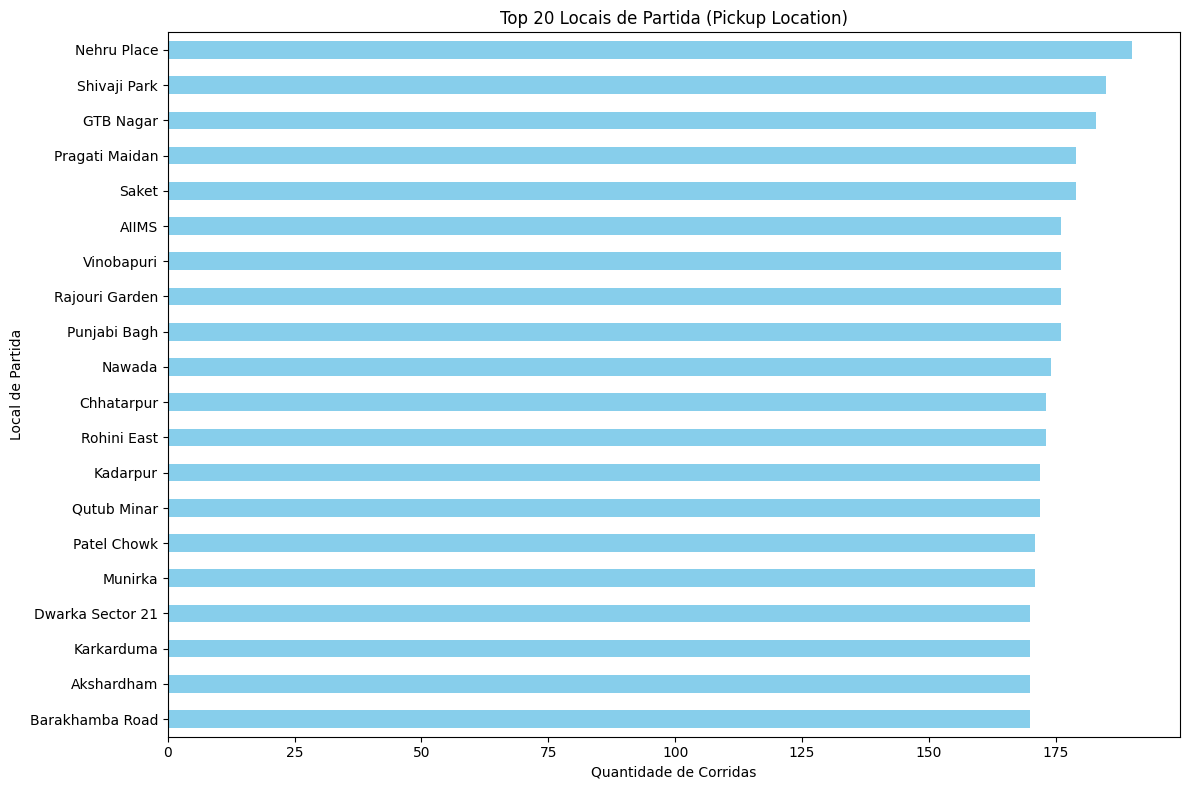

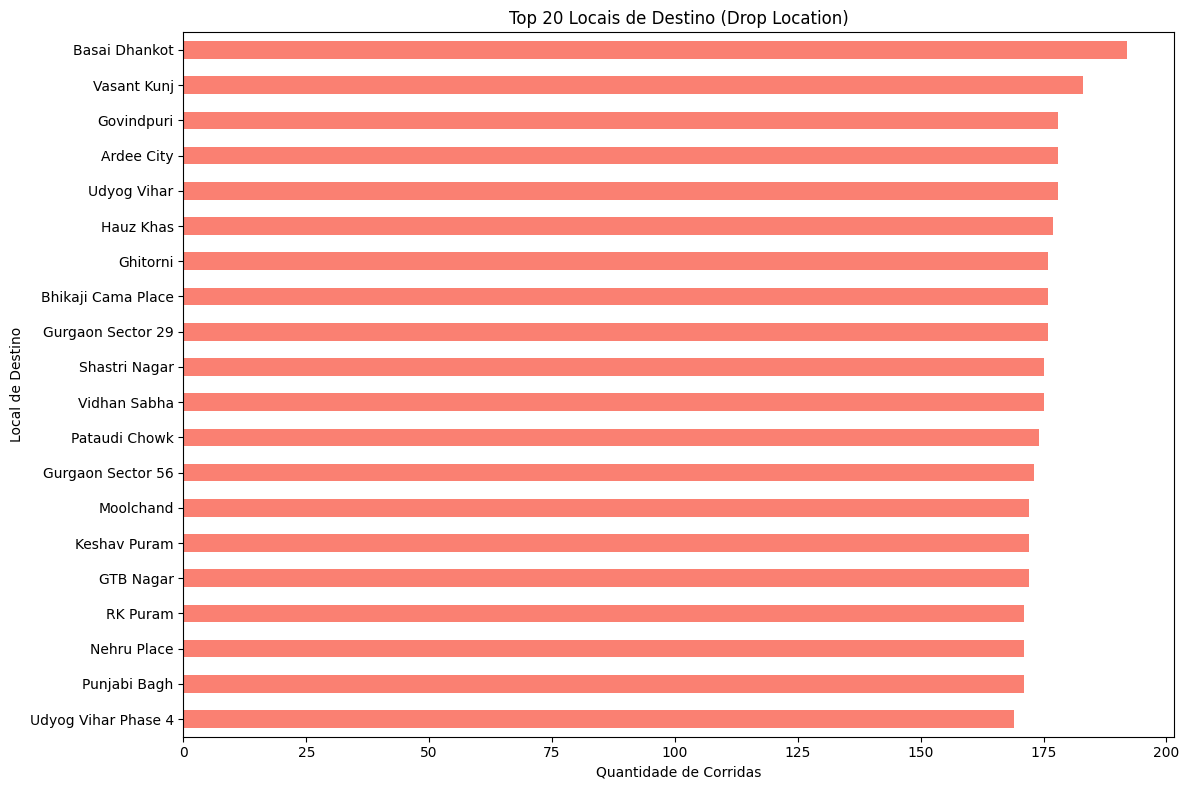

In [9]:
#Separando as top 20 maiores distribuições para entender se consigo dfazer algum agrupamento
top_20_pickup = df_filtrado['Pickup Location'].value_counts().nlargest(20)
print(top_20_pickup)


plt.figure(figsize=(12, 8))
top_20_pickup.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Top 20 Locais de Partida (Pickup Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Partida')
plt.tight_layout()

top_20_drop = df_filtrado['Drop Location'].value_counts().nlargest(20)
print(top_20_drop)
plt.figure(figsize=(12, 8))
top_20_drop.sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title('Top 20 Locais de Destino (Drop Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Destino')
plt.tight_layout()

Pickup Location
Seelampur              124
Ghitorni Village       125
Sadar Bazar Gurgaon    128
IMT Manesar            129
Kanhaiya Nagar         130
Old Gurgaon            131
Yamuna Bank            131
Hauz Khas              132
Jama Masjid            132
Peeragarhi             132
Welcome                132
Okhla                  133
Laxmi Nagar            133
Noida Sector 18        134
Arjangarh              135
Tis Hazari             136
Mandi House            136
Meerut                 136
Gurgaon Sector 29      136
Delhi Gate             136
Name: count, dtype: int64
Drop Location
Badarpur            125
Adarsh Nagar        125
Saket               127
Noida Extension     129
Aya Nagar           130
Pulbangash          130
Panchsheel Park     131
Preet Vihar         132
Okhla               133
Ghitorni Village    134
IFFCO Chowk         134
Pitampura           134
Tagore Garden       136
Lal Quila           137
Inderlok            137
Ramesh Nagar        137
India Gate          

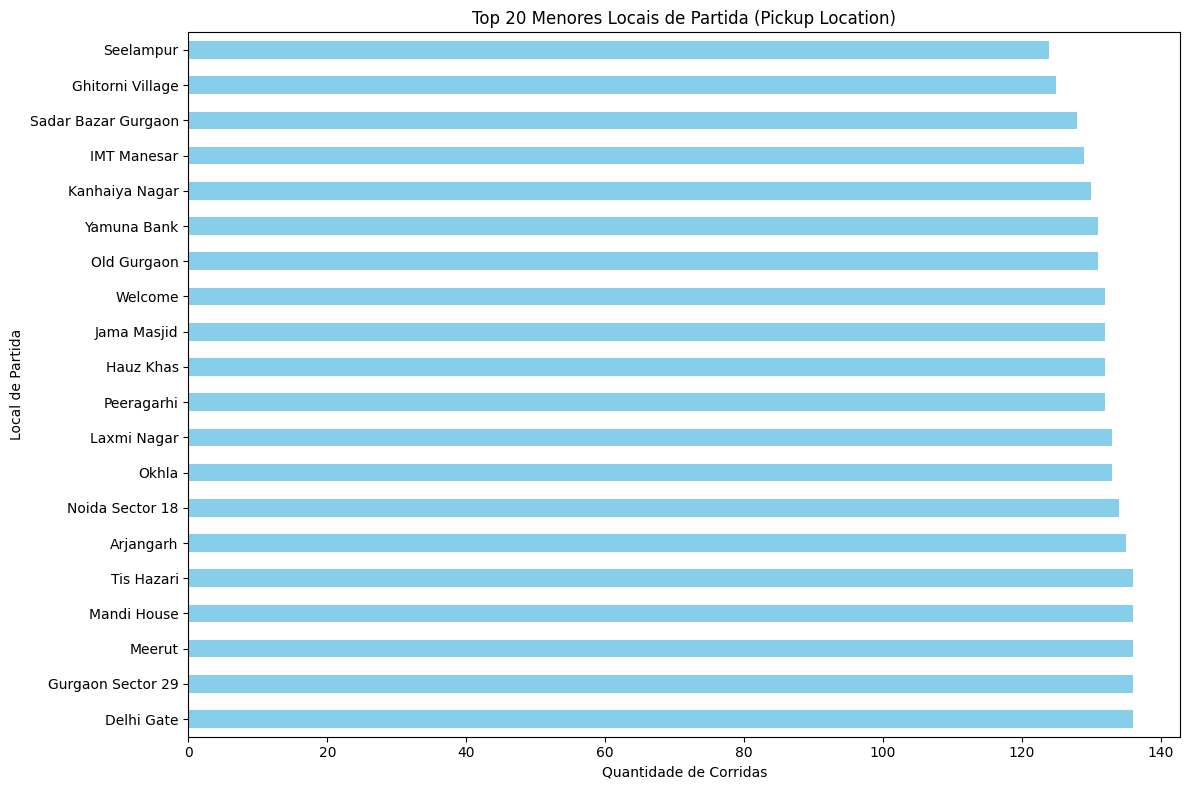

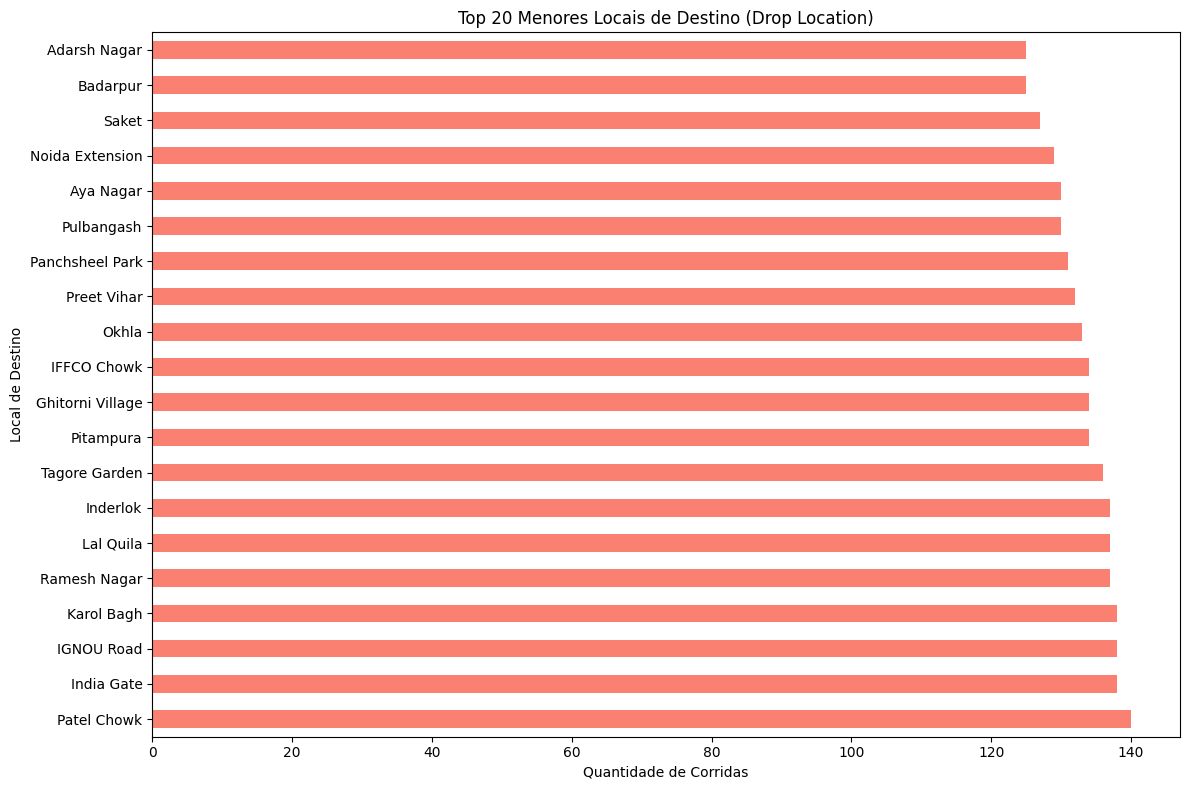

In [10]:
#Separando as top 20 maiores distribuições para entender se consigo dfazer algum agrupamento
top2_20_pickup = df_filtrado['Pickup Location'].value_counts().nsmallest(20)
print(top2_20_pickup)


plt.figure(figsize=(12, 8))
top2_20_pickup.sort_values(ascending=False).plot(kind='barh', color='skyblue')
plt.title('Top 20 Menores Locais de Partida (Pickup Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Partida')
plt.tight_layout()

top2_20_drop = df_filtrado['Drop Location'].value_counts().nsmallest(20)
print(top2_20_drop)
plt.figure(figsize=(12, 8))
top2_20_drop.sort_values(ascending=False).plot(kind='barh', color='salmon')
plt.title('Top 20 Menores Locais de Destino (Drop Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Destino')
plt.tight_layout()


print(df_filtrado['Driver Cancellation Reason'].value_counts())

#Terceiro diagnóstico
A análise dos dados de origem e destino não permitiu identificar um local específico com uma concentração atípica de cancelamentos. Caso um conjunto de locais se destacasse com um volume significativo de cancelamentos, seria possível agrupá-los para criar um novo atributo de análise.

Para aprofundar a investigação, é necessário avaliar se o número de cancelamentos é representativo em termos percentuais, comparando-o ao total de chamados de cada local. A hipótese é que, mesmo sem uma discrepância nos números absolutos, certos pontos de partida ou chegada podem apresentar uma taxa de cancelamento percentualmente elevada, o que os tornaria relevantes.


Também identificou-se os motivos de cancelamento.

| Motivo do Cancelamento | Quantidade |
| :--- | :--- |
| Customer related issue | 6837 |
| The customer was coughing/sick | 6751 |
| Personal & Car related issues | 6726 |
| More than permitted people in there | 6686 |

Em uma análise sobre os motivos, entende-se que o motivo de tosse/gripe é algo que depende do bom senso do cliente, acredita-se que não dá para prever esse bom senso e poderia ser resolvido com um aviso. Por conseguinte, na construção do modelo esses motivos serão eliminados da base de dados.

Sobre os problemas pessoais, embora o entendimento do analista seja de que possam ser causas aleatórias, os dados serão mantidos pois a aleatóriedade desses eventos podem ser relacionados com meses do ano ou horários específicos durante o dia.



Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
                   ... 
Mandi House         800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, Length: 176, dtype: int64
Cancelled Rides by Driver
0.0    123000
1.0     27000
Name: count, dtype: int64
                 total_rides  driver_cancellations
Pickup Location                                   
AIIMS                    918                 176.0
Adarsh Nagar             858                 141.0
Akshardham               839                 170.0
Ambience Mall            873                 151.0
Anand Vihar              859                 142.0
...                      ...                   ...
Vidhan Sabha             825                 154.0
Vinobapuri               823                 176.0
Vishwavidyalaya          895                 169.0
Welcome                  836            

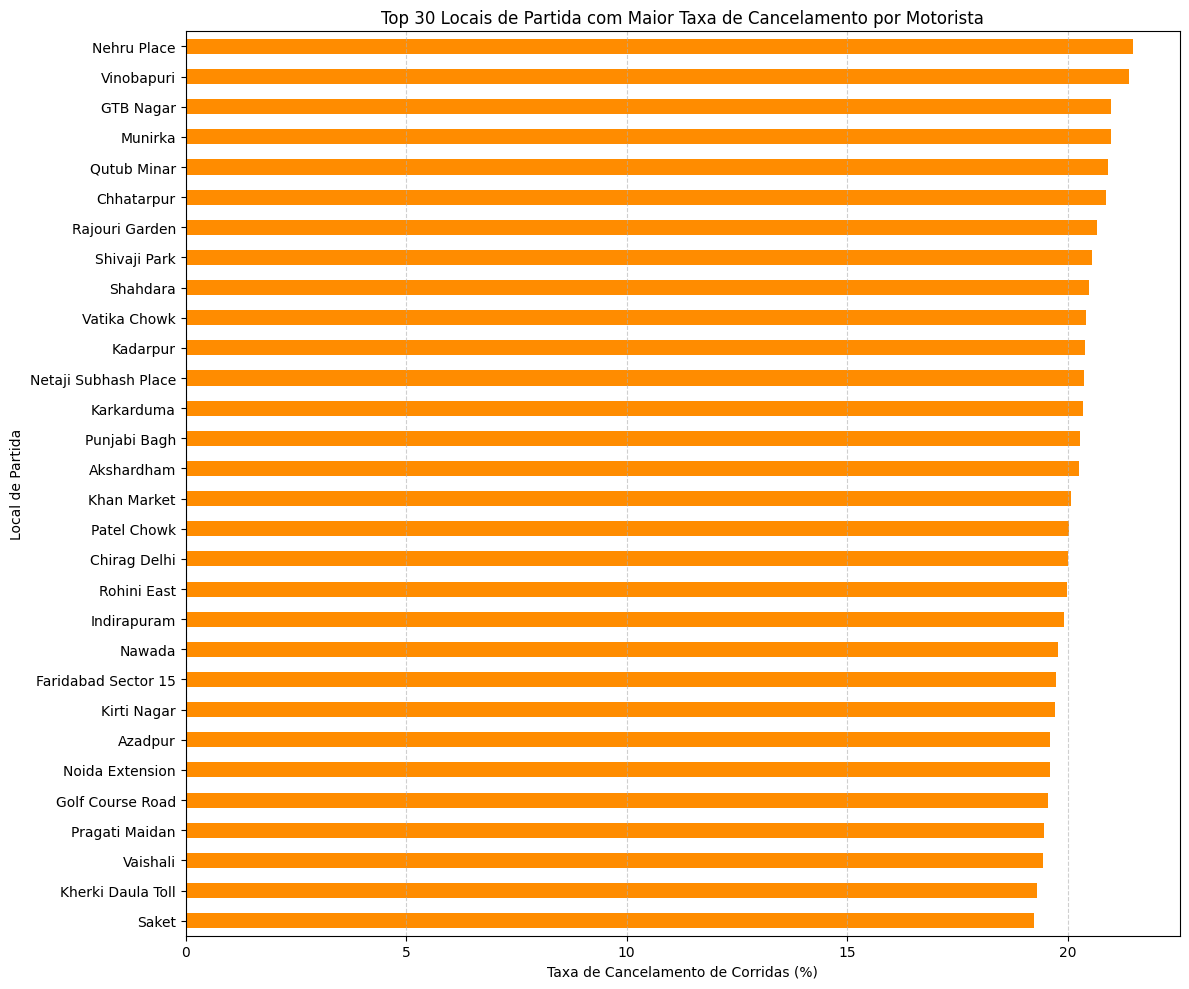

In [11]:
# Entendendo a quantidade de locais para identificar se há algum que não teve cancelamentos
print(df['Pickup Location'].value_counts())

#Criando outros dataframes para não afetar o original
df_calc = df.copy()
df_calc = df_calc.fillna(0)
print(df_calc['Cancelled Rides by Driver'].value_counts())

#Tratando os dados para plotar os 30 locais com mais cancelamentos em lista e em gráfico
location_stats = df_calc.groupby('Pickup Location').agg(
    total_rides=('Booking ID', 'count'),
    driver_cancellations=('Cancelled Rides by Driver', 'sum')
)
print(location_stats)
significant_locations = location_stats.copy()
significant_locations['cancellation_rate_percent_pickup'] =  (significant_locations['driver_cancellations'] / significant_locations['total_rides']) * 100
#print(significant_locations)
plt.figure(figsize=(12, 10))
top_30_locations = significant_locations.nlargest(30, 'cancellation_rate_percent_pickup')
top_30_locations['cancellation_rate_percent_pickup'].sort_values(ascending=True).plot(kind='barh', color='darkorange')
print(top_30_locations)


plt.title('Top 30 Locais de Partida com Maior Taxa de Cancelamento por Motorista')
plt.xlabel('Taxa de Cancelamento de Corridas (%)')
plt.ylabel('Local de Partida')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

#Plotando os 30 locais com menos cancelamentos para entender a faixa de cancelamento.
top2_30_locations = significant_locations.nsmallest(30, 'cancellation_rate_percent_pickup')
print(top2_30_locations)







#Quarto diagnóstico
Na análise identificou-se que todos os locais possuem taxas de cancelamento que variam de 14,5% até 21,5%. Nenhum local apresentou algum destaque que pudesse criar essa correlação, mas acredita-se que possa utilizar essa informação de taxa de cancelamento e vincular aos locais para treinar os modelos. Com isso, cria-se um novo atributo que representa a taxa de cancelamento daquele local de coleta.
A análise será replicada para os locais de entrega para criar uma taxa de cancelamento daquele local para em seguida fazer a limpeza dos dados e a identificação de correlação entre as variáveis.

Drop Location
Ashram              936
Basai Dhankot       917
Lok Kalyan Marg     916
Narsinghpur         913
Cyber Hub           912
                   ... 
MG Road             799
Bhiwadi             792
Shivaji Park        786
Anand Vihar ISBT    784
Huda City Centre    774
Name: count, Length: 176, dtype: int64
Cancelled Rides by Driver
0.0    123000
1.0     27000
Name: count, dtype: int64
                 total_rides  driver_cancellations
Drop Location                                     
AIIMS                    850                 166.0
Adarsh Nagar             845                 125.0
Akshardham               856                 153.0
Ambience Mall            836                 142.0
Anand Vihar              830                 157.0
...                      ...                   ...
Vidhan Sabha             868                 175.0
Vinobapuri               849                 163.0
Vishwavidyalaya          846                 147.0
Welcome                  848              

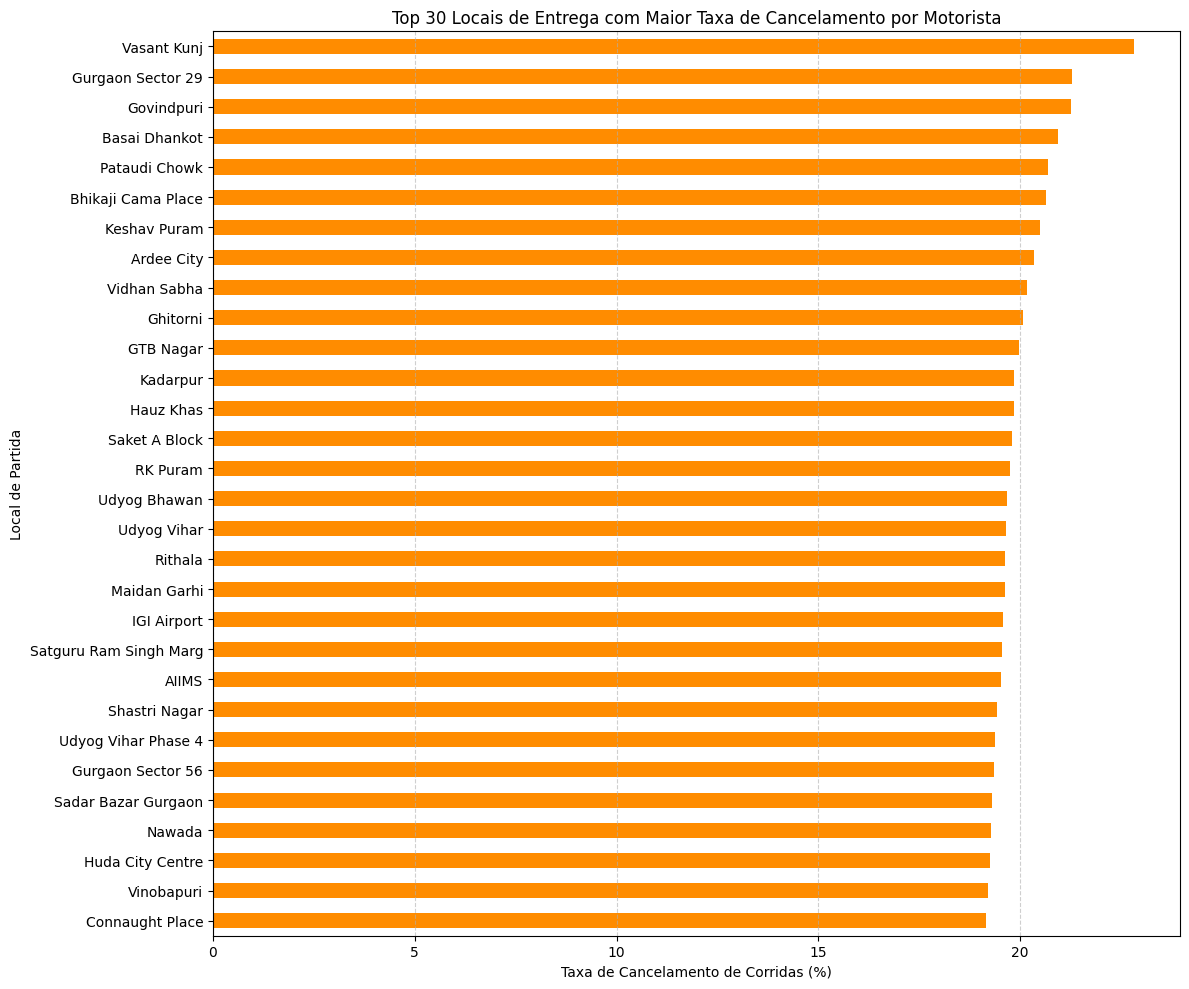

In [12]:
# Entendendo a quantidade de locais para identificar se há algum que não teve cancelamentos
print(df['Drop Location'].value_counts())

#Criando outros dataframes para não afetar o original
df_calc2 = df.copy()
df_calc2 = df_calc2.fillna(0)
print(df_calc2['Cancelled Rides by Driver'].value_counts())

#Tratando os dados para plotar os 30 locais com mais cancelamentos em lista e em gráfico
location_stats2 = df_calc2.groupby('Drop Location').agg(
    total_rides=('Booking ID', 'count'),
    driver_cancellations=('Cancelled Rides by Driver', 'sum')
)
print(location_stats2)
significant_locations2 = location_stats2.copy()
significant_locations2['cancellation_rate_percent_drop'] =  (significant_locations2['driver_cancellations'] / significant_locations2['total_rides']) * 100
#print(significant_locations)
plt.figure(figsize=(12, 10))
top_30_locations2 = significant_locations2.nlargest(30, 'cancellation_rate_percent_drop')
top_30_locations2['cancellation_rate_percent_drop'].sort_values(ascending=True).plot(kind='barh', color='darkorange')
print(top_30_locations2)


plt.title('Top 30 Locais de Entrega com Maior Taxa de Cancelamento por Motorista')
plt.xlabel('Taxa de Cancelamento de Corridas (%)')
plt.ylabel('Local de Partida')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

#Plotando os 30 locais com menos cancelamentos para entender a faixa de cancelamento.
top2_30_locations2 = significant_locations2.nsmallest(30, 'cancellation_rate_percent_drop')
print(top2_30_locations2)


# Finalização do entendimento dos dados
Com os resultados entende-se que não há nenhum local de entrega que não houve cancelamento e há um local específico que apresenta um destaque no gráfico mas pouco significante pois as taxas vão de 22,8% até o 14,8%. Com a criação de um novo atributo vínculado a taxa de cancelamento, entende-se que o modelo poderá se beneficiar no entendimento de locais de entrega com grande possibilidade de ter cancelamento.

#Próximos passos
* Preparar a base de dados que será utilizada para análise de correlação.
* Analisar a correlação entre as variáveis.
* Identificar quais variáveis possuem maior correlação para o modelo.
* Separar as amostras de treino e teste.
* Normalizar os dados.
* Treinar o modelo.
* Avaliar o resultado e identificar os próximos passos.

In [13]:
#União dos dados

#Criando a base de dados de referencia
df_model = df.copy()

#Correlacionando as taxas de cancelamento e os locais

#Avaliando e atualizando os locais de entrega
#print(significant_locations2.columns)
#print(significant_locations2.head())
significant_locations2.index.name = 'Drop Location'
significant_locations_reset2 = significant_locations2.reset_index()
#print(significant_locations_reset2.head())

df_model_merged = pd.merge(df_model, significant_locations_reset2[['Drop Location', 'cancellation_rate_percent_drop']], on='Drop Location', how='left')
#print(df_model_merged.head())

#Avaliando e atualizando os locais de coleta
#print(significant_locations.columns)
#print(significant_locations.head())
significant_locations.index.name = 'Pickup Location'
significant_locations_reset = significant_locations.reset_index()
df_model_merged = pd.merge(df_model_merged, significant_locations_reset[['Pickup Location', 'cancellation_rate_percent_pickup']], on='Pickup Location', how='left')
#print(df_model_merged.head())

#Avaliando se o "merge" deu certo
print(df_model_merged.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [14]:
#Filtro das informações para o modelo

#Aparentemente deu certo a substituição de todos os valores e agora vou eliminar os atributos que não são relevantes

columns_use = ['Date', 'Time', 'Vehicle Type', 'Avg VTAT','Driver Cancellation Reason','Cancelled Rides by Driver','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']
df_model_clean = df_model_merged[columns_use]
print(df_model_clean.info())


#Agora vou filtrar os valores do atributo 'Driver Cancellation Reason' que são referentes a gripe

df_model_clean = df_model_clean[df_model_clean['Driver Cancellation Reason'] != 'The customer was coughing/sick']

print(df_model_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Date                              150000 non-null  object 
 1   Time                              150000 non-null  object 
 2   Vehicle Type                      150000 non-null  object 
 3   Avg VTAT                          139500 non-null  float64
 4   Driver Cancellation Reason        27000 non-null   object 
 5   Cancelled Rides by Driver         27000 non-null   float64
 6   cancellation_rate_percent_drop    150000 non-null  float64
 7   cancellation_rate_percent_pickup  150000 non-null  float64
dtypes: float64(4), object(4)
memory usage: 9.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 143249 entries, 0 to 149999
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------             

#Preparo final para o tratamento

Para finalizar a preparação dos dados faltam as seguintes ações:


1.   Eliminar dados nulos do atributo "Avg VTAT".
2.   Converter atributo 'Date' em número.
3.   Converter atributo 'Time' em número.
4.   Converter atributo 'Vehicle Type' em dummies.
5.   Eliminar os atributos antigos desnecessários.



In [15]:
# Ação 1
df_model_clean = df_model_clean.dropna(subset=['Avg VTAT'])
print(df_model_clean.info())

#Ação 2
print(df_model_clean['Date'][1])
df_model_clean['Date'] = pd.to_datetime(df_model_clean['Date'], format='%Y-%m-%d')
print(df_model_clean.info())
print(df_model_clean['Date'][1])
df_model_clean['Date1'] = (df_model_clean['Date'].astype(np.int64) // 10**9)
print(df_model_clean.info())
print(df_model_clean['Date1'][1])

#Ação 3
print(df_model_clean['Time'][1])
df_model_clean['Time'] = pd.to_datetime(df_model_clean['Time'], format='%H:%M:%S')
print(df_model_clean.info())
print(df_model_clean['Time'][1])
df_model_clean['Time1'] = (df_model_clean['Time'].astype(np.int64) // 10**9)
print(df_model_clean.info())
print(df_model_clean['Time1'][1])

#Ação 4
df_model_clean = pd.get_dummies(df_model_clean, columns=['Vehicle Type'], prefix= 'Type')
print(df_model_clean.info())

#Ação 5

columns_use2 = ['Date1', 'Time1', 'Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','Cancelled Rides by Driver','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']
df_model_clean2 = df_model_clean[columns_use2].copy()
print(df_model_clean2.info())


<class 'pandas.core.frame.DataFrame'>
Index: 132749 entries, 1 to 149999
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Date                              132749 non-null  object 
 1   Time                              132749 non-null  object 
 2   Vehicle Type                      132749 non-null  object 
 3   Avg VTAT                          132749 non-null  float64
 4   Driver Cancellation Reason        20249 non-null   object 
 5   Cancelled Rides by Driver         20249 non-null   float64
 6   cancellation_rate_percent_drop    132749 non-null  float64
 7   cancellation_rate_percent_pickup  132749 non-null  float64
dtypes: float64(4), object(4)
memory usage: 9.1+ MB
None
2024-11-29
<class 'pandas.core.frame.DataFrame'>
Index: 132749 entries, 1 to 149999
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------

#Análise exploratória dos dados tratados
Depois da limpeza dos dados avaliaram-se as distribuições e as correlações dos atributos com o objetivo de identificar quais possuem maior correlação com o cancelamento das corridas pelos motoristas.


Com essa parte entende-se que a etapa de "Carga e preparação está concluída"✅


--- Correlação dos Atributos com 'Cancelled Rides by Driver' ---
Cancelled Rides by Driver           1.000000
cancellation_rate_percent_pickup    0.035255
cancellation_rate_percent_drop      0.031735
Type_Go Sedan                       0.006753
Type_eBike                          0.001204
Type_Premier Sedan                  0.000956
Time1                               0.000578
Type_Uber XL                       -0.000618
Type_Bike                          -0.001168
Date1                              -0.001939
Type_Go Mini                       -0.002969
Avg VTAT                           -0.112498
Name: Cancelled Rides by Driver, dtype: float64


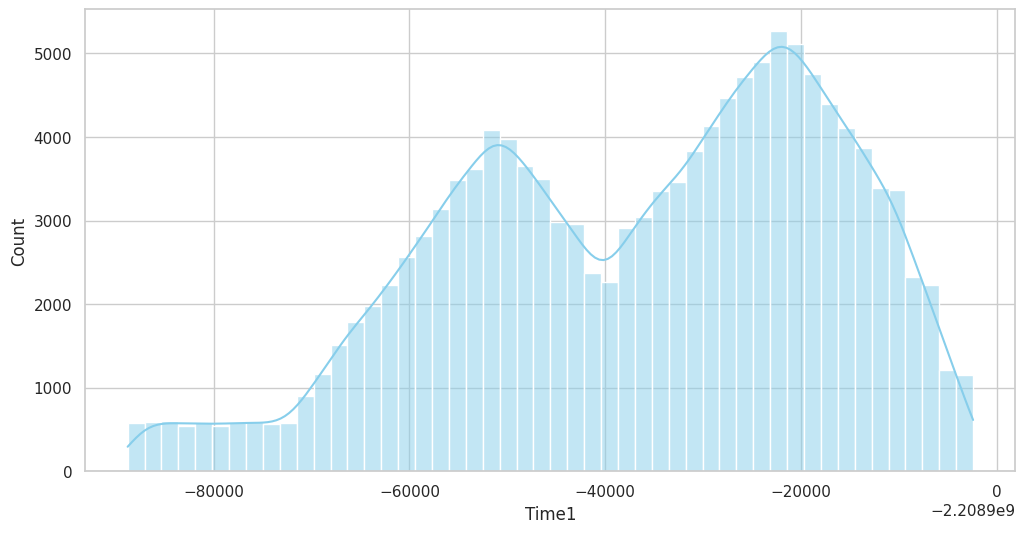

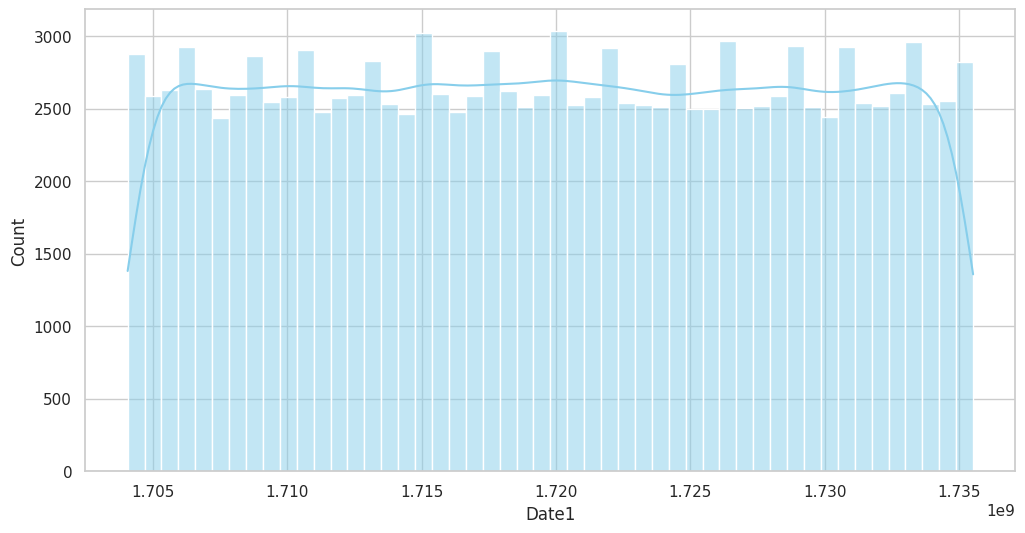

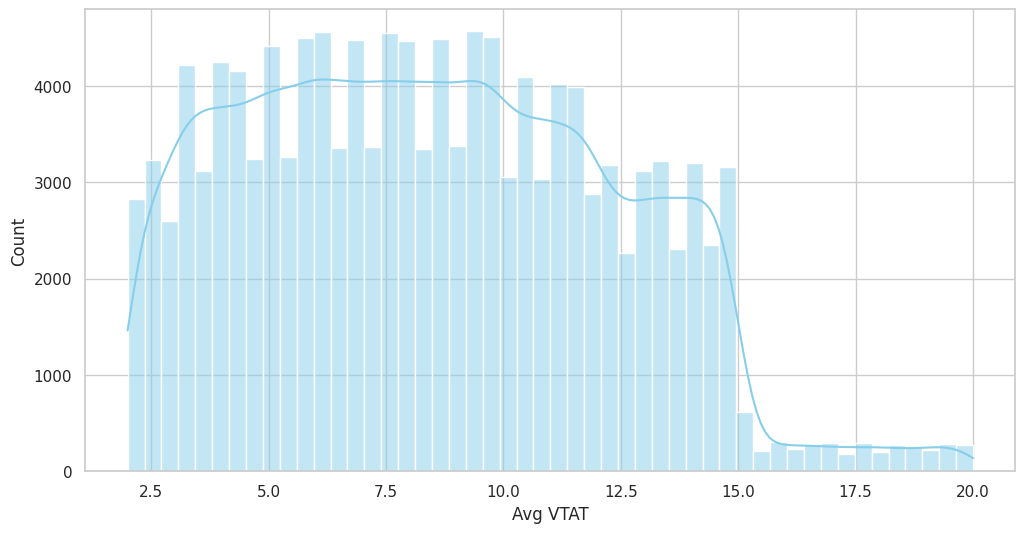

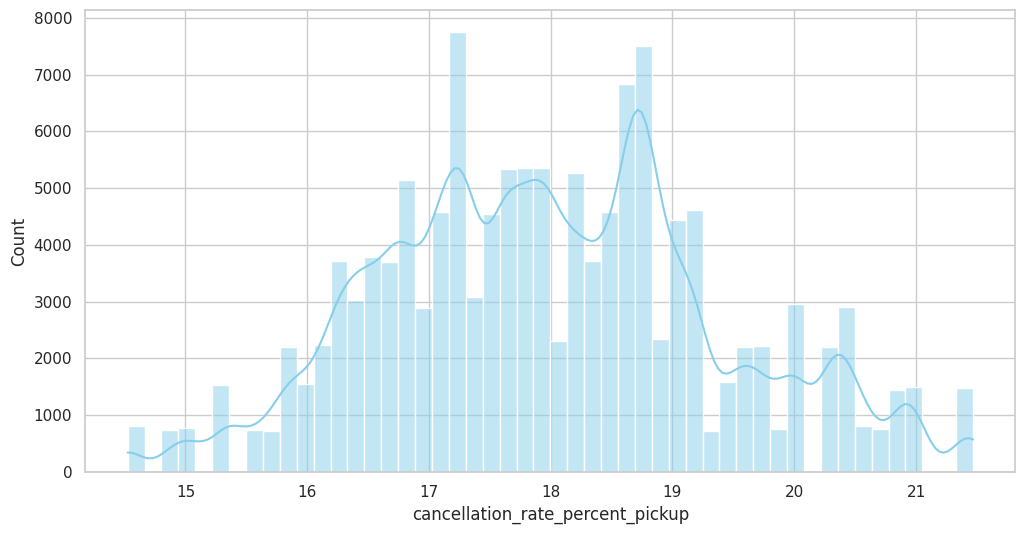

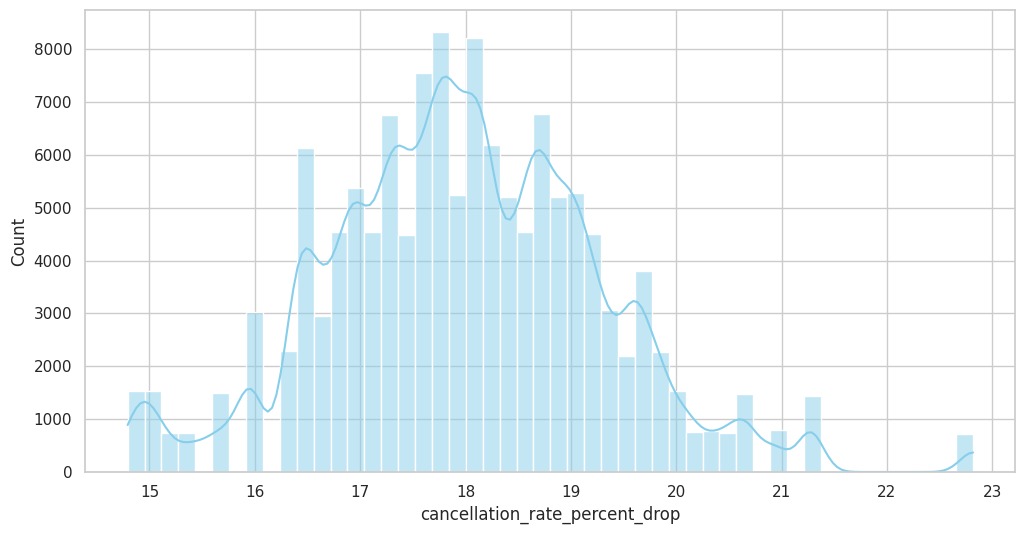

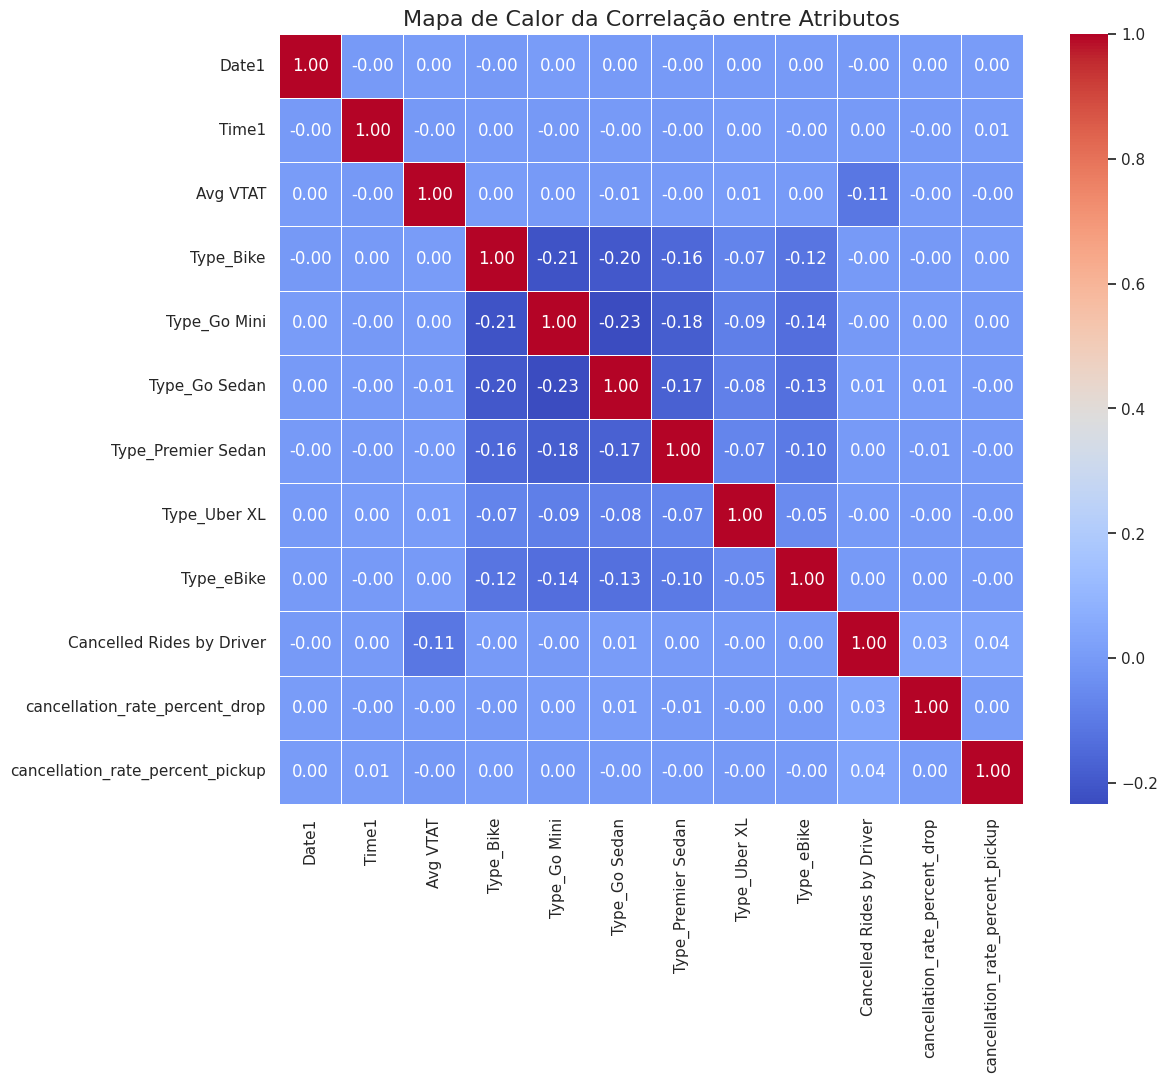

In [16]:
# Verificando o comportamento dos atributos

# Plotando as horas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['Time1'], kde=True, bins=50, color='skyblue')

# Plotando os dias
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['Date1'], kde=True, bins=50, color='skyblue')

# Plotando os tempos médios
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['Avg VTAT'], kde=True, bins=50, color='skyblue')

# Plotando os cancelamentos de coleta
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['cancellation_rate_percent_pickup'], kde=True, bins=50, color='skyblue')

# Plotando os cancelamentos de entrega
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['cancellation_rate_percent_drop'], kde=True, bins=50, color='skyblue')

#Preparo de dados para correlação
df_model_clean2['Cancelled Rides by Driver'] = df_model_clean2['Cancelled Rides by Driver'].fillna(0)
for col in df_model_clean2.columns:
    if df_model_clean2[col].dtype == 'bool':
        df_model_clean2[col] = df_model_clean2[col].astype(int)

df_model_clean2['Cancelled Rides by Driver'] = df_model_clean2['Cancelled Rides by Driver'].astype(int)

matriz_correlacao = df_model_clean2.corr()
correlacao_com_alvo = matriz_correlacao['Cancelled Rides by Driver']
correlacao_com_alvo_ordenada = correlacao_com_alvo.sort_values(ascending=False)
print("\n--- Correlação dos Atributos com 'Cancelled Rides by Driver' ---")
print(correlacao_com_alvo_ordenada)

plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(matriz_correlacao,annot=True,cmap='coolwarm',fmt=".2f",linewidths=.5)

plt.title('Mapa de Calor da Correlação entre Atributos', fontsize=16)
plt.show()

#Finalização da análise exploratória
Nenhum atributo apresentou um comportamento de curva semelhante a uma curva normal. O mais próximo foi a taxa de cancelamento de entrega mas a curva não possui simetria construtiva. Os dados aparesentaram correlações muito baixas, sendo que apenas o tempo de espera, tipo sedan e as taxas de cancelamento não zeraram. Assumindo que o objetivo final é gerar um modelo que gere algum resultado que auxilie na prevenção dos cancelamentos vamos dar continuidade no processo preparando as amostras que serão utilizadas.

In [17]:
print(df_model_clean2.head())
# Separar features (X) e target (y)
X = df_model_clean2[['Date1', 'Time1', 'Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']]
y = df_model_clean2['Cancelled Rides by Driver']
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")




        Date1       Time1  Avg VTAT  Type_Bike  Type_Go Mini  Type_Go Sedan  \
1  1732838400 -2208923901       4.9          0             0              1   
2  1724371200 -2208956630      13.4          0             0              0   
3  1729468800 -2208926555      13.1          0             0              0   
4  1726444800 -2208909120       5.3          1             0              0   
5  1707177600 -2208953704       5.1          0             0              0   

   Type_Premier Sedan  Type_Uber XL  Type_eBike  Cancelled Rides by Driver  \
1                   0             0           0                          0   
2                   0             0           0                          0   
3                   1             0           0                          0   
4                   0             0           0                          0   
5                   0             0           0                          0   

   cancellation_rate_percent_drop  cancellation_rate_per

#Avaliação prévia de modelos
Para entender os efeitos dos atributos, vou iniciar o treinamento de alguns modelos conhecidos na disciplina.
Nessa avaliação os dados foram testados originais, normalizados e padronizados, seguindo a mesma linha de raciocínio do exercício. A opinião do analista, com base na distribuição dos dados, o mais adequado seria a normalização, pois nenhum dado apresentou uma característica visual semelhante a uma curva normal, mas a fim de análise utilizaram-se as três alternativas.

Para essa análise foi feita uma alteração no critério de avaliação. Optou-se por medir o f1, precisão e recall para avaliar os valores pois é sabido que há uma possibilidade do modelo ficar enviesado por conta do desbalanceamento dos dados().

Avaliando que essa análise poderá ser repetida, primeiramente será feita a conversão do código aprendido em aula em uma função. Após serão avaliados os dados.

#Métricas
Com o objetivo de identificar cancelamentos, utilizaram-se duas variáveis. A primeira foi "f1" pois ela é uma métrica equilibrada em relação a "precisão" e o "recall", e a segunda será o "recall" pois o objetivo é encontrar as condições com maior risco de cancelamento.

#

In [18]:
# É sabido que essa função não vai salvar o modelo, portanto a estratégia adotada será investigar possibilidades e ao final gerar um modelo para salva-lo.
def executar_comparacao_modelos(X, y, models, scalers=None, kfold=None, scoring=None, plotar_resultados=True):

    #Define se alguma variável de entrada alterou
    if scalers is None:
        scalers = {}

    scalers_a_usar = {'orig': None}
    scalers_a_usar.update(scalers)

    if kfold is None:
        kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

    if scoring is None:
        scoring = ['f1_macro', 'precision_macro', 'recall_macro']


    results_list = []
    print("Iniciando comparação de modelos...")

    #Analisa os modelos
    for model_name, model_obj in models.items():
        for scaler_name, scaler_obj in scalers_a_usar.items():

            pipeline_steps = []
            if scaler_obj is not None:
                pipeline_steps.append((scaler_name, scaler_obj))
            pipeline_steps.append((model_name, model_obj))
            pipeline = Pipeline(steps=pipeline_steps)
            pipeline_full_name = f"{model_name}-{scaler_name}"
            cv_results = cross_validate(pipeline, X, y, cv=kfold, scoring=scoring)
            print(f"--- {pipeline_full_name} ---")

            result_summary = {'pipeline_name': pipeline_full_name}

            for metric in scoring:
                mean_score = cv_results[f'test_{metric}'].mean()
                std_score = cv_results[f'test_{metric}'].std()
                result_summary[f'mean_{metric}'] = mean_score
                result_summary[f'std_{metric}'] = std_score
                result_summary[f'raw_{metric}'] = cv_results[f'test_{metric}']
                print(f"  {metric}: {mean_score:.3f} ({std_score:.3f})")

            results_list.append(result_summary)

    print("\nComparação finalizada!")
    results_df = pd.DataFrame(results_list)

    #Gera o gráfico para comparar
    if plotar_resultados:
        print("Gerando gráficos...")
        for metric in scoring:

            data_to_plot = results_df[f'raw_{metric}'].tolist()
            labels = results_df['pipeline_name'].tolist()
            plt.figure(figsize=(25, 8))
            plt.suptitle(f'Comparação dos Modelos ({metric})', fontsize=16)
            plt.boxplot(data_to_plot)
            plt.xticks(ticks=range(1, len(labels) + 1), labels=labels, rotation=90)
            plt.ylabel(metric.replace('_', ' ').title())
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

    return results_df




Iniciando comparação de modelos...
--- LR-orig ---
  f1_macro: 0.459 (0.000)
  precision_macro: 0.424 (0.000)
  recall_macro: 0.500 (0.000)
--- LR-padr ---
  f1_macro: 0.459 (0.000)
  precision_macro: 0.424 (0.000)
  recall_macro: 0.500 (0.000)
--- LR-norm ---
  f1_macro: 0.459 (0.000)
  precision_macro: 0.424 (0.000)
  recall_macro: 0.500 (0.000)
--- KNN-orig ---
  f1_macro: 0.474 (0.002)
  precision_macro: 0.493 (0.007)
  recall_macro: 0.499 (0.001)
--- KNN-padr ---
  f1_macro: 0.496 (0.003)
  precision_macro: 0.529 (0.007)
  recall_macro: 0.509 (0.002)
--- KNN-norm ---
  f1_macro: 0.495 (0.003)
  precision_macro: 0.526 (0.008)
  recall_macro: 0.508 (0.002)
--- CART-orig ---
  f1_macro: 0.538 (0.004)
  precision_macro: 0.536 (0.004)
  recall_macro: 0.540 (0.004)
--- CART-padr ---
  f1_macro: 0.533 (0.006)
  precision_macro: 0.532 (0.006)
  recall_macro: 0.535 (0.007)
--- CART-norm ---
  f1_macro: 0.535 (0.005)
  precision_macro: 0.534 (0.005)
  recall_macro: 0.537 (0.005)
--- NB-orig

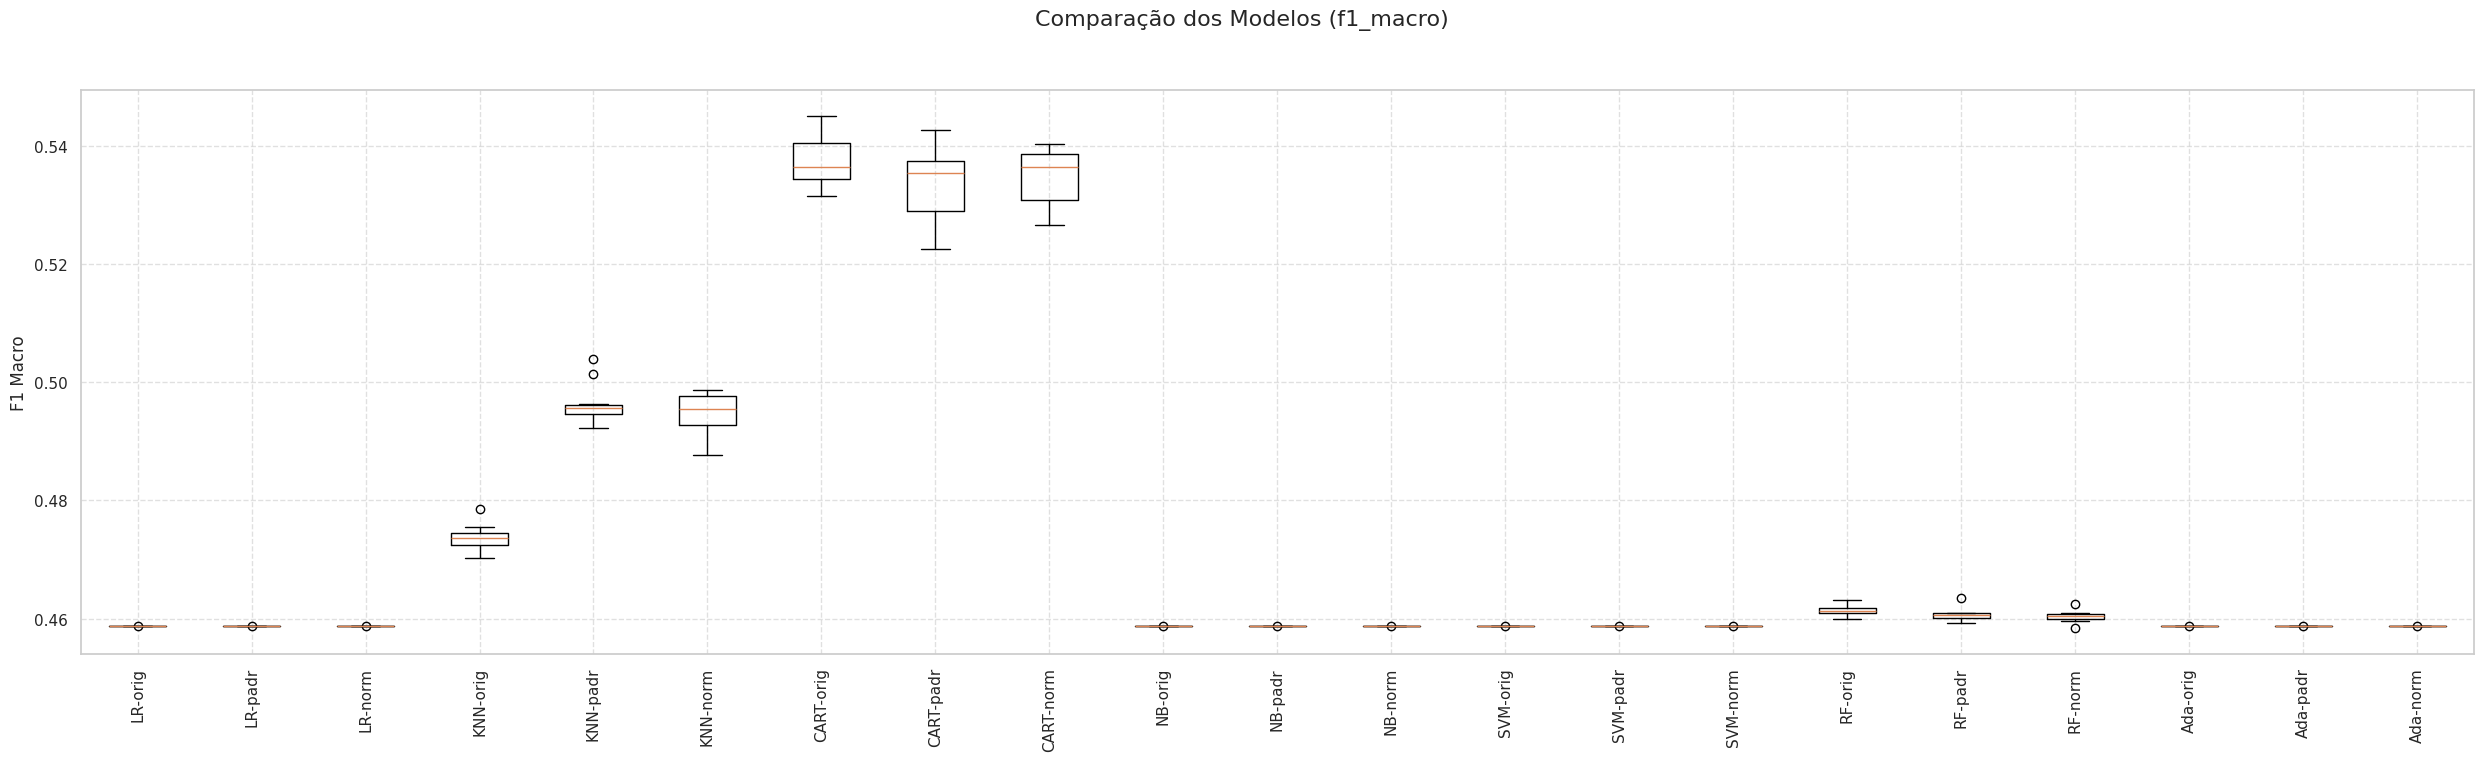

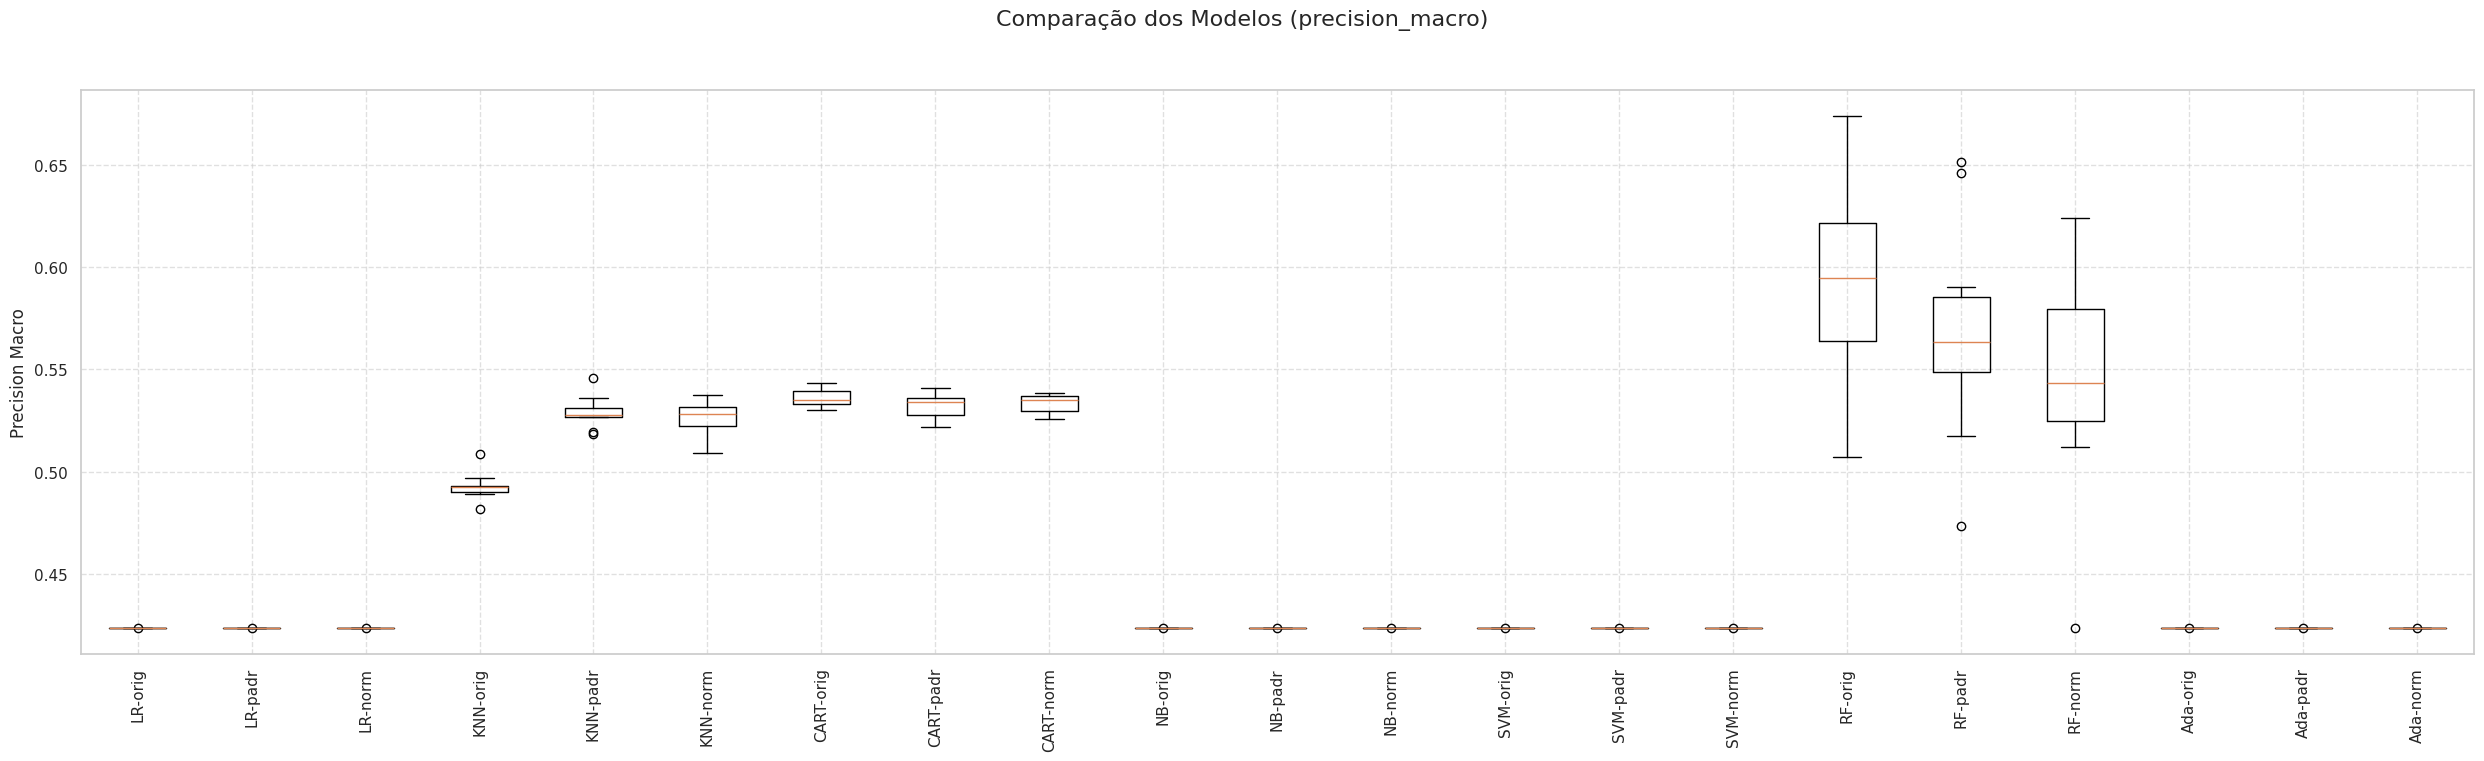

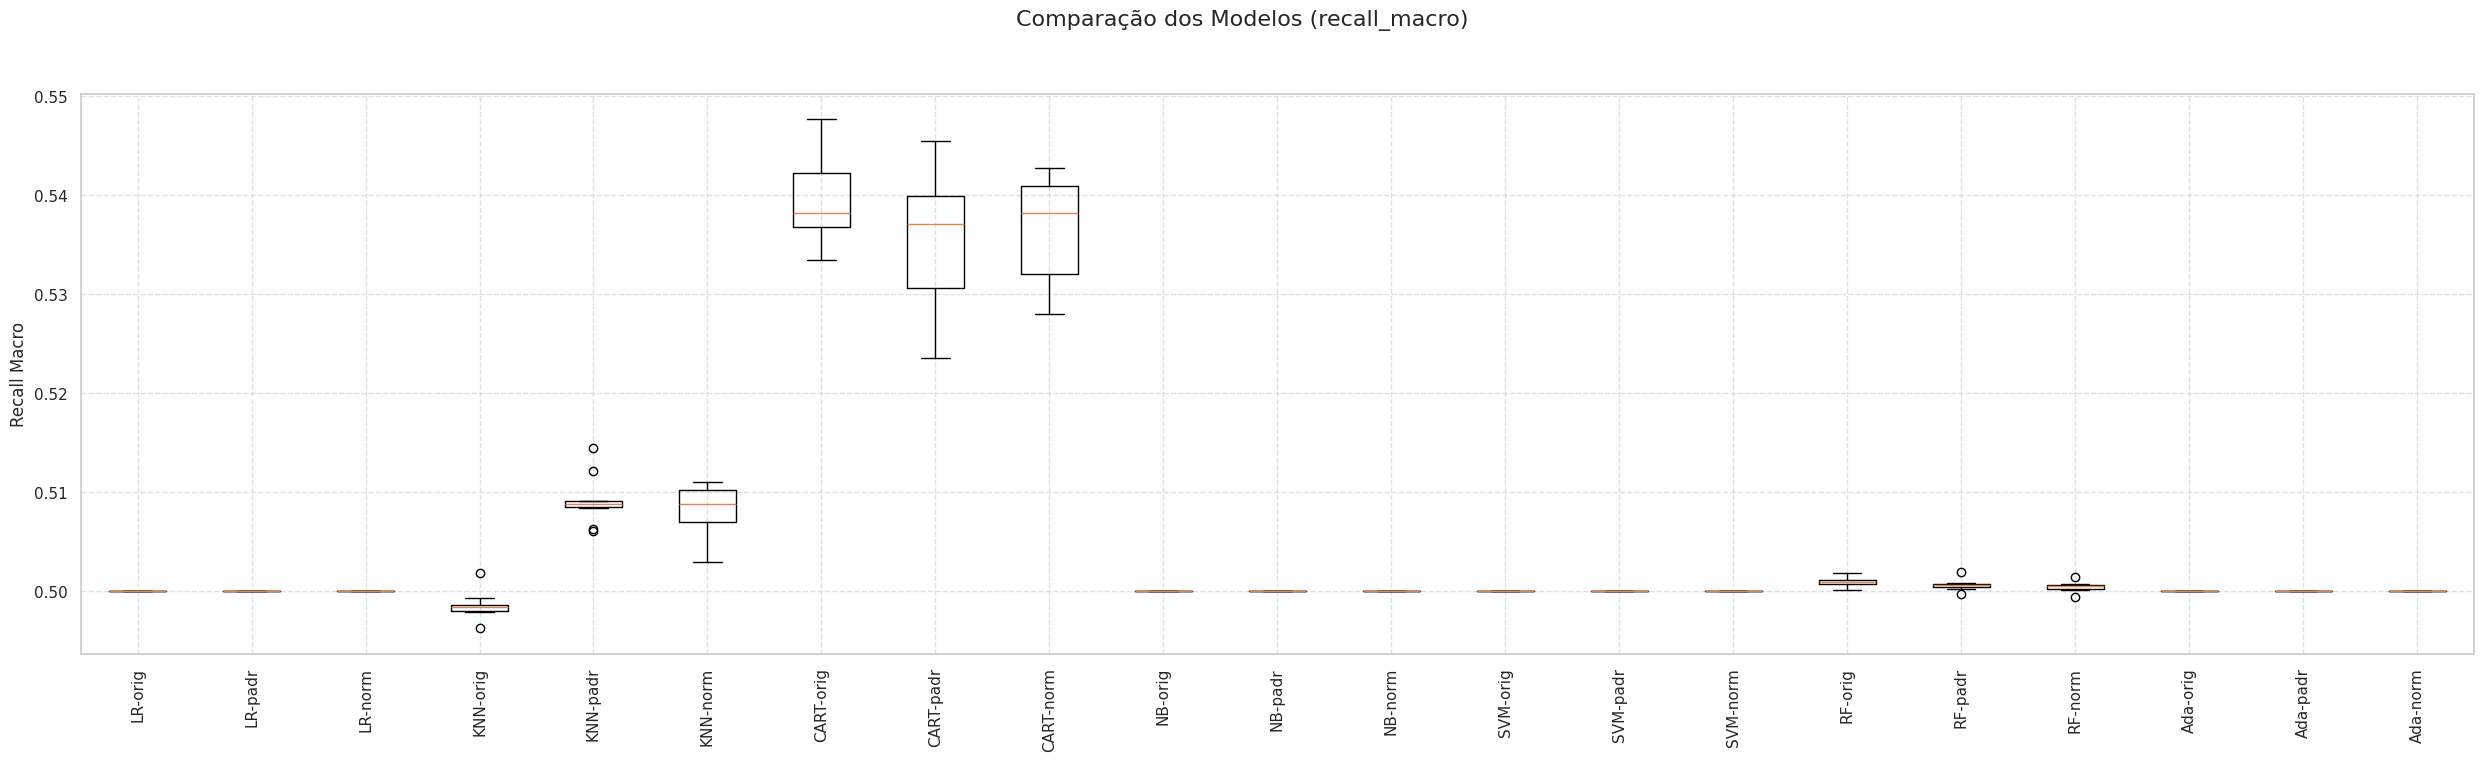

   pipeline_name  mean_f1_macro  mean_precision_macro  mean_recall_macro
0        LR-orig       0.458717              0.423732           0.500000
1        LR-padr       0.458717              0.423732           0.500000
2        LR-norm       0.458717              0.423732           0.500000
3       KNN-orig       0.473773              0.492827           0.498514
4       KNN-padr       0.496278              0.529075           0.509156
5       KNN-norm       0.494853              0.526401           0.508243
6      CART-orig       0.537541              0.536267           0.539618
7      CART-padr       0.533337              0.532181           0.535355
8      CART-norm       0.534820              0.533659           0.536711
9        NB-orig       0.458717              0.423732           0.500000
10       NB-padr       0.458717              0.423732           0.500000
11       NB-norm       0.458717              0.423732           0.500000
12      SVM-orig       0.458717              0.4237

In [ ]:


#Bloqueado por demorar demais
# base_decision_tree = DecisionTreeClassifier()
# num_trees = 100
# models_to_compare = {
#     'LR': LogisticRegression(max_iter=200),
#     'KNN': KNeighborsClassifier(),
#     'CART': DecisionTreeClassifier(),
#     'NB': GaussianNB(),
#     'SVM': SVC(),
#     'RF': RandomForestClassifier(n_estimators=num_trees),
#     'Ada': AdaBoostClassifier(n_estimators=num_trees)
# }

# scalers_to_compare = {
#     'padr': StandardScaler(),
#     'norm': MinMaxScaler()
# }

# df_resultados = executar_comparacao_modelos(X, y, models=models_to_compare, scalers=scalers_to_compare)

# colunas_resumo = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados[colunas_resumo])



#Resultados parciais

## Tabela de Resultados dos Modelos

| **Modelo** | **F1-Score (macro)** | **Precision (macro)** | **Recall (macro)** |
|:---|:---:|:---:|:---:|
| LR-orig | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| LR-padr | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| LR-norm | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| KNN-orig | 0.474 (0.002) | 0.493 (0.007) | 0.499 (0.001) |
| KNN-padr | 0.496 (0.003) | 0.529 (0.007) | 0.509 (0.002) |
| KNN-norm | 0.495 (0.003) | 0.526 (0.008) | 0.508 (0.002) |
| CART-orig | 0.538 (0.004) | 0.536 (0.004) | 0.540 (0.004) |
| CART-padr | 0.533 (0.006) | 0.532 (0.006) | 0.535 (0.007) |
| CART-norm | 0.535 (0.005) | 0.534 (0.005) | 0.537 (0.005) |
| NB-orig | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| NB-padr | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| NB-norm | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| SVM-orig | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| SVM-padr | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| SVM-norm | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| RF-orig | 0.461 (0.001) | 0.592 (0.043) | 0.501 (0.000) |
| RF-padr | 0.461 (0.001) | 0.567 (0.051) | 0.501 (0.001) |
| RF-norm | 0.460 (0.001) | 0.545 (0.052) | 0.500 (0.001) |
| Ada-orig | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| Ada-padr | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| Ada-norm | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |




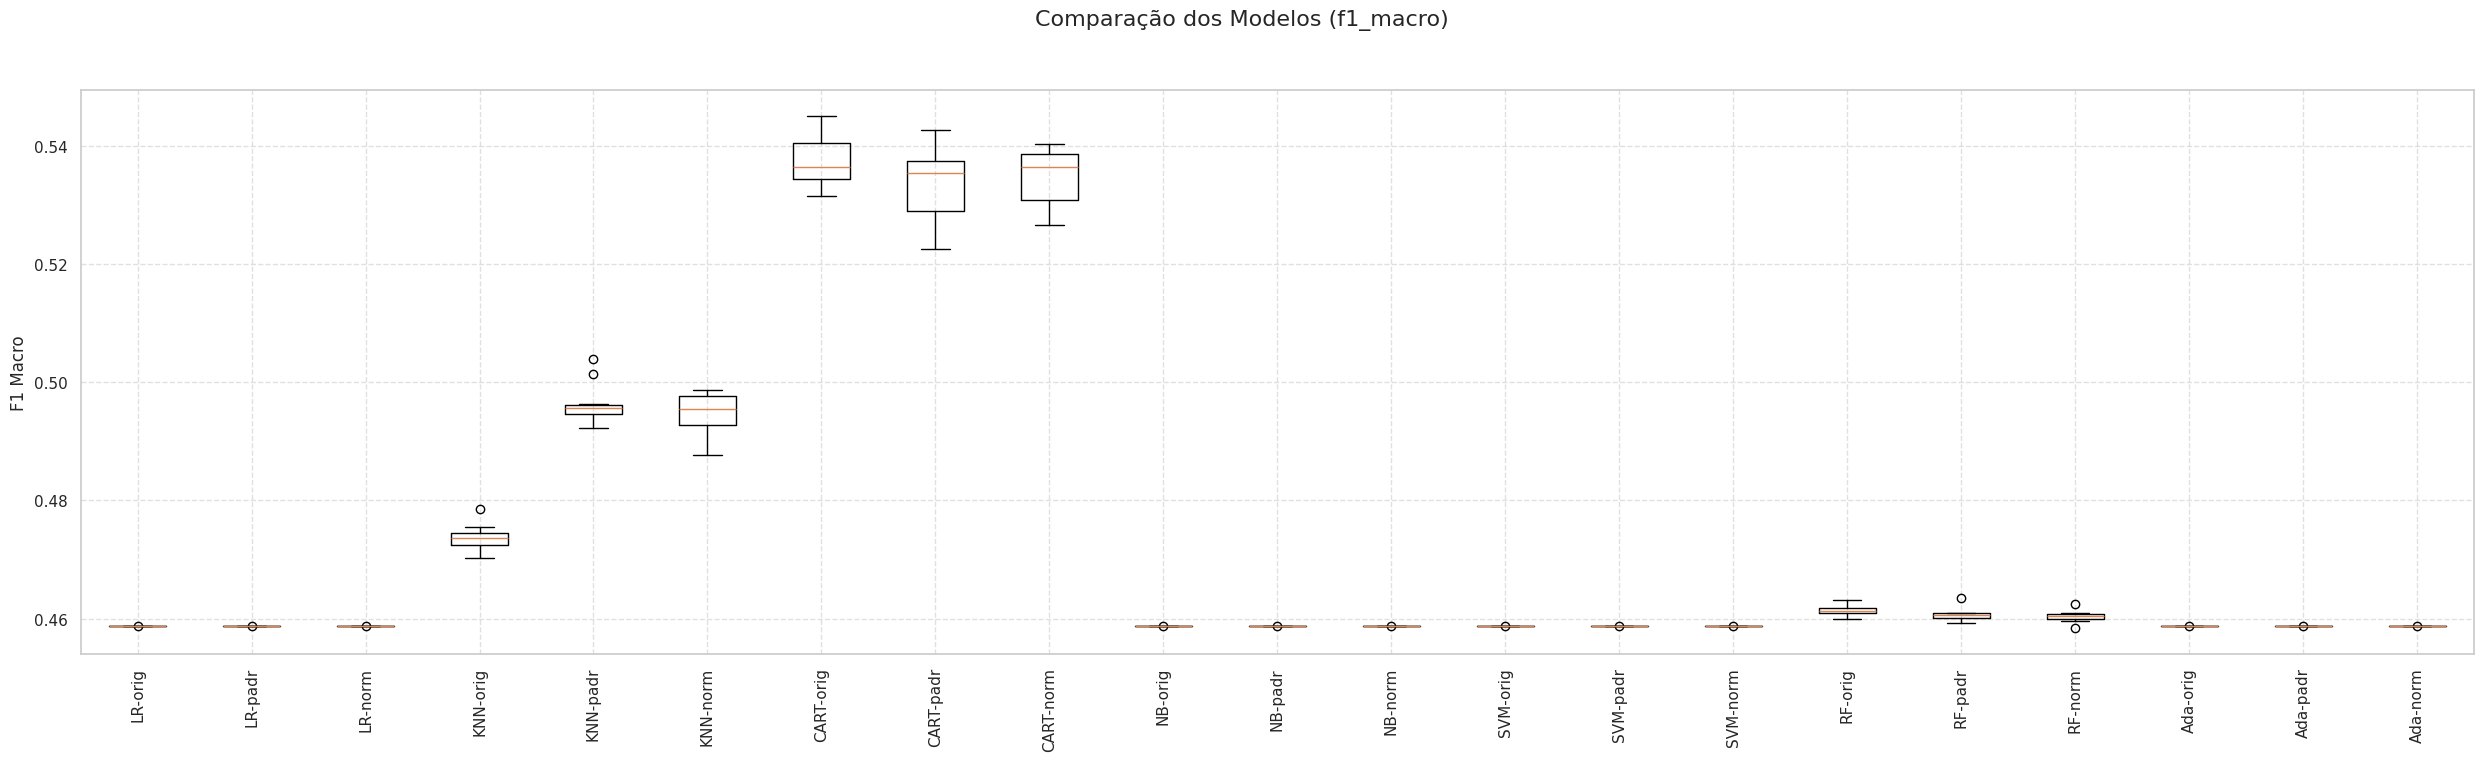

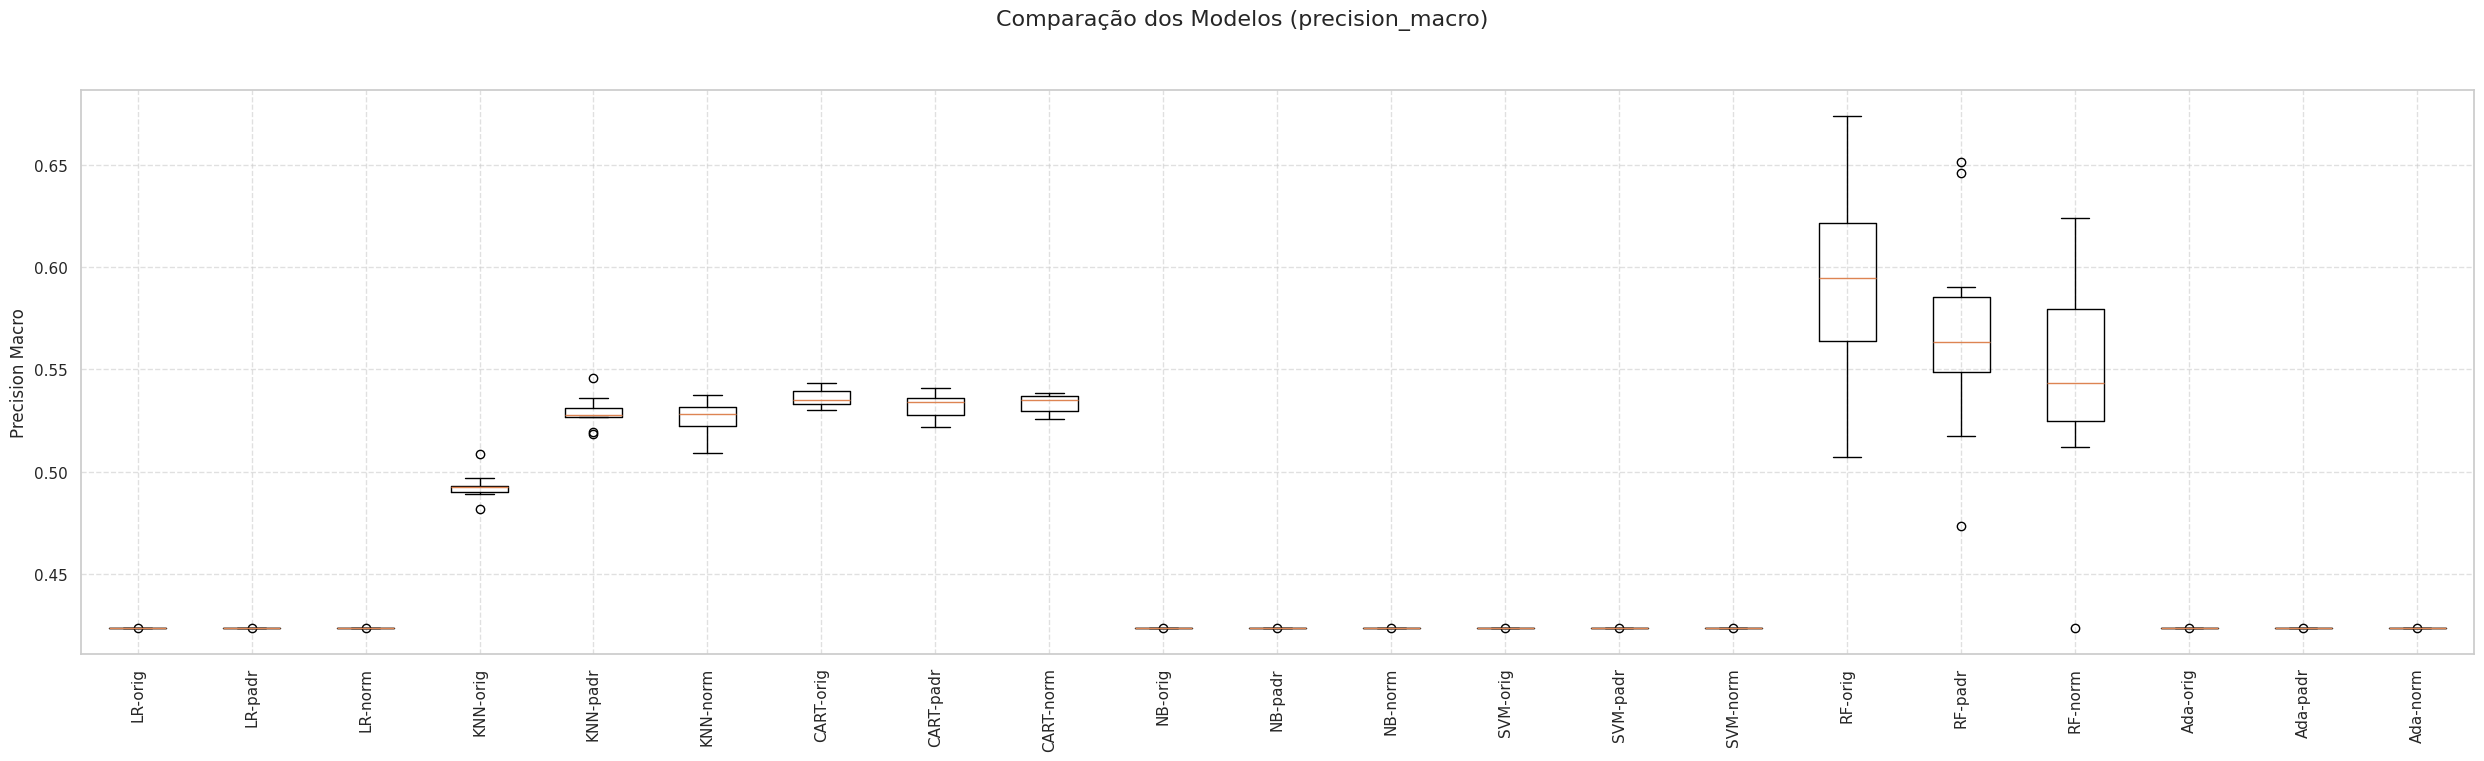

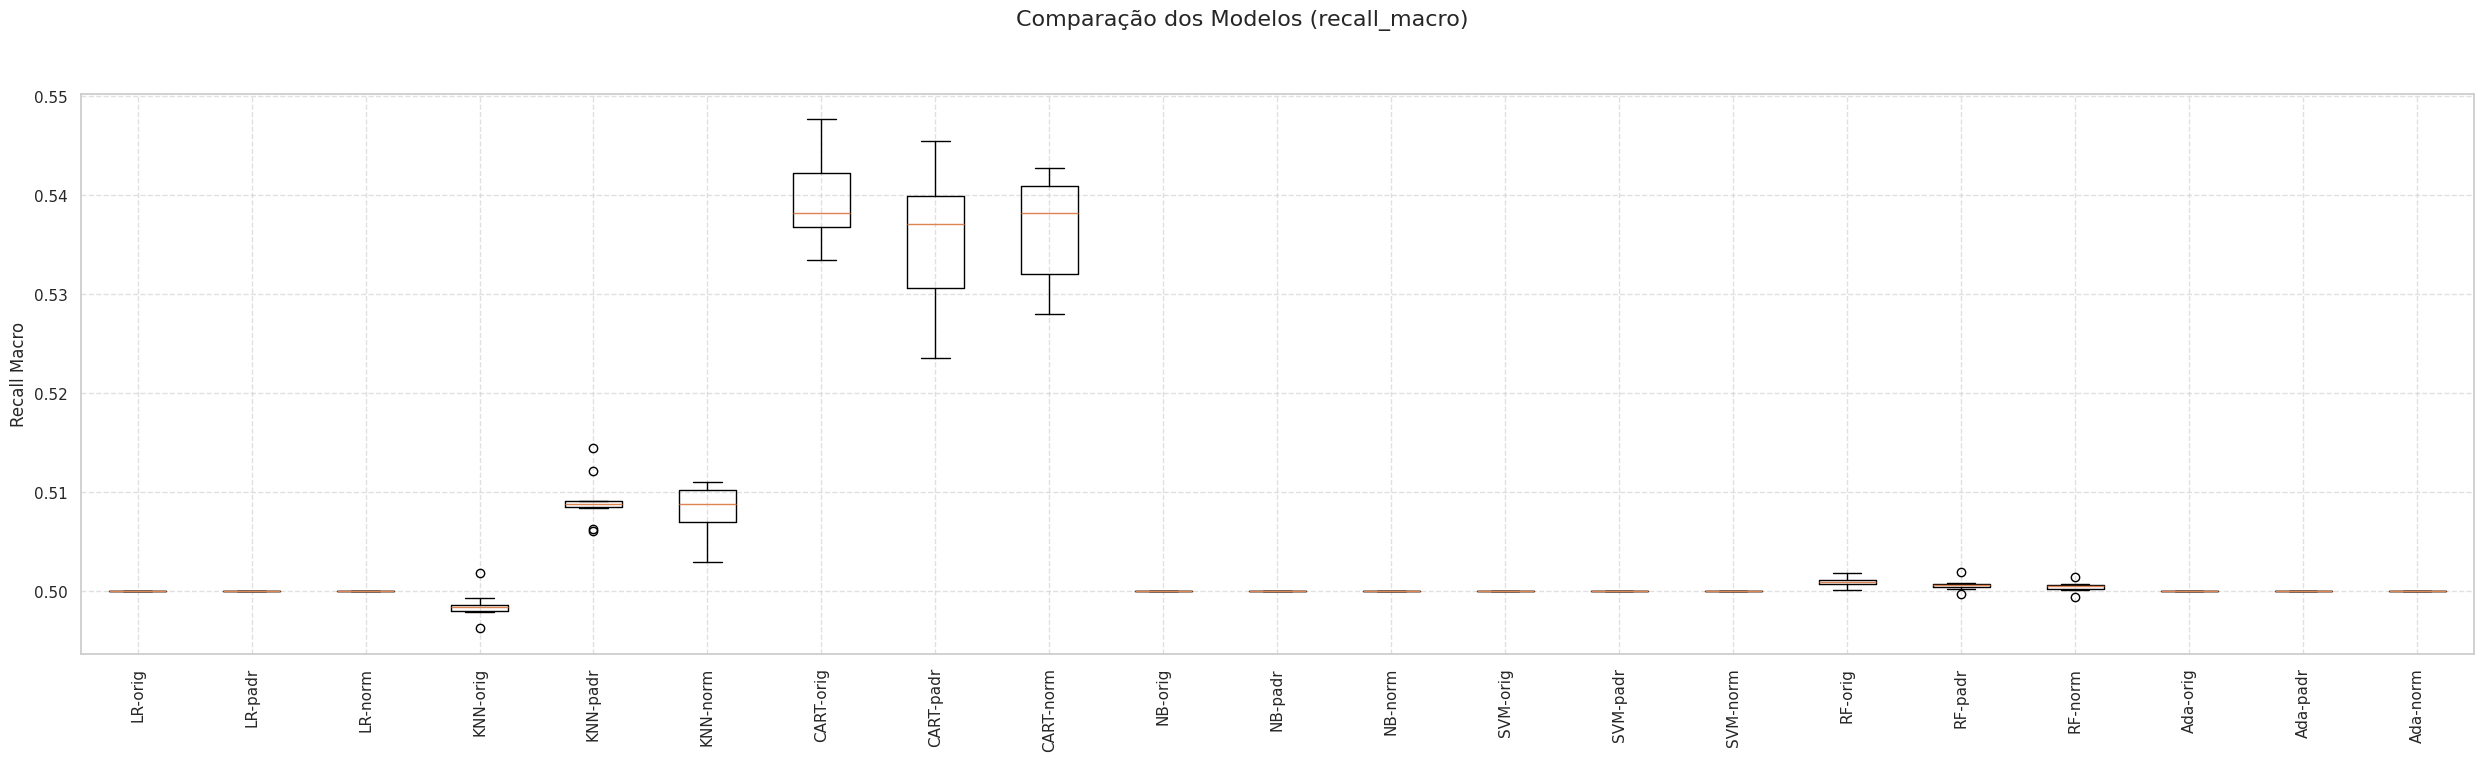

#Análise com rede neural

Para comparar os modelos vou treinar também uma rede neural para entender se é possível melhorar os resultados. Para esse treinamento vou criar três tipos de treinamento. Um pequeno com dois layer, um médio com três e um grande com quatro layers. Todos eles possuem um gráfico de histórico e uma matriz de confusão. O gráfico de histórico tem o objetivo de identificar se posso ou não reduzir as "epochs". Como alguns treinamentos ocorrem em série em longos periodos pode ser que esteja um valor de "epochs" desnecessário. Quando a matriz, sera gerada mas não será registrada na caixa de texto que vou salvar os resultados parciais. Isso porque eu vou salvar os valores para otimizar o tamanho do notebook.

In [19]:
def treinar_e_avaliar_rede_neural_peq(X_train, y_train, X_test, y_test, optimizer='adam', loss='binary_crossentropy', epochs=40, batch_size=32):

    input_dim = X_train.shape[1]
    modelo = keras.Sequential([
        layers.Dense(units=8, activation='relu', input_shape=(input_dim,)),
        layers.Dense(units=1, activation='sigmoid')
    ])

    print("\nResumo do Modelo:")
    modelo.summary()

    #Compilação do Modelo

    print(f"\nCompilando o modelo com optimizer='{optimizer}' and loss='{loss}'...")
    modelo.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    #Treinamento do Modelo

    print(f"\nIniciando o treinamento por {epochs} épocas com batch_size={batch_size}...")
    history = modelo.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    #Avaliação e Métricas

    print("\n--- Resultados da Avaliação no Conjunto de Teste ---")
    loss_teste, accuracy_teste = modelo.evaluate(X_test, y_test, verbose=0)
    print(f"Acurácia no conjunto de teste: {accuracy_teste:.4f}")


    y_pred_probs = modelo.predict(X_test)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    f1 = f1_score(y_test, y_pred_classes)
    print(f"F1-Score no conjunto de teste: {f1:.4f}")

    print("\nRelatório de Classificação Detalhado:")
    print(classification_report(y_test, y_pred_classes))

    #Plot do Histórico

    print("\nGerando gráfico do histórico de treinamento...")
    pd.DataFrame(history.history).plot(figsize=(10, 6), title="Histórico de Treinamento (Loss e Acurácia)")
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.xlabel("Épocas")
    plt.ylabel("Valor")
    plt.show()

    conf_matrix = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm')
    plt.title('Matriz de Confusão')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()

    print("\n--- Processo Finalizado ---")


    return modelo, history

def treinar_e_avaliar_rede_neural_med(X_train, y_train, X_test, y_test, optimizer='adam', loss='binary_crossentropy', epochs=40, batch_size=32):

    input_dim = X_train.shape[1]
    modelo = keras.Sequential([
        layers.Dense(units=16, activation='relu', input_shape=(input_dim,)),
        layers.Dense(units=8, activation='relu'),
        layers.Dense(units=1, activation='sigmoid')
    ])

    print("\nResumo do Modelo:")
    modelo.summary()

    #Compilação do Modelo

    print(f"\nCompilando o modelo com optimizer='{optimizer}' and loss='{loss}'...")
    modelo.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    #Treinamento do Modelo

    print(f"\nIniciando o treinamento por {epochs} épocas com batch_size={batch_size}...")
    history = modelo.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    #Avaliação e Métricas

    print("\n--- Resultados da Avaliação no Conjunto de Teste ---")
    loss_teste, accuracy_teste = modelo.evaluate(X_test, y_test, verbose=0)
    print(f"Acurácia no conjunto de teste: {accuracy_teste:.4f}")


    y_pred_probs = modelo.predict(X_test)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    f1 = f1_score(y_test, y_pred_classes)
    print(f"F1-Score no conjunto de teste: {f1:.4f}")

    print("\nRelatório de Classificação Detalhado:")
    print(classification_report(y_test, y_pred_classes))

    #Plot do Histórico

    print("\nGerando gráfico do histórico de treinamento...")
    pd.DataFrame(history.history).plot(figsize=(10, 6), title="Histórico de Treinamento (Loss e Acurácia)")
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.xlabel("Épocas")
    plt.ylabel("Valor")
    plt.show()

    conf_matrix = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm')
    plt.title('Matriz de Confusão')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()

    print("\n--- Processo Finalizado ---")


    return modelo, history


def treinar_e_avaliar_rede_neural_gra(X_train, y_train, X_test, y_test, optimizer='adam', loss='binary_crossentropy', epochs=40, batch_size=32):

    input_dim = X_train.shape[1]
    modelo = keras.Sequential([
        layers.Dense(units=32, activation='relu', input_shape=(input_dim,)),
        layers.Dense(units=16, activation='relu'),
        layers.Dense(units=8, activation='relu'),
        layers.Dense(units=1, activation='sigmoid')
    ])

    print("\nResumo do Modelo:")
    modelo.summary()

    #Compilação do Modelo

    print(f"\nCompilando o modelo com optimizer='{optimizer}' and loss='{loss}'...")
    modelo.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    #Treinamento do Modelo

    print(f"\nIniciando o treinamento por {epochs} épocas com batch_size={batch_size}...")
    history = modelo.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    #Avaliação e Métricas

    print("\n--- Resultados da Avaliação no Conjunto de Teste ---")
    loss_teste, accuracy_teste = modelo.evaluate(X_test, y_test, verbose=0)
    print(f"Acurácia no conjunto de teste: {accuracy_teste:.4f}")


    y_pred_probs = modelo.predict(X_test)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    f1 = f1_score(y_test, y_pred_classes)
    print(f"F1-Score no conjunto de teste: {f1:.4f}")

    print("\nRelatório de Classificação Detalhado:")
    print(classification_report(y_test, y_pred_classes))

    #Plot do Histórico

    print("\nGerando gráfico do histórico de treinamento...")
    pd.DataFrame(history.history).plot(figsize=(10, 6), title="Histórico de Treinamento (Loss e Acurácia)")
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.xlabel("Épocas")
    plt.ylabel("Valor")
    plt.show()


    conf_matrix = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm')
    plt.title('Matriz de Confusão')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()

    print("\n--- Processo Finalizado ---")


    return modelo, history





Resumo do Modelo:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 50 épocas com batch_size=32...
Epoch 1/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8305 - loss: 0.4382 - val_accuracy: 0.8475 - val_loss: 0.3931
Epoch 2/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8489 - loss: 0.3910 - val_accuracy: 0.8475 - val_loss: 0.3894
Epoch 3/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8481 - loss: 0.3893 - val_accuracy: 0.8475 - val_loss: 0.3876
Epoch 4/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8479 - loss: 0.3884 - val_accuracy: 0.8475 - val_loss: 0.3874
Epoch 5/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8491 - loss: 0.3860 - val_accuracy: 0.8475 - val_loss: 0.3876
Epoch 6/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8470 - loss: 0.3882 - val_accuracy: 0.8475 - val_loss: 0.3865
Epoch 7/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8466 - loss: 0.3

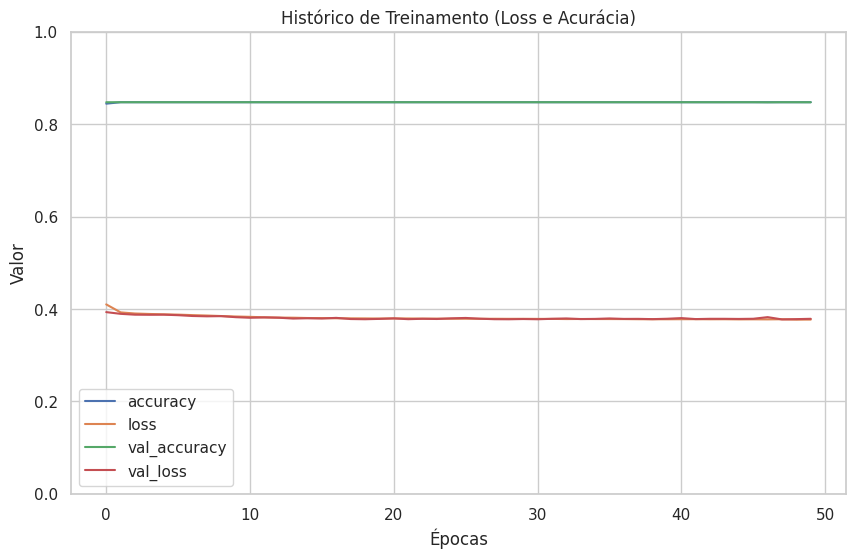

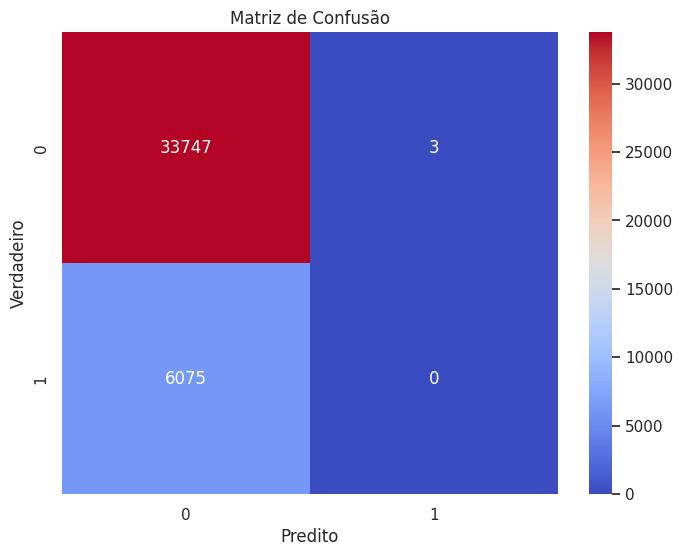


--- Processo Finalizado ---


In [ ]:
#Bloqueado por demorar demais
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# modelo_treinado_gra, historico_gra = treinar_e_avaliar_rede_neural_gra(
#     X_train=X_train_scaled,
#     y_train=y_train,
#     X_test=X_test_scaled,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )



#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0000


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |


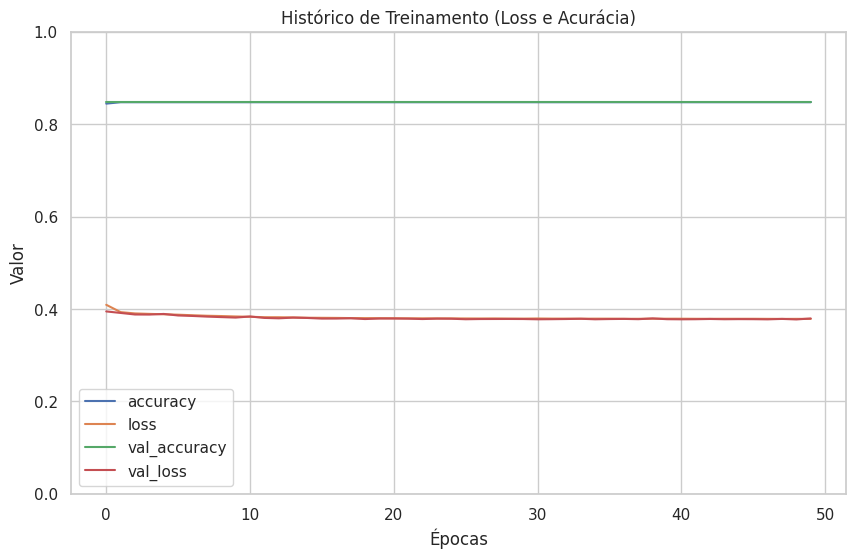

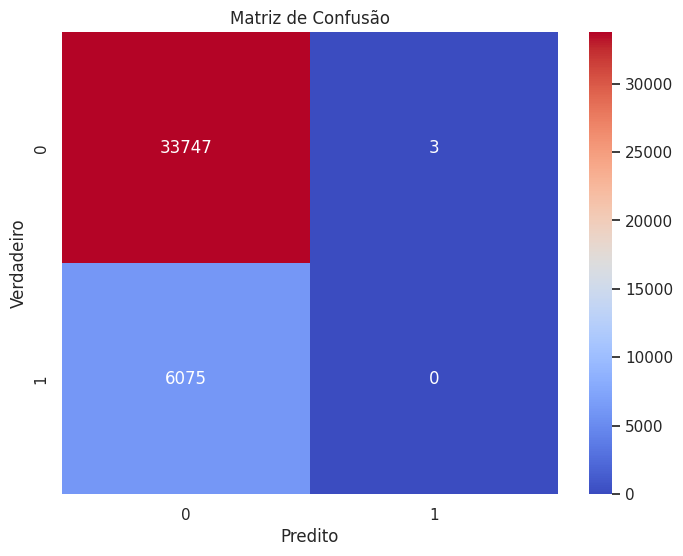



Resumo do Modelo:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 50 épocas com batch_size=32...
Epoch 1/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8381 - loss: 0.4487 - val_accuracy: 0.8475 - val_loss: 0.3994
Epoch 2/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8459 - loss: 0.3997 - val_accuracy: 0.8475 - val_loss: 0.3919
Epoch 3/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8479 - loss: 0.3916 - val_accuracy: 0.8475 - val_loss: 0.3886
Epoch 4/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8480 - loss: 0.3886 - val_accuracy: 0.8475 - val_loss: 0.3879
Epoch 5/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8480 - loss: 0.3885 - val_accuracy: 0.8475 - val_loss: 0.3877
Epoch 6/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8476 - loss: 0.3873 - val_accuracy: 0.8475 - val_loss: 0.3863
Epoch 7/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8475 - loss: 0.3

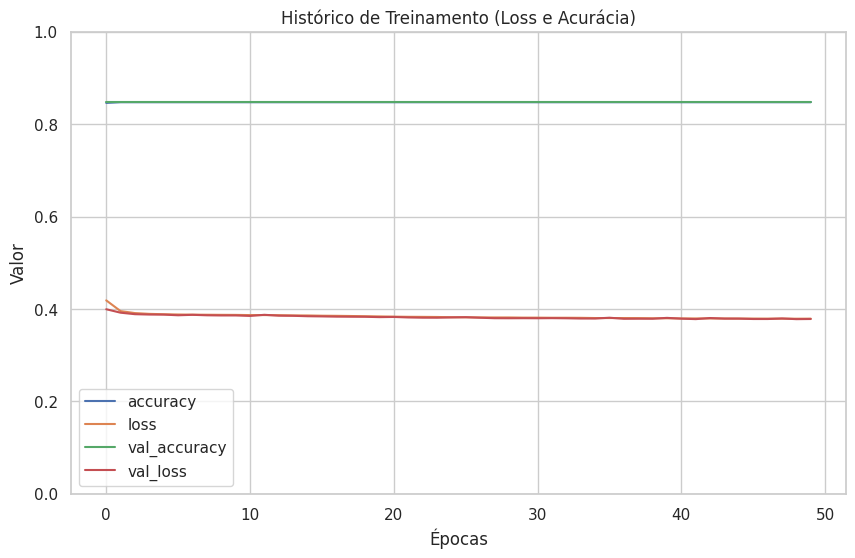

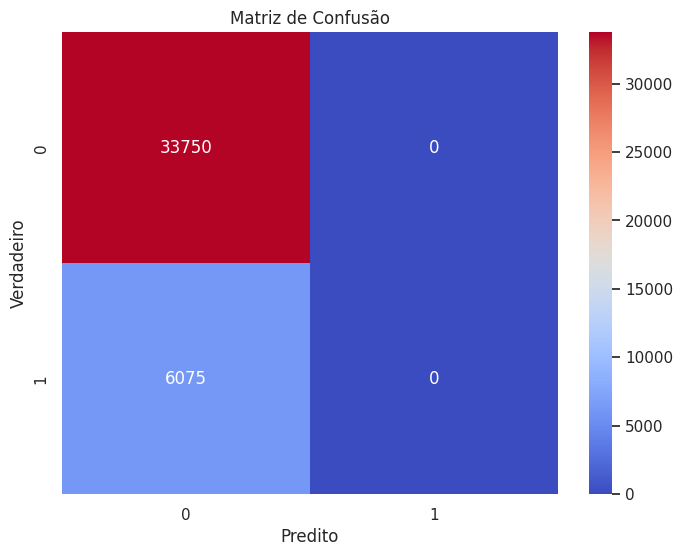


--- Processo Finalizado ---


In [ ]:
#Bloqueado por demorar demais
# modelo_treinado_med, historico_med = treinar_e_avaliar_rede_neural_med(
#     X_train=X_train_scaled,
#     y_train=y_train,
#     X_test=X_test_scaled,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0000


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |

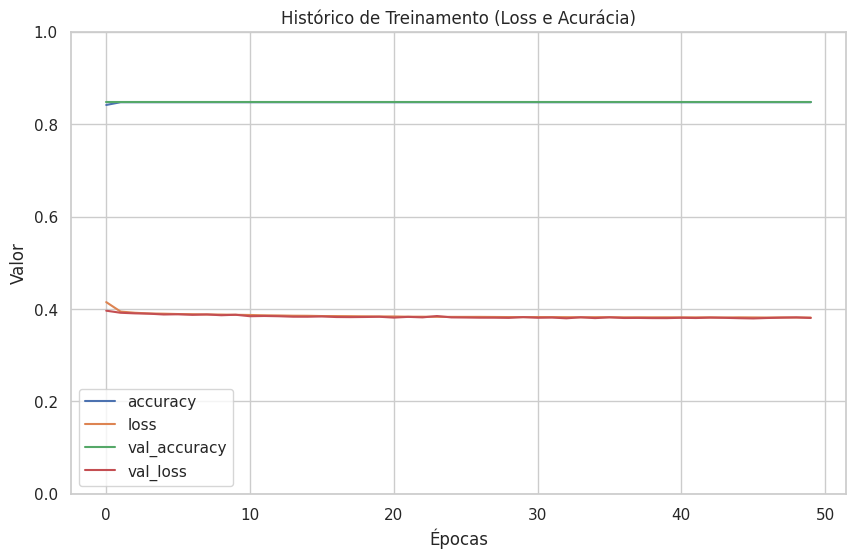

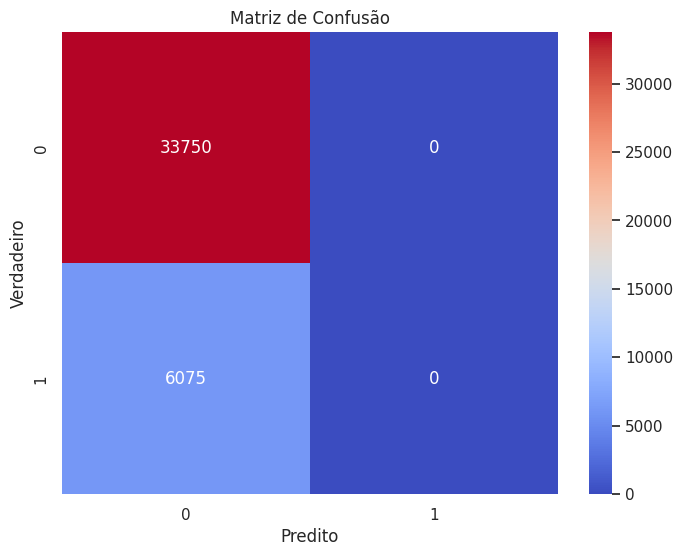


Resumo do Modelo:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 50 épocas com batch_size=32...
Epoch 1/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8028 - loss: 0.4727 - val_accuracy: 0.8475 - val_loss: 0.4084
Epoch 2/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8470 - loss: 0.4058 - val_accuracy: 0.8475 - val_loss: 0.3998
Epoch 3/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8469 - loss: 0.4006 - val_accuracy: 0.8475 - val_loss: 0.3984
Epoch 4/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8505 - loss: 0.3938 - val_accuracy: 0.8475 - val_loss: 0.3973
Epoch 5/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8462 - loss: 0.3996 - val_accuracy: 0.8475 - val_loss: 0.3967
Epoch 6/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8477 - loss: 0.3967 - val_accuracy: 0.8475 - val_loss: 0.3960
Epoch 7/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8468 - loss: 0.3

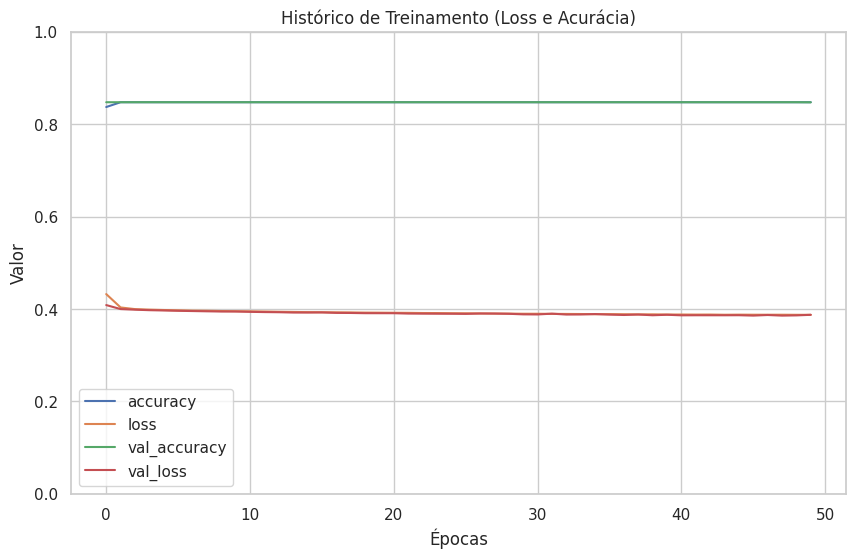

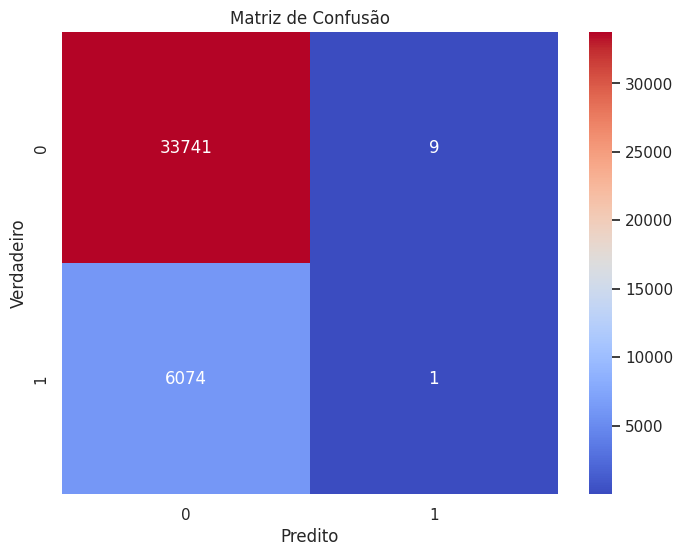


--- Processo Finalizado ---


In [ ]:
#Bloqueado por demorar demais
# modelo_treinado_peq, historico_peq = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled,
#     y_train=y_train,
#     X_test=X_test_scaled,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )


#Resultados parciais

Acurácia no conjunto de teste: 0.8473

F1-Score no conjunto de teste: 0.0003

### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.10 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.47 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.73 | 0.85 | 0.78 | 39825 |

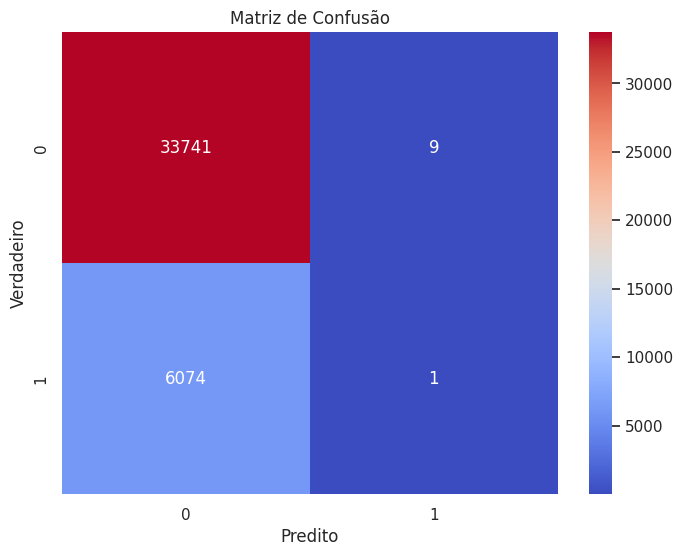


Resumo do Modelo:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 50 épocas com batch_size=32...
Epoch 1/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8470 - loss: 0.4317 - val_accuracy: 0.8475 - val_loss: 0.4051
Epoch 2/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8477 - loss: 0.4022 - val_accuracy: 0.8475 - val_loss: 0.3933
Epoch 3/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8493 - loss: 0.3914 - val_accuracy: 0.8475 - val_loss: 0.3891
Epoch 4/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8472 - loss: 0.3919 - val_accuracy: 0.8475 - val_loss: 0.3883
Epoch 5/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8471 - loss: 0.3909 - val_accuracy: 0.8475 - val_loss: 0.3881
Epoch 6/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8472 - loss: 0.3903 - val_accuracy: 0.8475 - val_loss: 0.3877
Epoch 7/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8481 - loss: 0.3

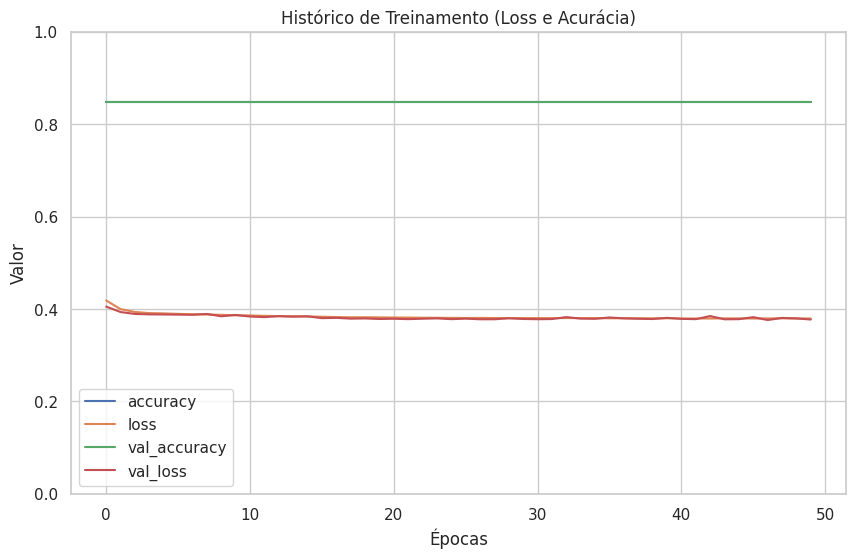

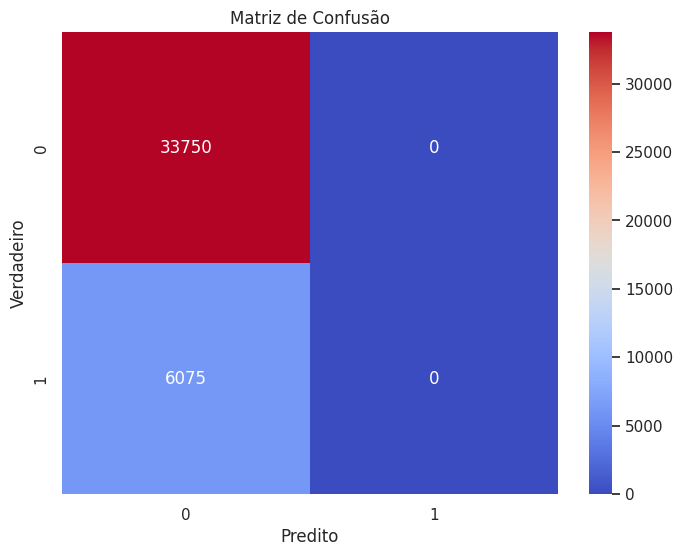


--- Processo Finalizado ---


In [ ]:
#Bloqueado por demorar demais
# scaler2 = MinMaxScaler()
# X_train_scaled2 = scaler2.fit_transform(X_train)
# X_test_scaled2 = scaler2.transform(X_test)

# modelo_treinado_gra_min, historico_gra_min = treinar_e_avaliar_rede_neural_gra(
#     X_train=X_train_scaled2,
#     y_train=y_train,
#     X_test=X_test_scaled2,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )


#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0000

### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |

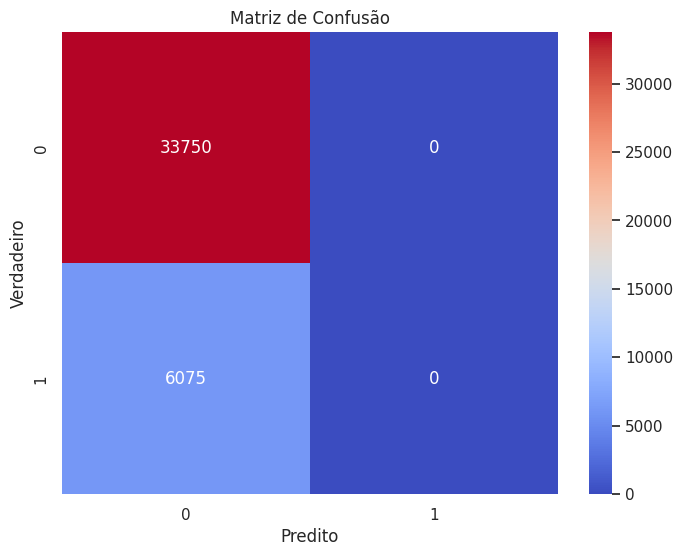


Resumo do Modelo:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 50 épocas com batch_size=32...
Epoch 1/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8035 - loss: 0.4649 - val_accuracy: 0.8475 - val_loss: 0.4167
Epoch 2/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8469 - loss: 0.4158 - val_accuracy: 0.8475 - val_loss: 0.4076
Epoch 3/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8480 - loss: 0.4052 - val_accuracy: 0.8475 - val_loss: 0.3997
Epoch 4/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8482 - loss: 0.3975 - val_accuracy: 0.8475 - val_loss: 0.3929
Epoch 5/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8471 - loss: 0.3942 - val_accuracy: 0.8475 - val_loss: 0.3908
Epoch 6/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8483 - loss: 0.3900 - val_accuracy: 0.8475 - val_loss: 0.3893
Epoch 7/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8478 - loss: 0.3

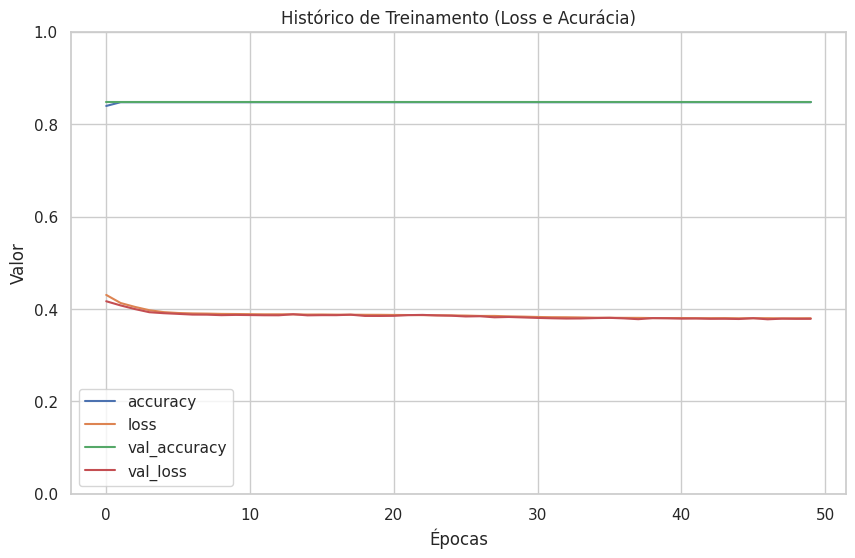

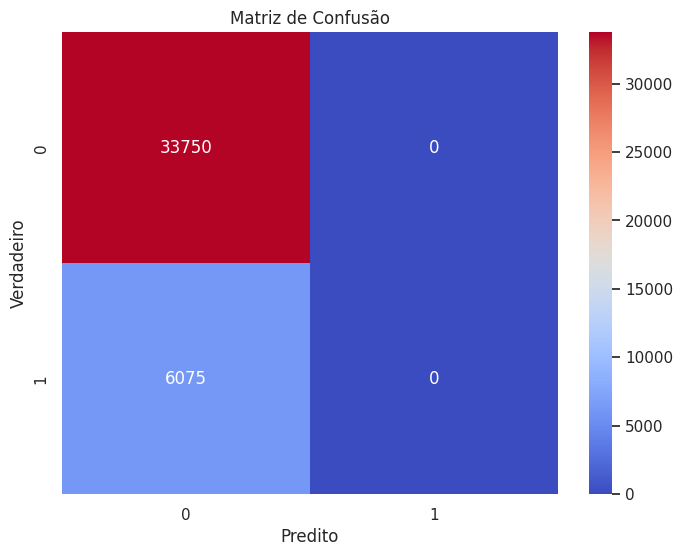


--- Processo Finalizado ---


In [ ]:
#Bloqueado por demorar demais
# modelo_treinado_med_min, historico_med_min = treinar_e_avaliar_rede_neural_med(
#     X_train=X_train_scaled2,
#     y_train=y_train,
#     X_test=X_test_scaled2,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0003


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |

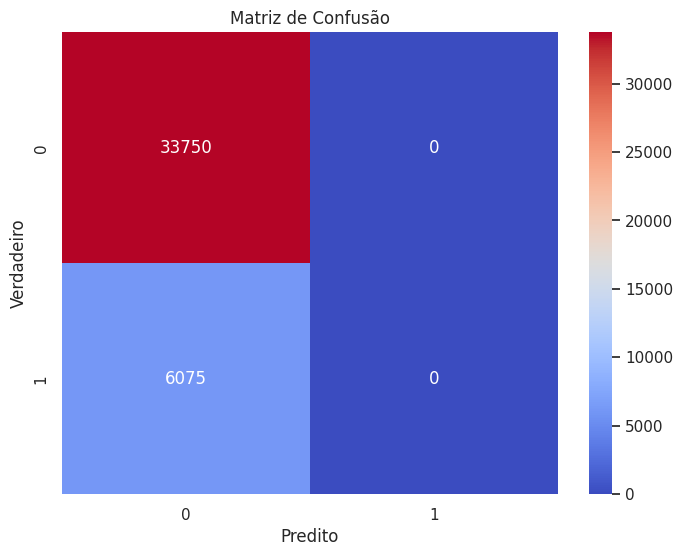


Resumo do Modelo:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 50 épocas com batch_size=32...
Epoch 1/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8316 - loss: 0.4565 - val_accuracy: 0.8475 - val_loss: 0.4207
Epoch 2/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8461 - loss: 0.4218 - val_accuracy: 0.8475 - val_loss: 0.4174
Epoch 3/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8455 - loss: 0.4202 - val_accuracy: 0.8475 - val_loss: 0.4128
Epoch 4/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8495 - loss: 0.4089 - val_accuracy: 0.8475 - val_loss: 0.4089
Epoch 5/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8466 - loss: 0.4106 - val_accuracy: 0.8475 - val_loss: 0.4053
Epoch 6/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8467 - loss: 0.4070 - val_accuracy: 0.8475 - val_loss: 0.4023
Epoch 7/50
2904/2904 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8464 - loss: 0.4

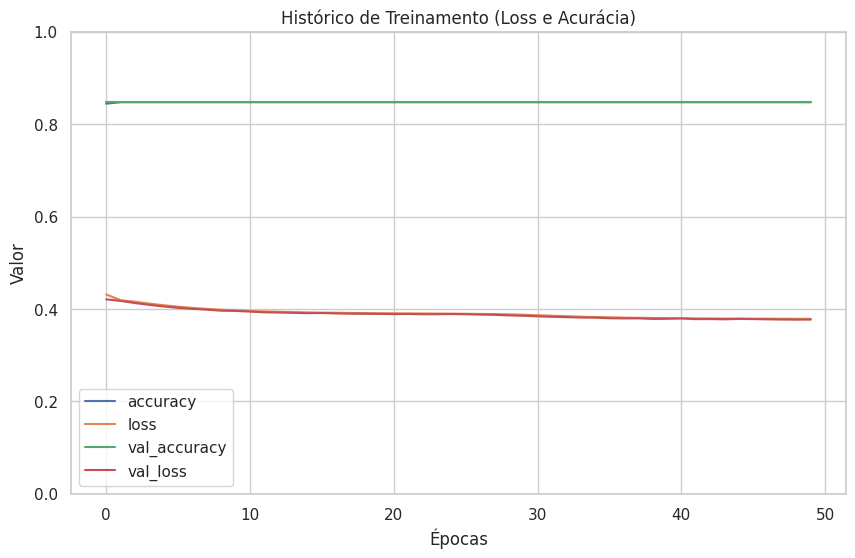

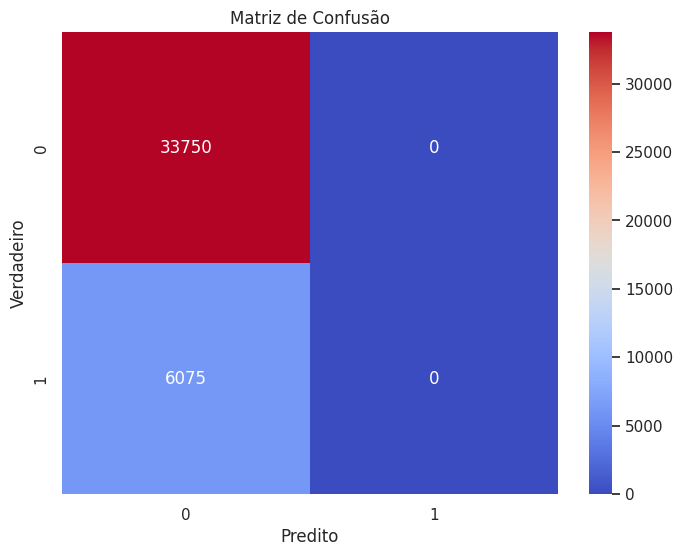


--- Processo Finalizado ---


In [ ]:
#Bloqueado por demorar demais
# modelo_treinado_peq_min, historico_peq_min = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled2,
#     y_train=y_train,
#     X_test=X_test_scaled2,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0000


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |

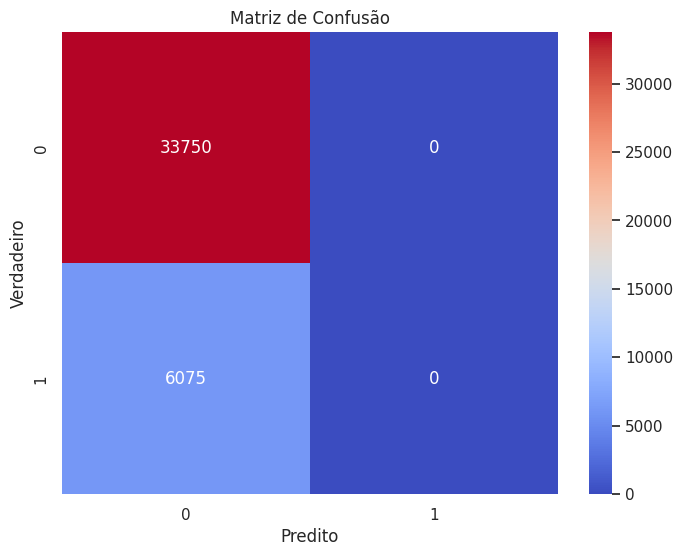

#Análise dos resultados

Na análise inicial dos modelos, os valores de precisão, f1 e recall ficaram bem baixos ~0,5. O melhor resultado foi obtido com árvore de classificação e regressão(CART) e original mas entende-se que é necessário explorar mais alternativas para identificar oportunidades de melhoria.

Os resultados das redes neurais são positivos para detectar o 0 mas conforme as matrizes de confusão demonstra, provavelmente o modelo está ignorando os casos com atrasos por conta do baixo número de cancelamentos. Apenas alguns modelos não zeraram a previsão de atraso mas com resultados ainda muito ruins. Para tentar melhorar a qualidade do modelo, a quantidade de dados sem cancelamentos será reduzida aleatóriamente e os processos da última análise serão repetidos para identificar o efeito do balanceamento.

In [20]:
#Preparo dos dados
df_maioria = df_model_clean2[df_model_clean2['Cancelled Rides by Driver'] == 0]
df_minoria = df_model_clean2[df_model_clean2['Cancelled Rides by Driver'] == 1]
df_maioria_reduzido = df_maioria.sample(n=47248, random_state=42) #Utilizei o valor de 20249 chamadas canceladas pelo motorista como referencia. A partir dela calculei uma relação de 70/30 para definir quantos dados de chamadas não canceladas deveriam sobrar.
df_balanceado = pd.concat([df_maioria_reduzido, df_minoria])
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_balanceado.head())
print(df_balanceado.info())

#Repetindo o processo

# Separar features (X) e target (y)
X2 = df_balanceado[['Date1', 'Time1', 'Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']]
y2 = df_balanceado['Cancelled Rides by Driver']
# Dividir os dados em conjuntos de treino e teste
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)
print(f"Dimensões de X_train2: {X_train2.shape}")
print(f"Dimensões de X_test2: {X_test2.shape}")
print(f"Dimensões de y_train2: {y_train2.shape}")
print(f"Dimensões de y_test2: {y_test2.shape}")




        Date1       Time1  Avg VTAT  Type_Bike  Type_Go Mini  Type_Go Sedan  \
0  1704672000 -2208919772       3.6          1             0              0   
1  1711929600 -2208958541       6.5          0             1              0   
2  1709337600 -2208911976       9.2          0             0              0   
3  1722124800 -2208966620      10.9          0             1              0   
4  1735171200 -2208937528       5.8          0             0              0   

   Type_Premier Sedan  Type_Uber XL  Type_eBike  Cancelled Rides by Driver  \
0                   0             0           0                          1   
1                   0             0           0                          1   
2                   1             0           0                          1   
3                   0             0           0                          0   
4                   0             0           0                          0   

   cancellation_rate_percent_drop  cancellation_rate_per

Iniciando comparação de modelos...
--- LR-orig ---
  f1_macro: 0.412 (0.000)
  precision_macro: 0.350 (0.000)
  recall_macro: 0.500 (0.000)
--- LR-padr ---
  f1_macro: 0.412 (0.000)
  precision_macro: 0.393 (0.079)
  recall_macro: 0.500 (0.000)
--- LR-norm ---
  f1_macro: 0.412 (0.000)
  precision_macro: 0.393 (0.079)
  recall_macro: 0.500 (0.000)
--- KNN-orig ---
  f1_macro: 0.484 (0.006)
  precision_macro: 0.497 (0.007)
  recall_macro: 0.498 (0.005)
--- KNN-padr ---
  f1_macro: 0.534 (0.005)
  precision_macro: 0.545 (0.006)
  recall_macro: 0.536 (0.004)
--- KNN-norm ---
  f1_macro: 0.532 (0.005)
  precision_macro: 0.543 (0.006)
  recall_macro: 0.534 (0.005)
--- CART-orig ---
  f1_macro: 0.559 (0.007)
  precision_macro: 0.559 (0.008)
  recall_macro: 0.560 (0.007)
--- CART-padr ---
  f1_macro: 0.560 (0.006)
  precision_macro: 0.559 (0.006)
  recall_macro: 0.560 (0.006)
--- CART-norm ---
  f1_macro: 0.561 (0.007)
  precision_macro: 0.560 (0.007)
  recall_macro: 0.561 (0.007)
--- NB-orig

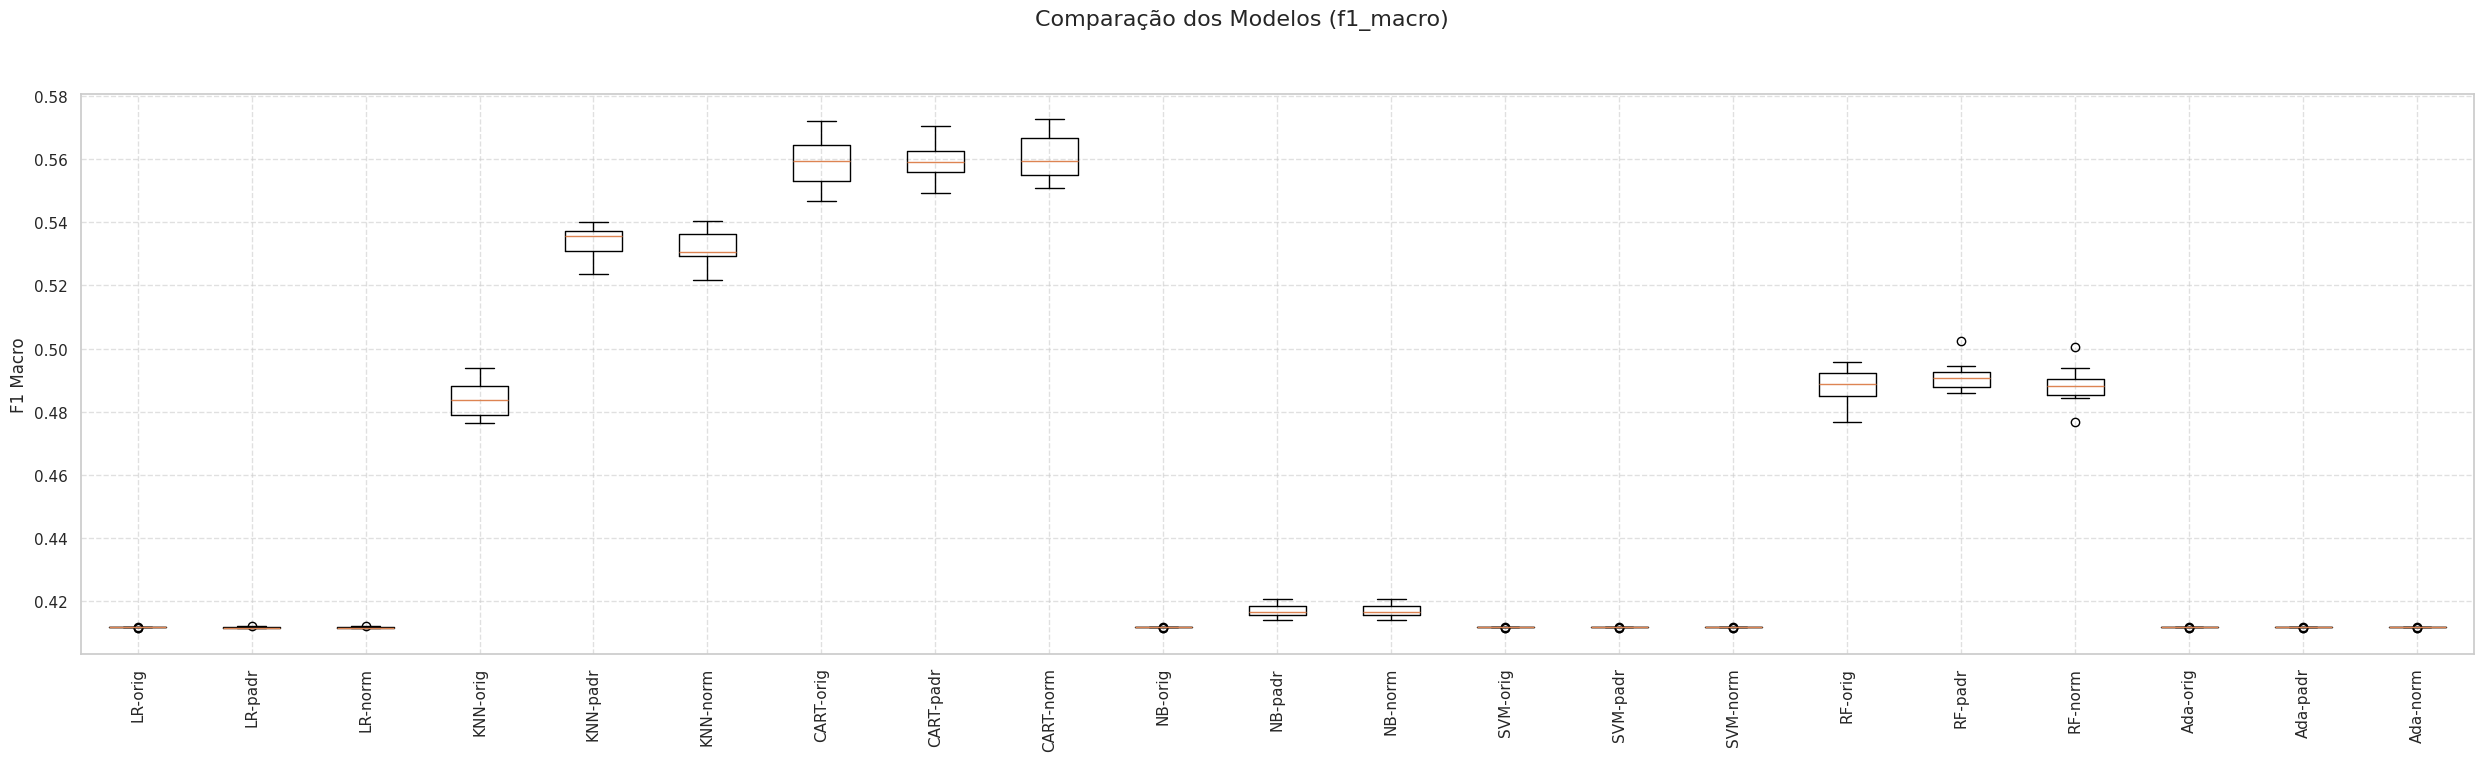

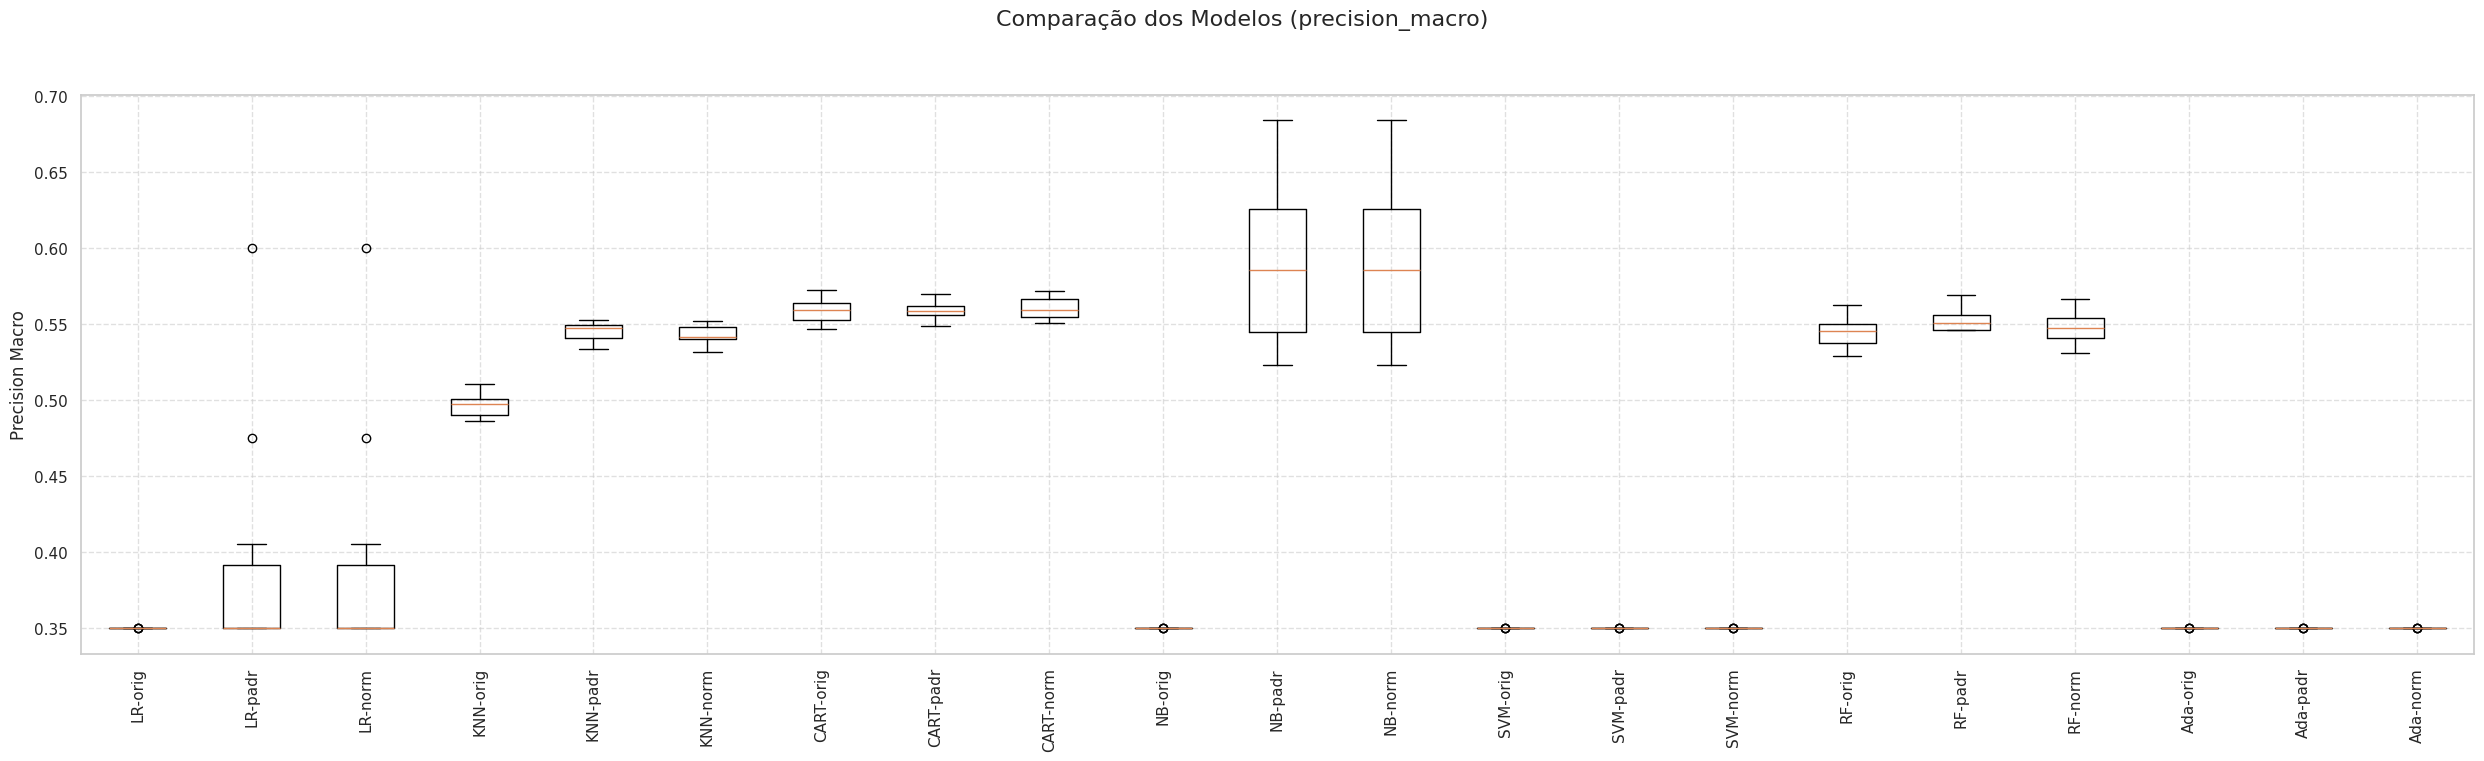

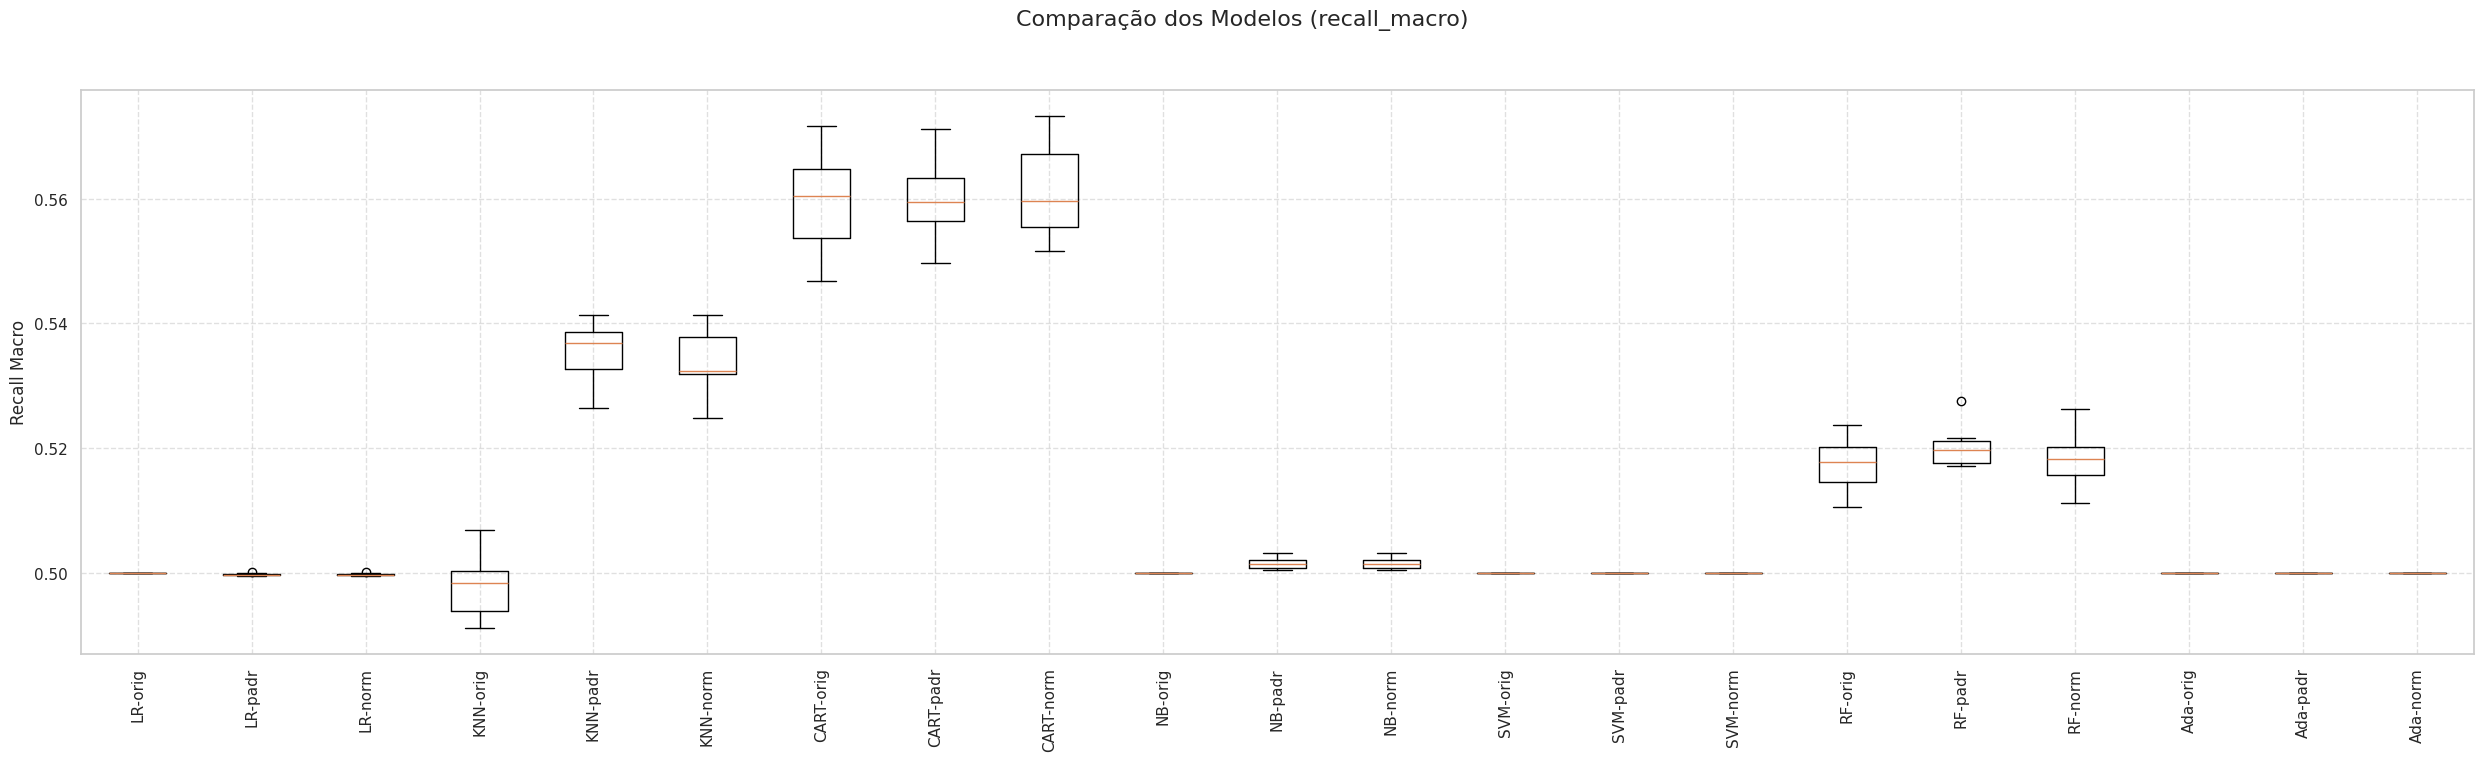

   pipeline_name  mean_f1_macro  mean_precision_macro  mean_recall_macro
0        LR-orig       0.411765              0.350001           0.500000
1        LR-padr       0.411739              0.392992           0.499693
2        LR-norm       0.411749              0.392996           0.499714
3       KNN-orig       0.483738              0.496567           0.497778
4       KNN-padr       0.533986              0.545252           0.535632
5       KNN-norm       0.531744              0.542796           0.533642
6      CART-orig       0.558967              0.558597           0.559531
7      CART-padr       0.559542              0.559096           0.560134
8      CART-norm       0.560730              0.560307           0.561281
9        NB-orig       0.411765              0.350001           0.500000
10       NB-padr       0.417231              0.592861           0.501464
11       NB-norm       0.417231              0.592861           0.501464
12      SVM-orig       0.411765              0.3500

In [ ]:
#Bloqueado por demorar demais

#Parte repetida pois não consegui rodar tudo no mesmo dia
# base_decision_tree = DecisionTreeClassifier()
# num_trees = 100
# models_to_compare = {
#     'LR': LogisticRegression(max_iter=200),
#     'KNN': KNeighborsClassifier(),
#     'CART': DecisionTreeClassifier(),
#     'NB': GaussianNB(),
#     'SVM': SVC(),
#     'RF': RandomForestClassifier(n_estimators=num_trees),
#     'Ada': AdaBoostClassifier(n_estimators=num_trees)
# }

# scalers_to_compare = {
#     'padr': StandardScaler(),
#     'norm': MinMaxScaler()
# }
# df_resultados2 = executar_comparacao_modelos(X2, y2, models=models_to_compare, scalers=scalers_to_compare)

# colunas_resumo2 = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados2[colunas_resumo2])

#Resultados parciais


| Modelo | Pré-processamento | F1 Macro | Precision Macro | Recall Macro |
| :--- | :--- | :--- | :--- | :--- |
| LR | orig | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| LR | padr | 0.412 (0.000) | 0.393 (0.079) | 0.500 (0.000) |
| LR | norm | 0.412 (0.000) | 0.393 (0.079) | 0.500 (0.000) |
| KNN | orig | 0.484 (0.006) | 0.497 (0.007) | 0.498 (0.005) |
| KNN | padr | 0.534 (0.005) | 0.545 (0.006) | 0.536 (0.004) |
| KNN | norm | 0.532 (0.005) | 0.543 (0.006) | 0.534 (0.005) |
| CART | orig | 0.559 (0.007) | 0.559 (0.008) | 0.560 (0.007) |
| CART | padr | 0.560 (0.006) | 0.559 (0.006) | 0.560 (0.006) |
| CART | norm | 0.561 (0.007) | 0.560 (0.007) | 0.561 (0.007) |
| NB | orig | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| NB | padr | 0.417 (0.002) | 0.593 (0.053) | 0.501 (0.001) |
| NB | norm | 0.417 (0.002) | 0.593 (0.053) | 0.501 (0.001) |
| SVM | orig | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| SVM | padr | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| SVM | norm | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| RF | orig | 0.488 (0.006) | 0.545 (0.009) | 0.517 (0.004) |
| RF | padr | 0.491 (0.005) | 0.552 (0.007) | 0.520 (0.003) |
| RF | norm | 0.488 (0.006) | 0.548 (0.010) | 0.518 (0.004) |
| Ada | orig | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| Ada | padr | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| Ada | norm | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |



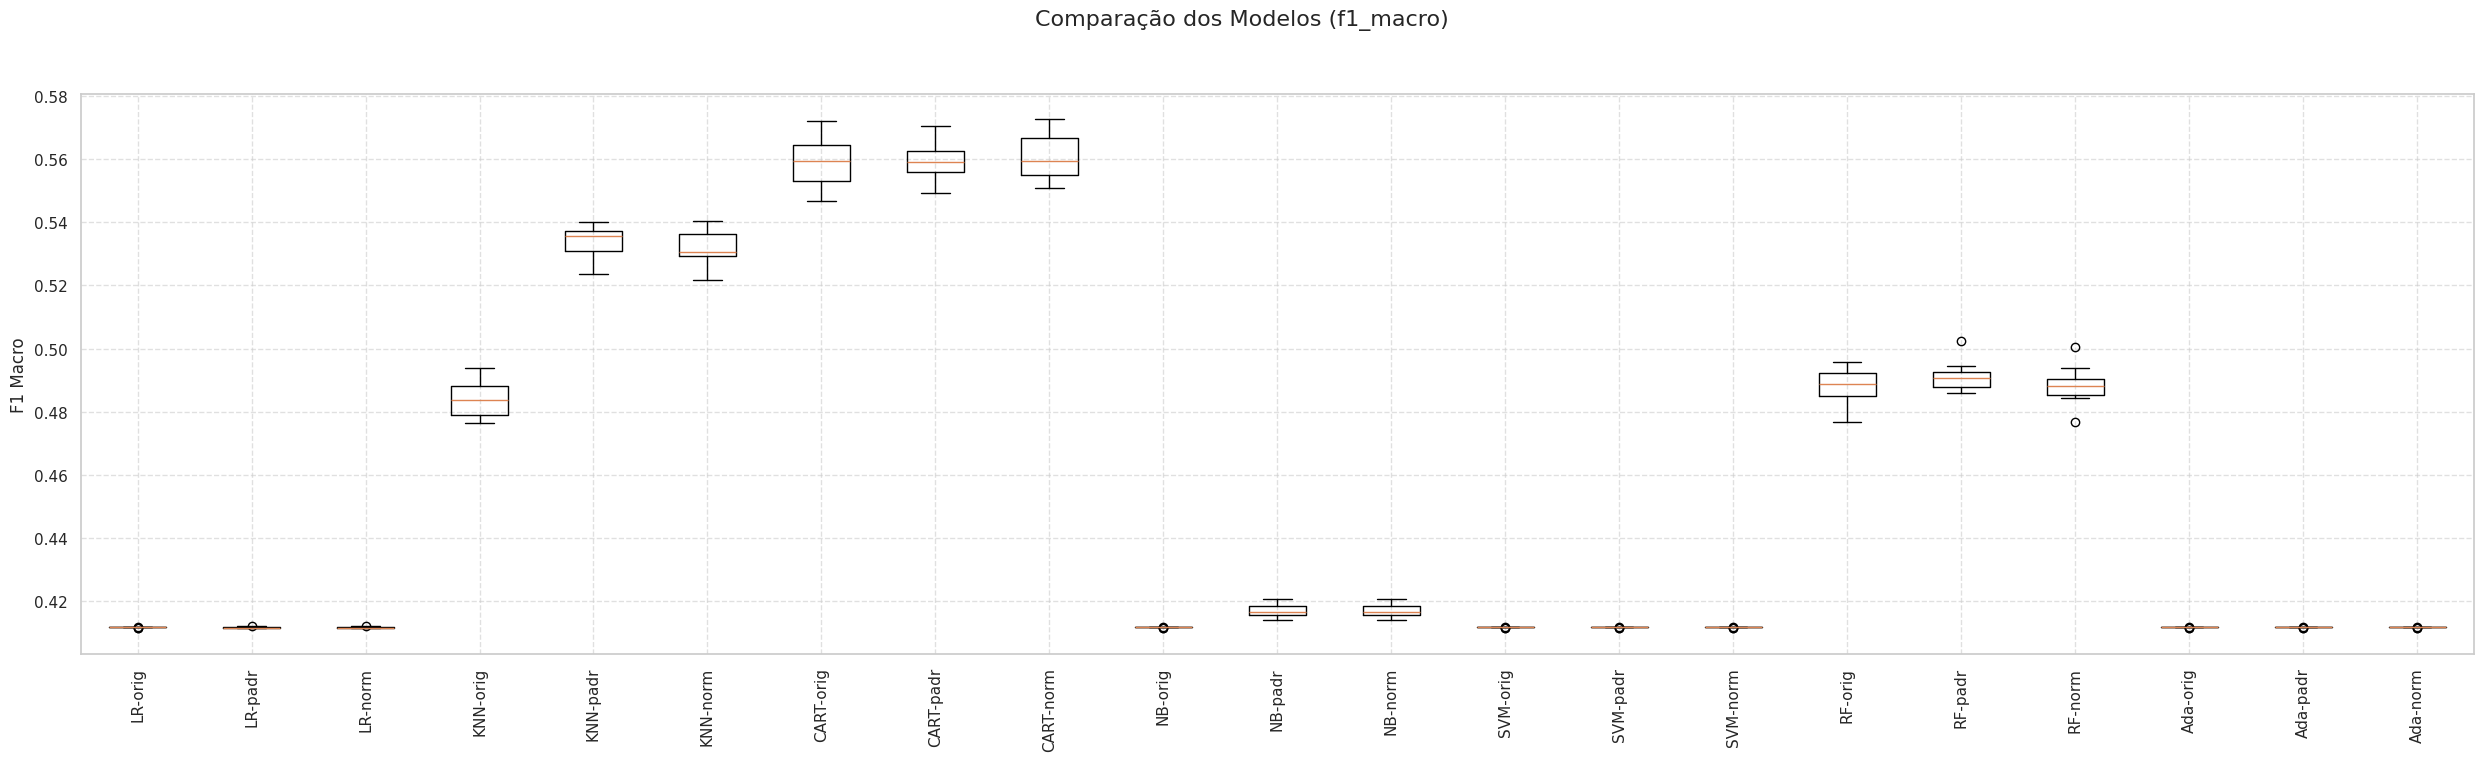


In [21]:
#Bloqueado por demorar demais
scaler3 = MinMaxScaler()
X_train_scaled3 = scaler3.fit_transform(X_train2)
X_test_scaled3 = scaler3.transform(X_test2)

#Do resultado obtido anteriormente, identificou-se que os resultados não mudaram por conta da quantidade e layers, então serão alteradas outras variáveis.
#Outra mudança foi a alteração da quantidade de epochs para 20 pois aparentemente a curva já fica estável com esse valor.
# modelo_treinado_peq2, historico_peq2 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled3,
#     y_train=y_train2,
#     X_test=X_test_scaled3,
#     y_test=y_test2,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6998

F1-Score no conjunto de teste: 0.0000



### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.70 | 1.00 | 0.82 | 14175 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.70** | **20250** |
| **macro avg** | 0.35 | 0.50 | 0.41 | 20250 |
| **weighted avg** | 0.49 | 0.70 | 0.58 | 20250 |

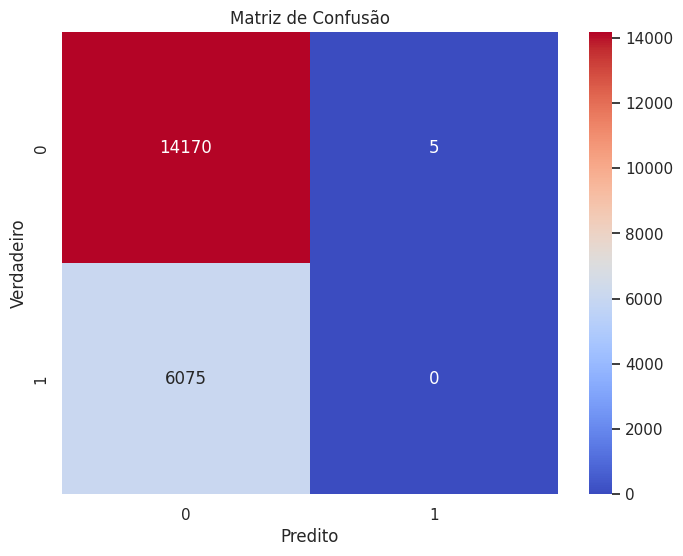


Resumo do Modelo:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='RMSprop' and loss='binary_crossentropy'...

Iniciando o treinamento por 20 épocas com batch_size=32...
Epoch 1/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6936 - loss: 0.6172 - val_accuracy: 0.7000 - val_loss: 0.6000
Epoch 2/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7004 - loss: 0.5978 - val_accuracy: 0.7000 - val_loss: 0.5945
Epoch 3/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7021 - loss: 0.5904 - val_accuracy: 0.7000 - val_loss: 0.5888
Epoch 4/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6983 - loss: 0.5887 - val_accuracy: 0.7000 - val_loss: 0.5839
Epoch 5/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7009 - loss: 0.5819 - val_accuracy: 0.7000 - val_loss: 0.5798
Epoch 6/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7012 - loss: 0.5770 - val_accuracy: 0.7000 - val_loss: 0.5772
Epoch 7/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6970 - loss: 

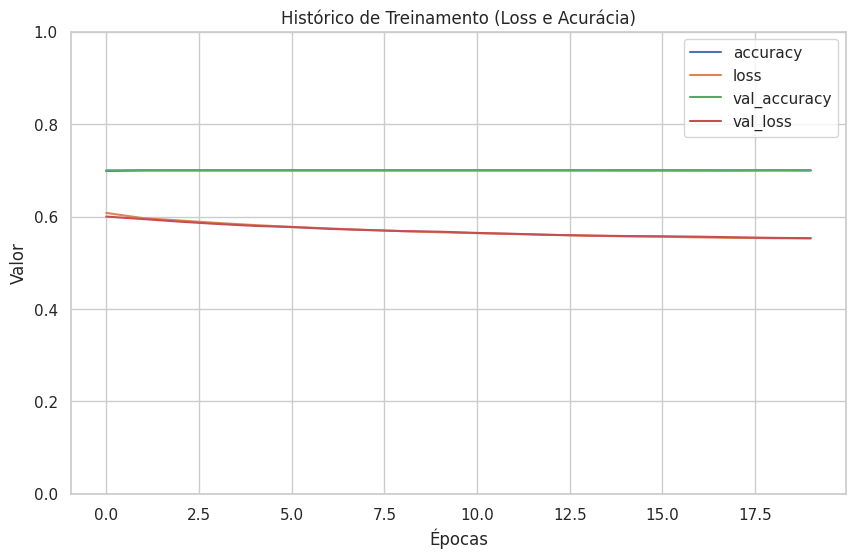

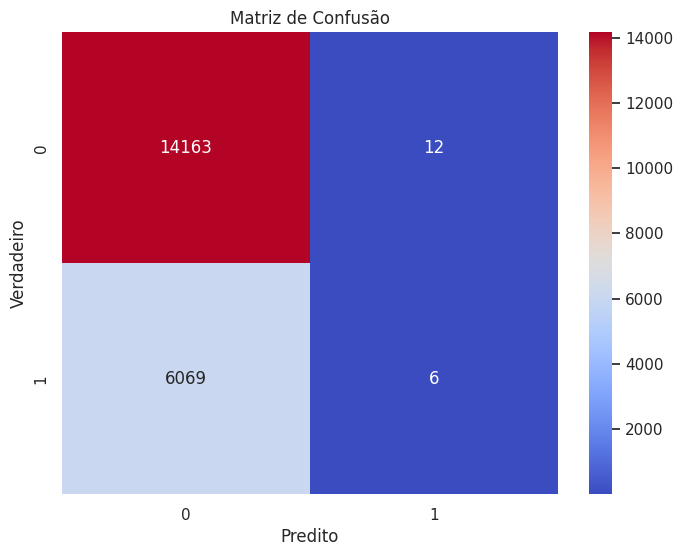


--- Processo Finalizado ---


In [ ]:
#Bloqueado por demorar demais
# modelo_treinado_peq3, historico_peq3 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled3,
#     y_train=y_train2,
#     X_test=X_test_scaled3,
#     y_test=y_test2,
#     optimizer='RMSprop',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6997

F1-Score no conjunto de teste: 0.0020



### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.70 | 1.00 | 0.82 | 14175 |
| 1 | 0.33 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.70** | **20250** |
| **macro avg** | 0.52 | 0.50 | 0.41 | 20250 |
| **weighted avg** | 0.59 | 0.70 | 0.58 | 20250 |

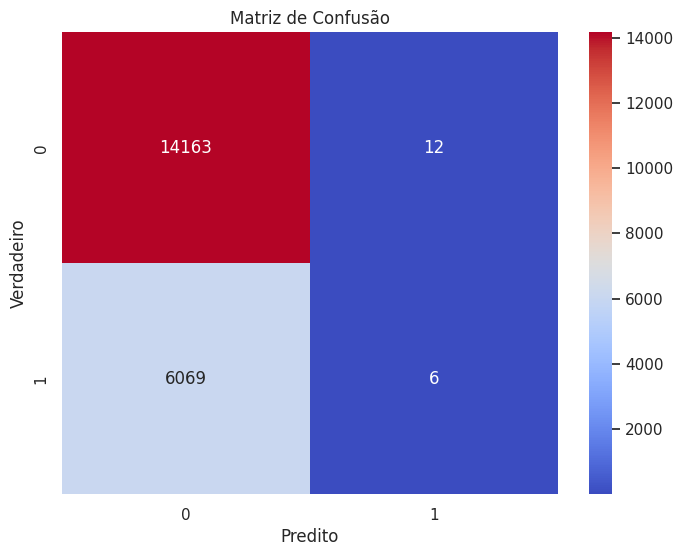


Resumo do Modelo:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 20 épocas com batch_size=64...
Epoch 1/20
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7015 - loss: 0.6151 - val_accuracy: 0.7000 - val_loss: 0.6020
Epoch 2/20
739/739 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6988 - loss: 0.6013 - val_accuracy: 0.7000 - val_loss: 0.5969
Epoch 3/20
739/739 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7012 - loss: 0.5945 - val_accuracy: 0.6999 - val_loss: 0.5941
Epoch 4/20
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6986 - loss: 0.5945 - val_accuracy: 0.7000 - val_loss: 0.5915
Epoch 5/20
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6985 - loss: 0.5912 - val_accuracy: 0.7000 - val_loss: 0.5878
Epoch 6/20
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6994 - loss: 0.5857 - val_accuracy: 0.7000 - val_loss: 0.5828
Epoch 7/20
739/739 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6999 - loss: 0.5805 - val_accu

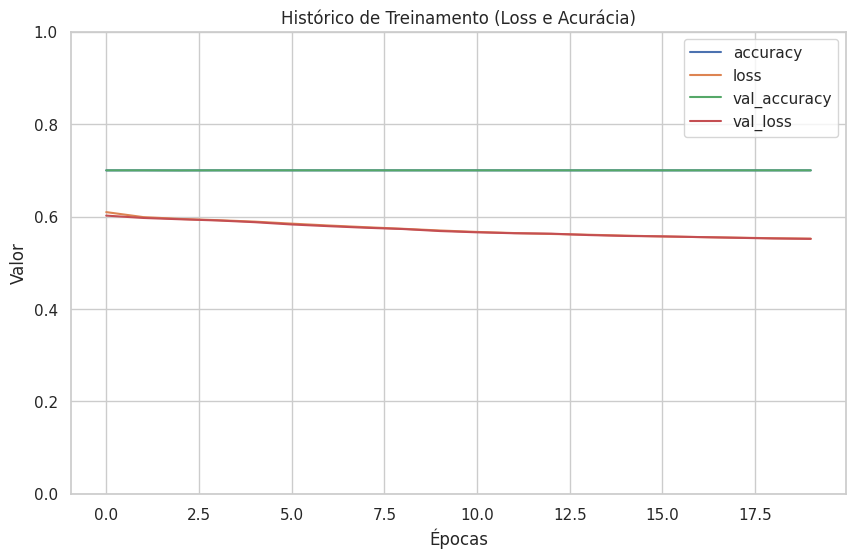

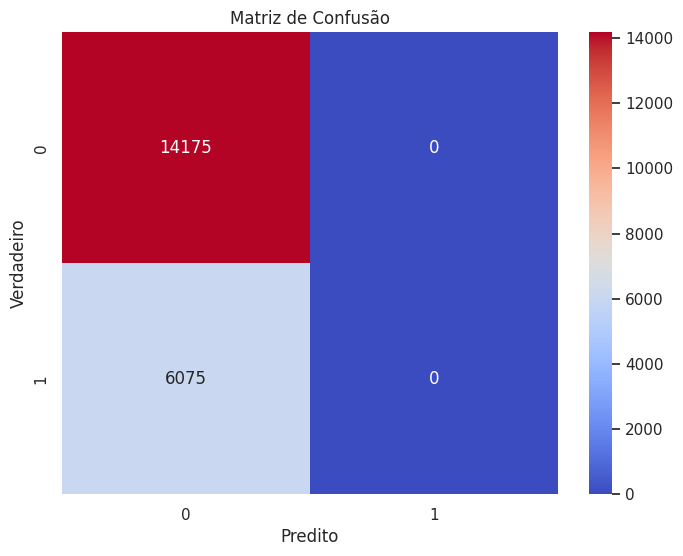


--- Processo Finalizado ---


In [ ]:
#Bloqueado por demorar demais
# modelo_treinado_peq4, historico_peq4 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled3,
#     y_train=y_train2,
#     X_test=X_test_scaled3,
#     y_test=y_test2,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=64
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.7000

F1-Score no conjunto de teste: 0.0000

### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.70 | 1.00 | 0.82 | 14175 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.70** | **20250** |
| **macro avg** | 0.35 | 0.50 | 0.41 | 20250 |
| **weighted avg** | 0.49 | 0.70 | 0.58 | 20250 |

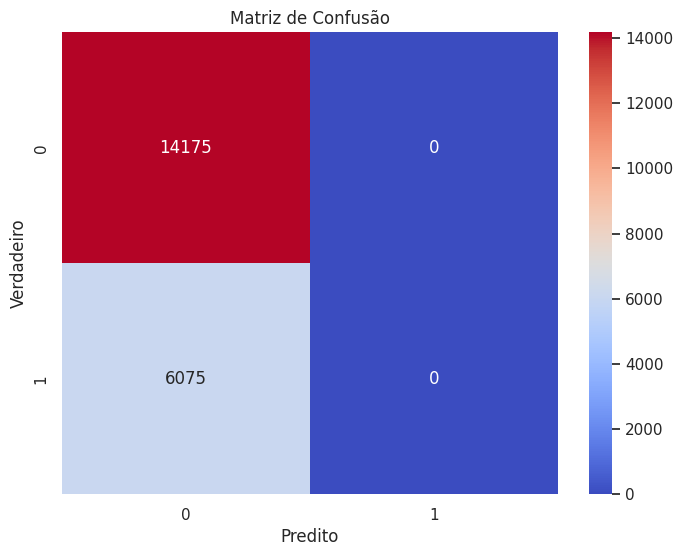

#Análise dos resultados
Na avaliação dos modelos, novamente o modelo CART se destacou mas com dados normalizados. Porém acredita-se na possibilidade de melhorar ainda mais os resultados.

Na avaliação da rede neural houve uma redução na acurácia sem melhorar os resultados na identificação de cancelamentos, mesmo alterando o número do *batch_size* ou o tipo do *optimizer*. Para tentar melhorar o resultado dividiu-se os dados em 50/50 com o objetivo de avaliar o impacto dos dados balanceados.

In [22]:
#Preparo dos dados
df_maioria2 = df_model_clean2[df_model_clean2['Cancelled Rides by Driver'] == 0]
df_minoria2 = df_model_clean2[df_model_clean2['Cancelled Rides by Driver'] == 1]
df_maioria_reduzido2 = df_maioria2.sample(n=20249, random_state=42) #Utilizei o valor de 20249 chamadas canceladas pelo motorista como referencia. A partir dela calculei uma relação de 70/30 para definir quantos dados de chamadas não canceladas deveriam sobrar.
df_balanceado2 = pd.concat([df_maioria_reduzido2, df_minoria2])
df_balanceado2 = df_balanceado2.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_balanceado2.head())
print(df_balanceado2.info())

#Repetindo o processo

# Separar features (X) e target (y)
X3 = df_balanceado2[['Date1', 'Time1', 'Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']]
y3 = df_balanceado2['Cancelled Rides by Driver']
# Dividir os dados em conjuntos de treino e teste
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.3, random_state=42, stratify=y3)
print(f"Dimensões de X_train2: {X_train3.shape}")
print(f"Dimensões de X_test2: {X_test3.shape}")
print(f"Dimensões de y_train2: {y_train3.shape}")
print(f"Dimensões de y_test2: {y_test3.shape}")

        Date1       Time1  Avg VTAT  Type_Bike  Type_Go Mini  Type_Go Sedan  \
0  1721260800 -2208962687      12.2          0             0              0   
1  1723766400 -2208909806      10.0          0             1              0   
2  1710806400 -2208916618       6.3          1             0              0   
3  1704326400 -2208981040       7.2          0             0              0   
4  1727913600 -2208929950       4.5          0             0              1   

   Type_Premier Sedan  Type_Uber XL  Type_eBike  Cancelled Rides by Driver  \
0                   1             0           0                          0   
1                   0             0           0                          1   
2                   0             0           0                          1   
3                   0             1           0                          1   
4                   0             0           0                          0   

   cancellation_rate_percent_drop  cancellation_rate_per

Iniciando comparação de modelos...
--- LR-orig ---
  f1_macro: 0.511 (0.023)
  precision_macro: 0.511 (0.023)
  recall_macro: 0.511 (0.023)
--- LR-padr ---
  f1_macro: 0.555 (0.008)
  precision_macro: 0.556 (0.008)
  recall_macro: 0.556 (0.008)
--- LR-norm ---
  f1_macro: 0.556 (0.008)
  precision_macro: 0.556 (0.008)
  recall_macro: 0.556 (0.008)
--- KNN-orig ---
  f1_macro: 0.498 (0.007)
  precision_macro: 0.498 (0.007)
  recall_macro: 0.498 (0.007)
--- KNN-padr ---
  f1_macro: 0.577 (0.004)
  precision_macro: 0.579 (0.004)
  recall_macro: 0.578 (0.004)
--- KNN-norm ---
  f1_macro: 0.573 (0.005)
  precision_macro: 0.576 (0.005)
  recall_macro: 0.575 (0.005)
--- CART-orig ---
  f1_macro: 0.590 (0.005)
  precision_macro: 0.590 (0.005)
  recall_macro: 0.590 (0.005)
--- CART-padr ---
  f1_macro: 0.593 (0.009)
  precision_macro: 0.593 (0.009)
  recall_macro: 0.593 (0.009)
--- CART-norm ---
  f1_macro: 0.594 (0.007)
  precision_macro: 0.594 (0.007)
  recall_macro: 0.594 (0.007)
--- NB-orig

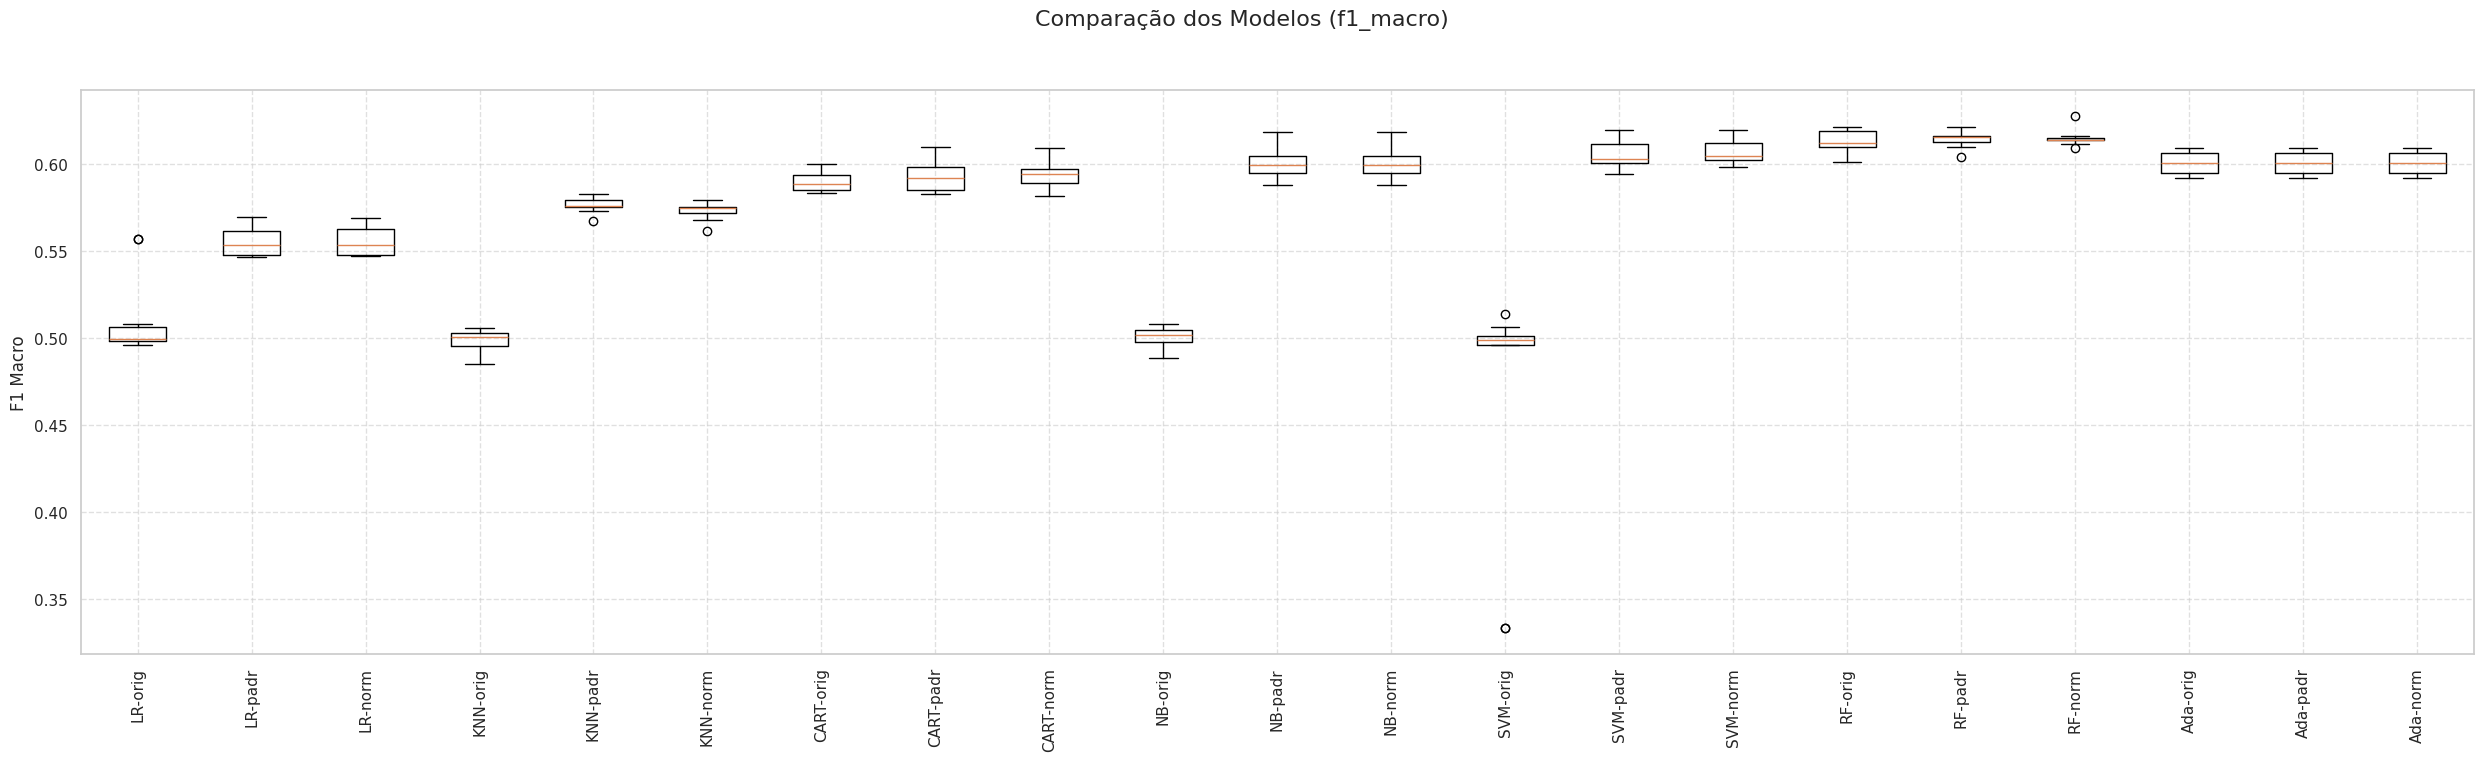

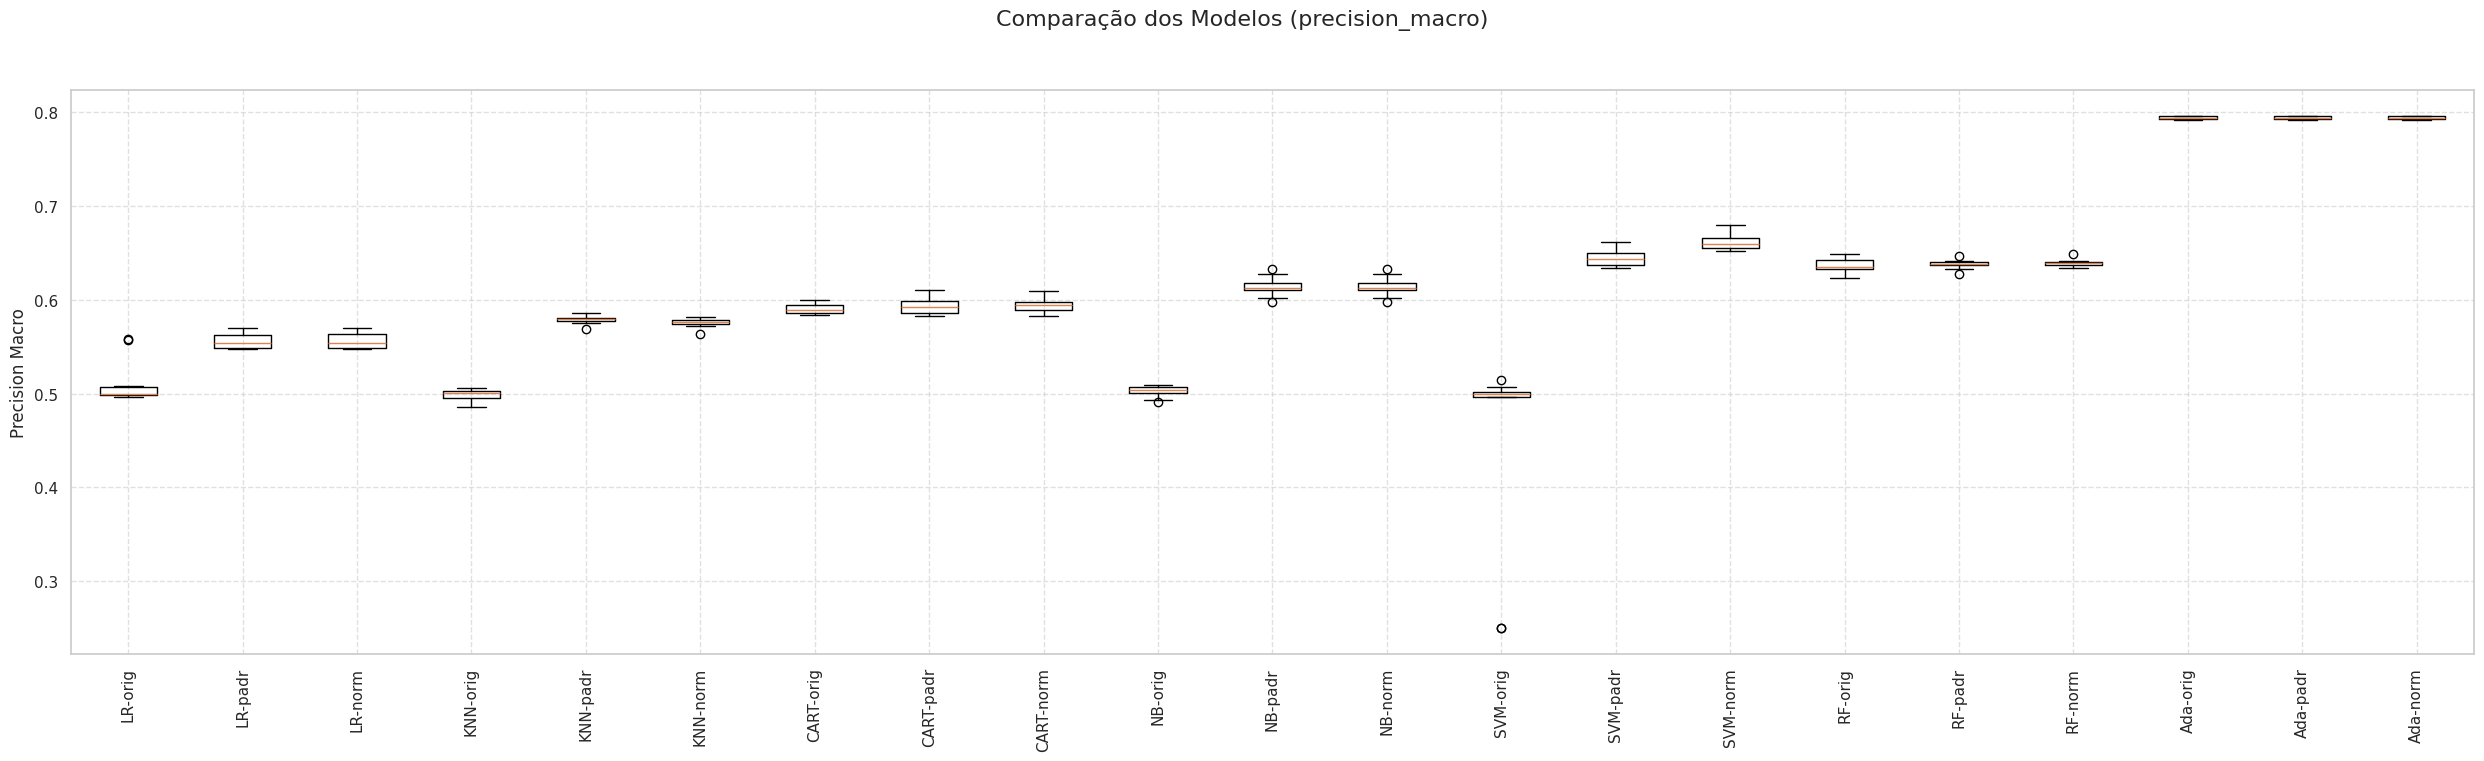

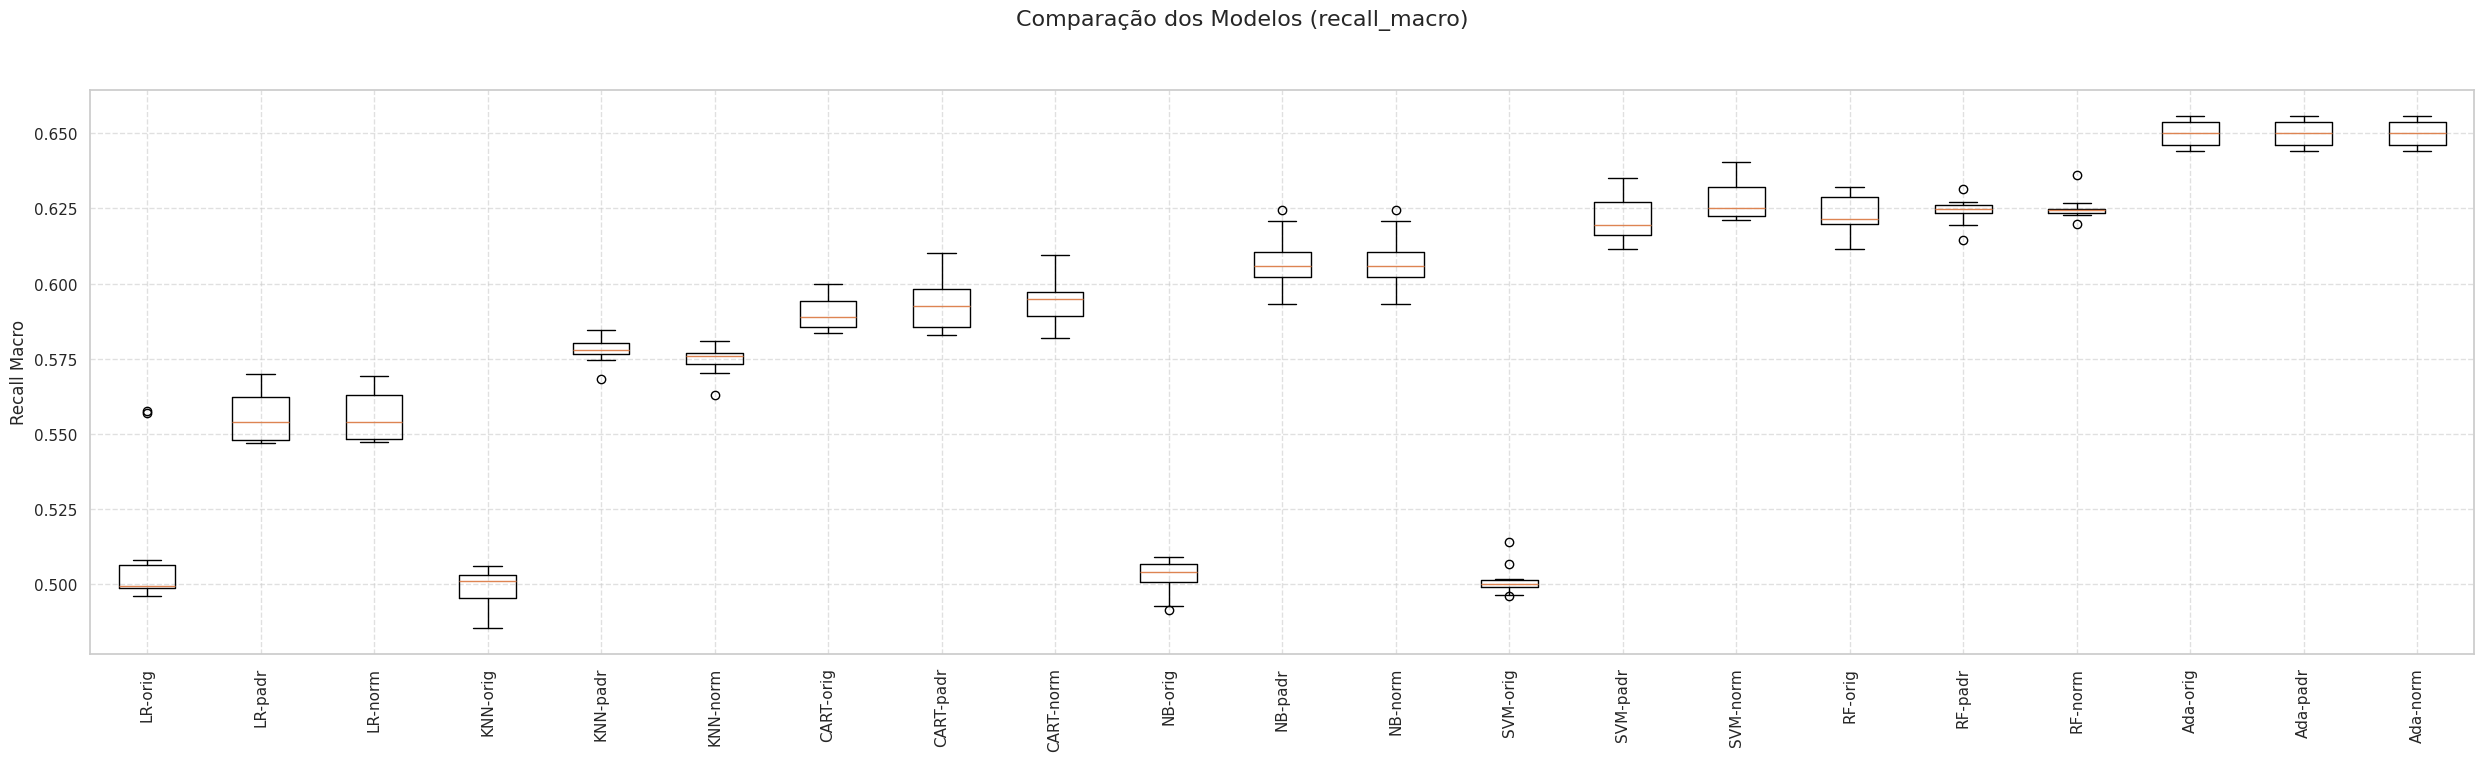

   pipeline_name  mean_f1_macro  mean_precision_macro  mean_recall_macro
0        LR-orig       0.511313              0.511374           0.511359
1        LR-padr       0.555455              0.555647           0.555583
2        LR-norm       0.555685              0.555866           0.555805
3       KNN-orig       0.498276              0.498297           0.498297
4       KNN-padr       0.576662              0.578662           0.577806
5       KNN-norm       0.573309              0.575502           0.574596
6      CART-orig       0.589949              0.590098           0.590029
7      CART-padr       0.593410              0.593460           0.593437
8      CART-norm       0.594416              0.594478           0.594449
9        NB-orig       0.500281              0.502310           0.502273
10       NB-padr       0.601167              0.613859           0.607092
11       NB-norm       0.601167              0.613859           0.607092
12      SVM-orig       0.467972              0.4513

In [ ]:
#Bloqueado por demorar demais
# df_resultados3 = executar_comparacao_modelos(X3, y3, models=models_to_compare, scalers=scalers_to_compare)

# colunas_resumo3 = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados3[colunas_resumo3])

#Resultados parciais



| Modelo | Pré-processamento | F1 Macro | Precision Macro | Recall Macro |
| :--- | :--- | :--- | :--- | :--- |
| LR | orig | 0.511 (0.023) | 0.511 (0.023) | 0.511 (0.023) |
| LR | padr | 0.555 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| LR | norm | 0.556 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| KNN | orig | 0.498 (0.007) | 0.498 (0.007) | 0.498 (0.007) |
| KNN | padr | 0.577 (0.004) | 0.579 (0.004) | 0.578 (0.004) |
| KNN | norm | 0.573 (0.005) | 0.576 (0.005) | 0.575 (0.005) |
| CART | orig | 0.590 (0.005) | 0.590 (0.005) | 0.590 (0.005) |
| CART | padr | 0.593 (0.009) | 0.593 (0.009) | 0.593 (0.009) |
| CART | norm | 0.594 (0.007) | 0.594 (0.007) | 0.594 (0.007) |
| NB | orig | 0.500 (0.006) | 0.502 (0.006) | 0.502 (0.006) |
| NB | padr | 0.601 (0.009) | 0.614 (0.010) | 0.607 (0.009) |
| NB | norm | 0.601 (0.009) | 0.614 (0.010) | 0.607 (0.009) |
| SVM | orig | 0.468 (0.068) | 0.451 (0.101) | 0.501 (0.005) |
| SVM | padr | 0.605 (0.008) | 0.644 (0.009) | 0.621 (0.008) |
| SVM | norm | 0.607 (0.007) | 0.662 (0.009) | 0.628 (0.007) |
| RF | orig | 0.614 (0.006) | 0.637 (0.007) | 0.623 (0.006) |
| RF | padr | 0.614 (0.004) | 0.638 (0.005) | 0.624 (0.004) |
| RF | norm | 0.615 (0.005) | 0.639 (0.004) | 0.625 (0.004) |
| Ada | orig | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada | padr | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada | norm | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |



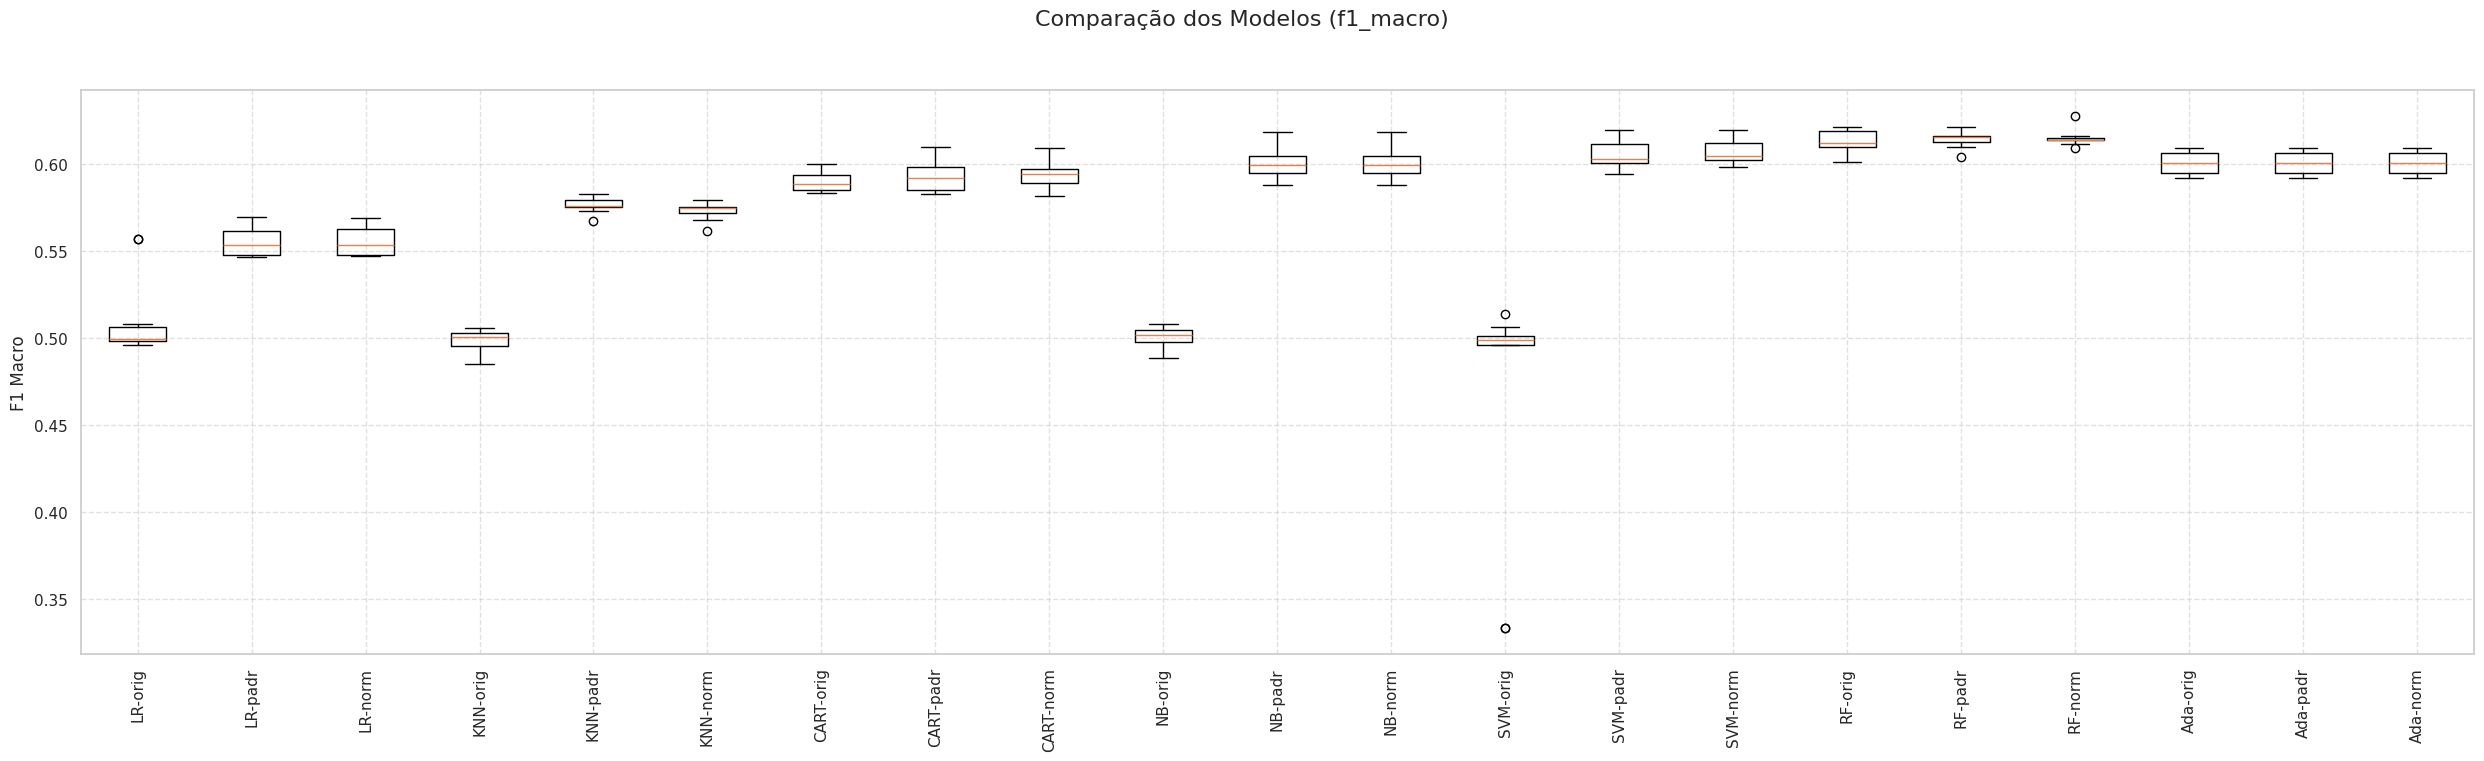





In [23]:
#Bloqueado por demorar demais
scaler4 = MinMaxScaler()
X_train_scaled4 = scaler4.fit_transform(X_train3)
X_test_scaled4 = scaler4.transform(X_test3)

#Do resultado obtido anteriormente, identificou-se que os resultados não mudaram por conta da quantidade e layers, então serão alteradas outras variáveis.
#Outra mudança foi a alteração da quantidade de epochs para 20 pois
# modelo_treinado_peq2, historico_peq2 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled4,
#     y_train=y_train3,
#     X_test=X_test_scaled4,
#     y_test=y_test3,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6166

F1-Score no conjunto de teste: 0.6673


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.67 | 0.46 | 0.55 | 6075 |
| 1 | 0.59 | 0.77 | 0.67 | 6075 |
| **accuracy** | | | **0.62** | **12150** |
| **macro avg** | 0.63 | 0.62 | 0.61 | 12150 |
| **weighted avg** | 0.63 | 0.62 | 0.61 | 12150 |


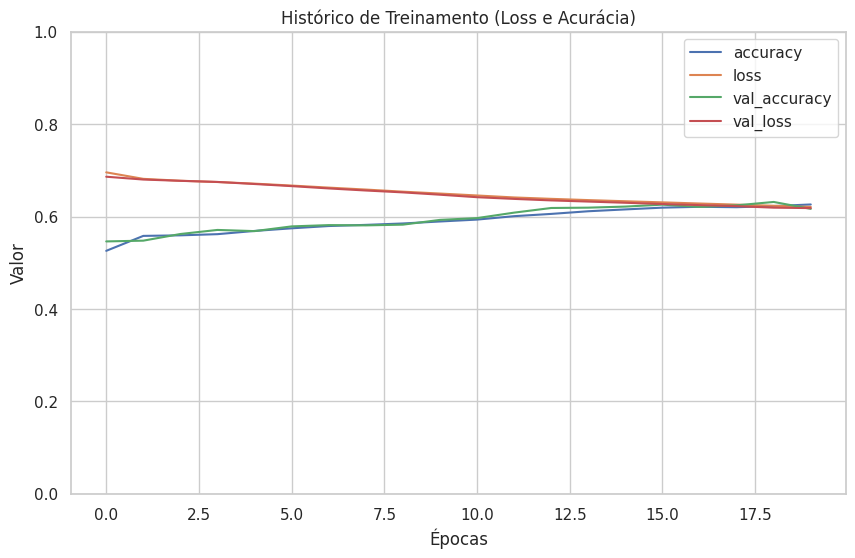

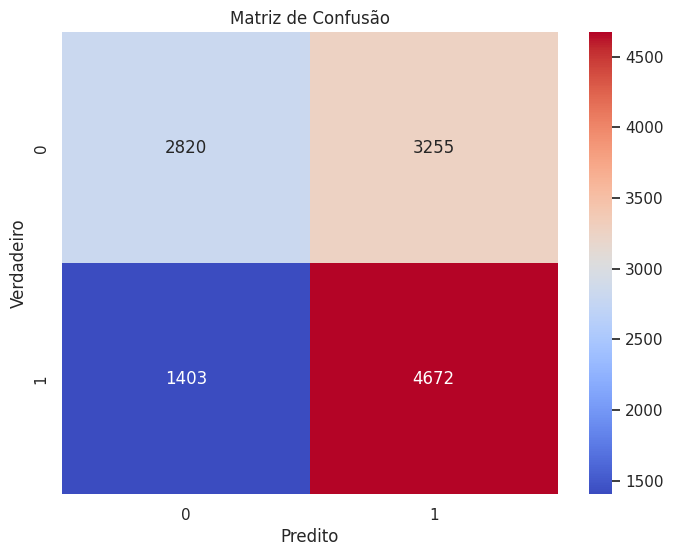

#Análise dos resultados

Com o balanceamento dos dados houve novamente uma melhora nos valores de acurácia, f1 e recall, porém o modelo que se destacou no valor "f1" foi o Random Forest(RF) com dados normalizados. O que chama atenção é que os quartis do box plot ficaram pequenos e mesmo os outliers ficaram próximos da mediana.

Para o modelo de rede neural, novamente a acurácia diminuiu, porém aumentou significativamente a acurácia na detecção de cancelamentos. Aparentemente o número de épocas precisa ser aumentado, mas antes de explorar mais esses dados será avaliado o resultado de uma nova alternativa. Essa avaliará se é possível melhorar o resultado se eliminar os atributos de tempo. Esse foi um ponto de atenção informado pelos orientadores do curso em aula de dúvidas do MVP e de fato apresenta grande relevancia ao modelo. A combinação de dias e horários pode criar características que não se repetem linearmente durante o ano seguinte, como por exemplo feriados e finais de semana.

In [24]:

# Separar features (X) e target (y)
X4 = df_balanceado2[['Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']]
y4 = df_balanceado2['Cancelled Rides by Driver']
# Dividir os dados em conjuntos de treino e teste
X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y4, test_size=0.3, random_state=42, stratify=y4)
print(f"Dimensões de X_train2: {X_train4.shape}")
print(f"Dimensões de X_test2: {X_test4.shape}")
print(f"Dimensões de y_train2: {y_train4.shape}")
print(f"Dimensões de y_test2: {y_test4.shape}")

Dimensões de X_train2: (28348, 9)
Dimensões de X_test2: (12150, 9)
Dimensões de y_train2: (28348,)
Dimensões de y_test2: (12150,)


Iniciando comparação de modelos...
--- LR-orig ---
  f1_macro: 0.556 (0.008)
  precision_macro: 0.556 (0.008)
  recall_macro: 0.556 (0.008)
--- LR-padr ---
  f1_macro: 0.556 (0.008)
  precision_macro: 0.556 (0.008)
  recall_macro: 0.556 (0.008)
--- LR-norm ---
  f1_macro: 0.556 (0.008)
  precision_macro: 0.556 (0.008)
  recall_macro: 0.556 (0.008)
--- KNN-orig ---
  f1_macro: 0.597 (0.004)
  precision_macro: 0.600 (0.004)
  recall_macro: 0.599 (0.004)
--- KNN-padr ---
  f1_macro: 0.591 (0.005)
  precision_macro: 0.594 (0.004)
  recall_macro: 0.593 (0.004)
--- KNN-norm ---
  f1_macro: 0.591 (0.006)
  precision_macro: 0.593 (0.006)
  recall_macro: 0.592 (0.006)
--- CART-orig ---
  f1_macro: 0.588 (0.006)
  precision_macro: 0.589 (0.006)
  recall_macro: 0.589 (0.006)
--- CART-padr ---
  f1_macro: 0.588 (0.005)
  precision_macro: 0.589 (0.005)
  recall_macro: 0.588 (0.005)
--- CART-norm ---
  f1_macro: 0.588 (0.005)
  precision_macro: 0.588 (0.005)
  recall_macro: 0.588 (0.005)
--- NB-orig

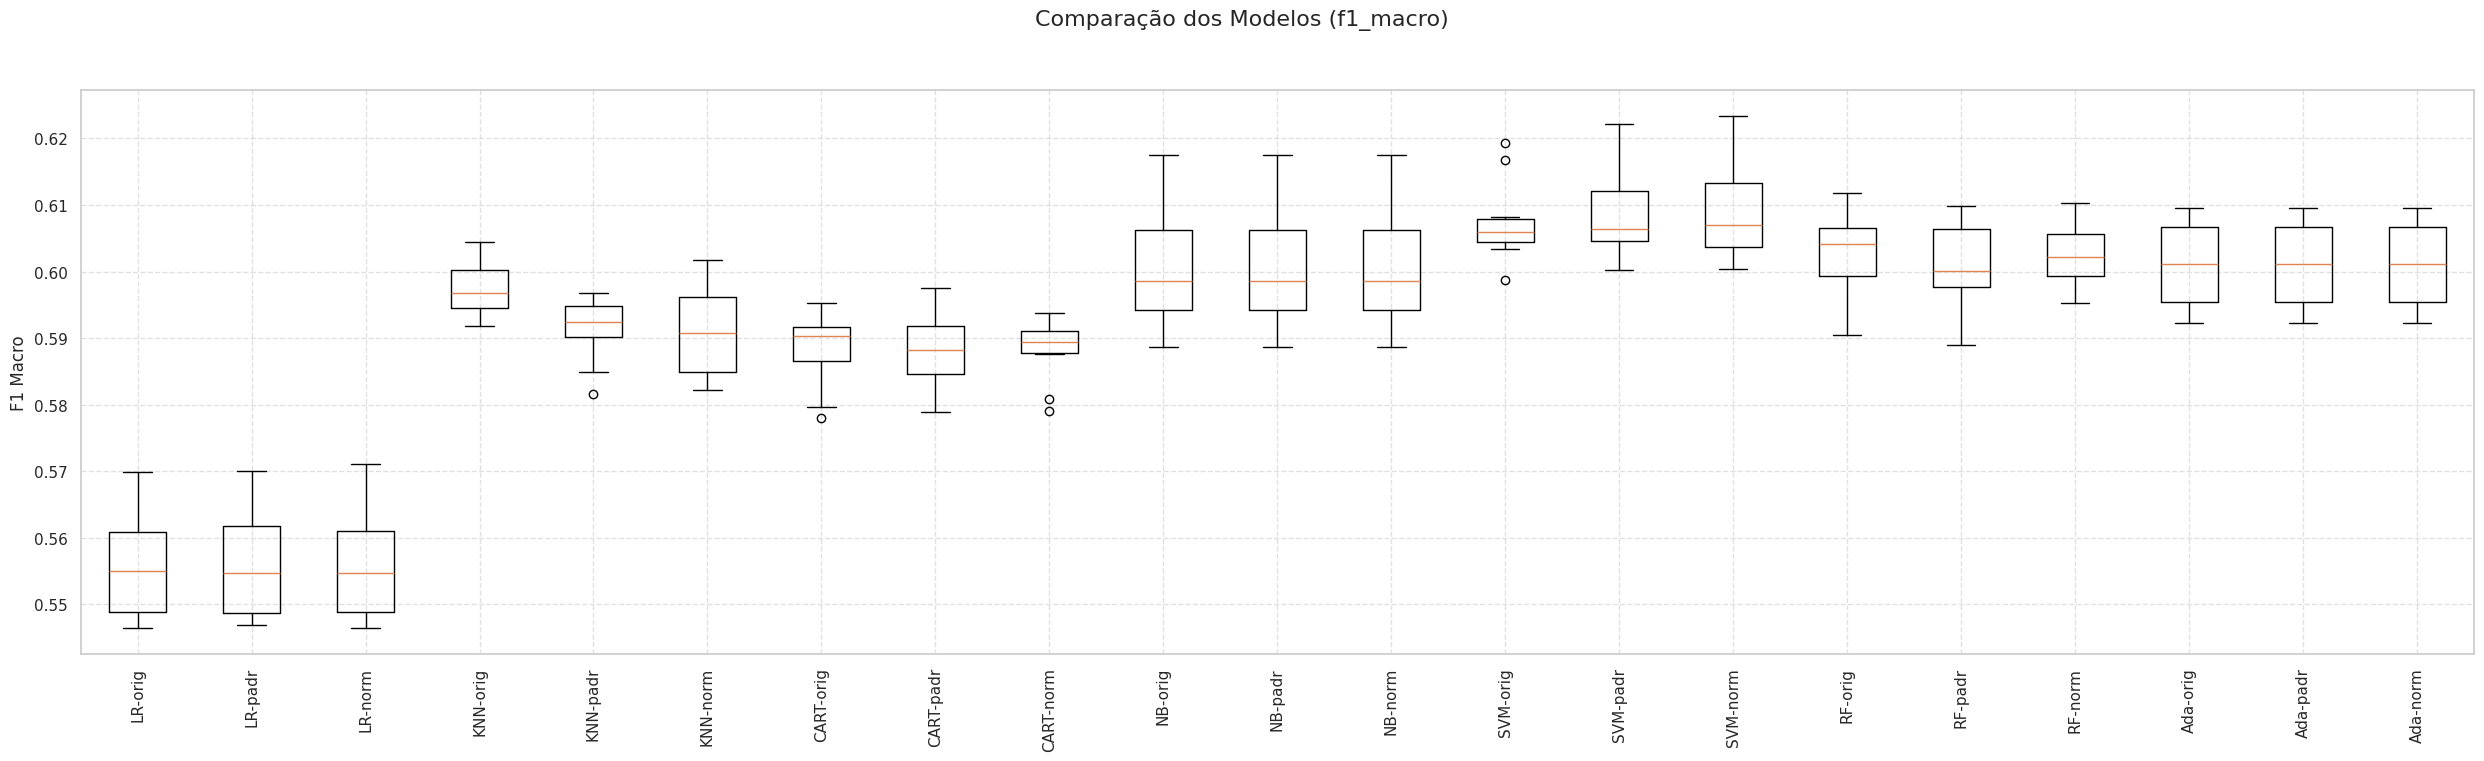

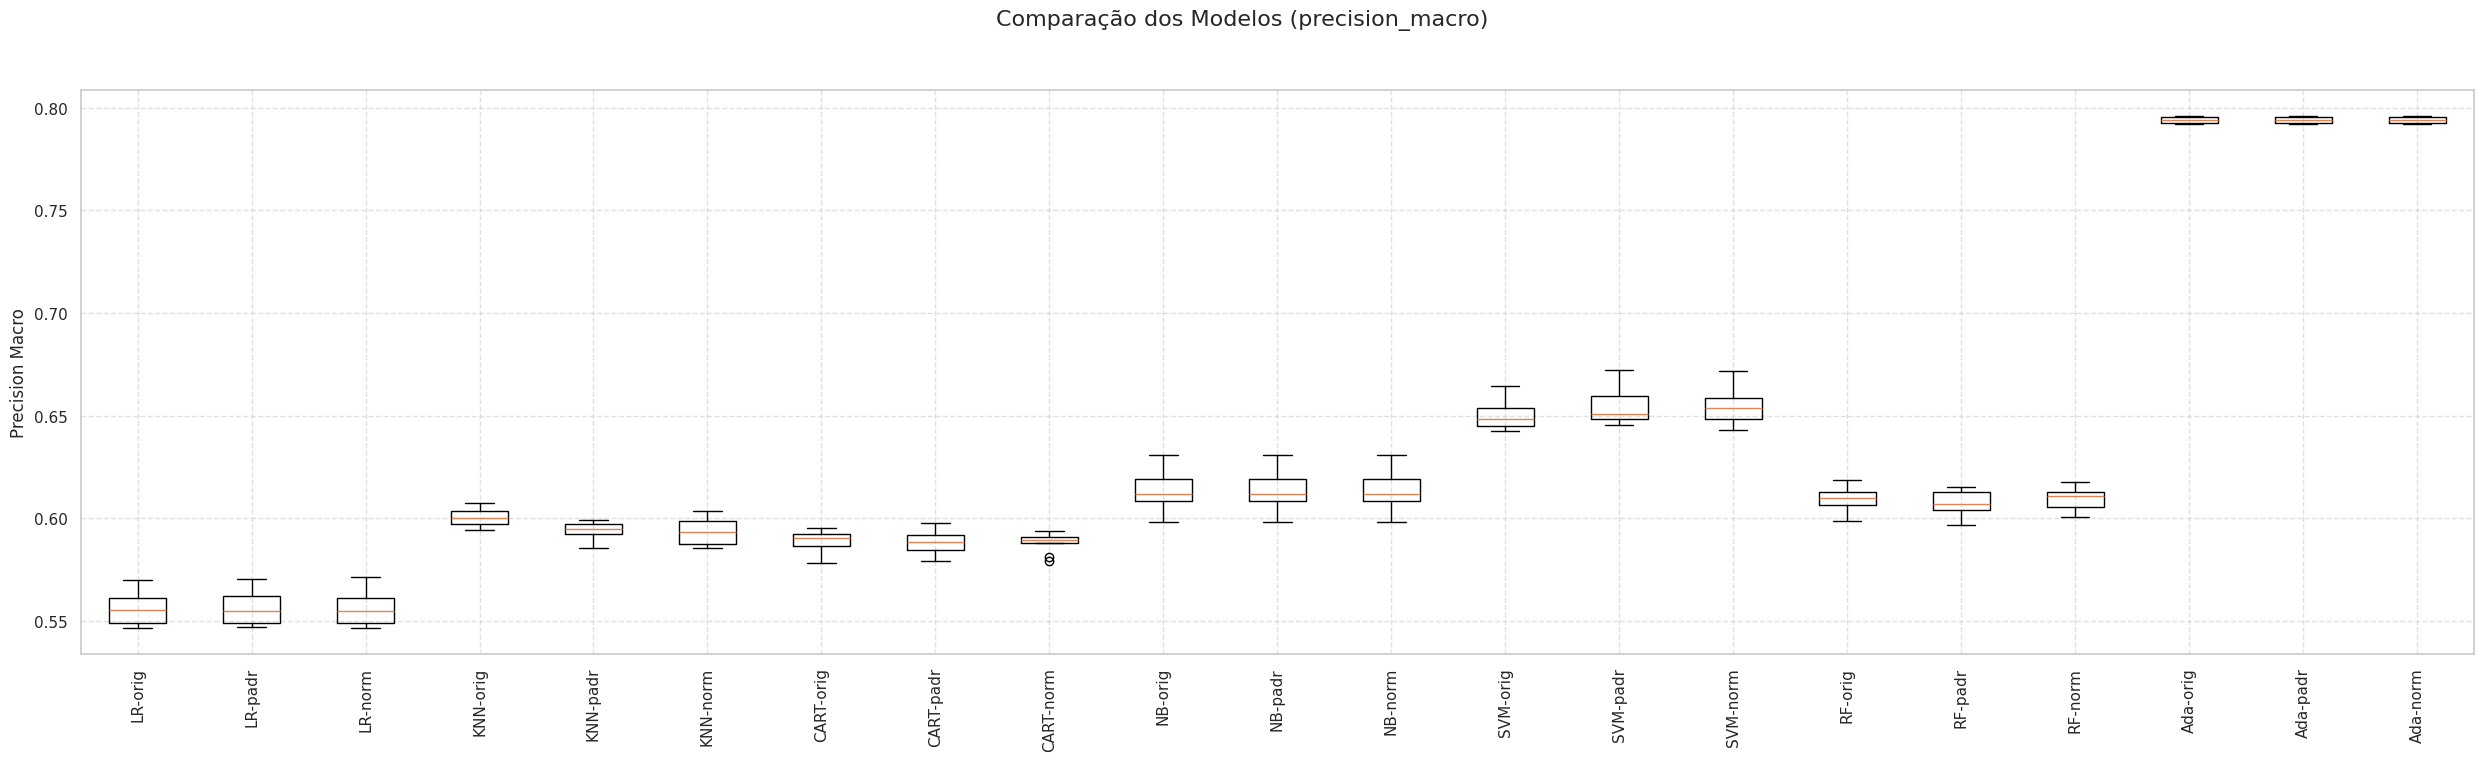

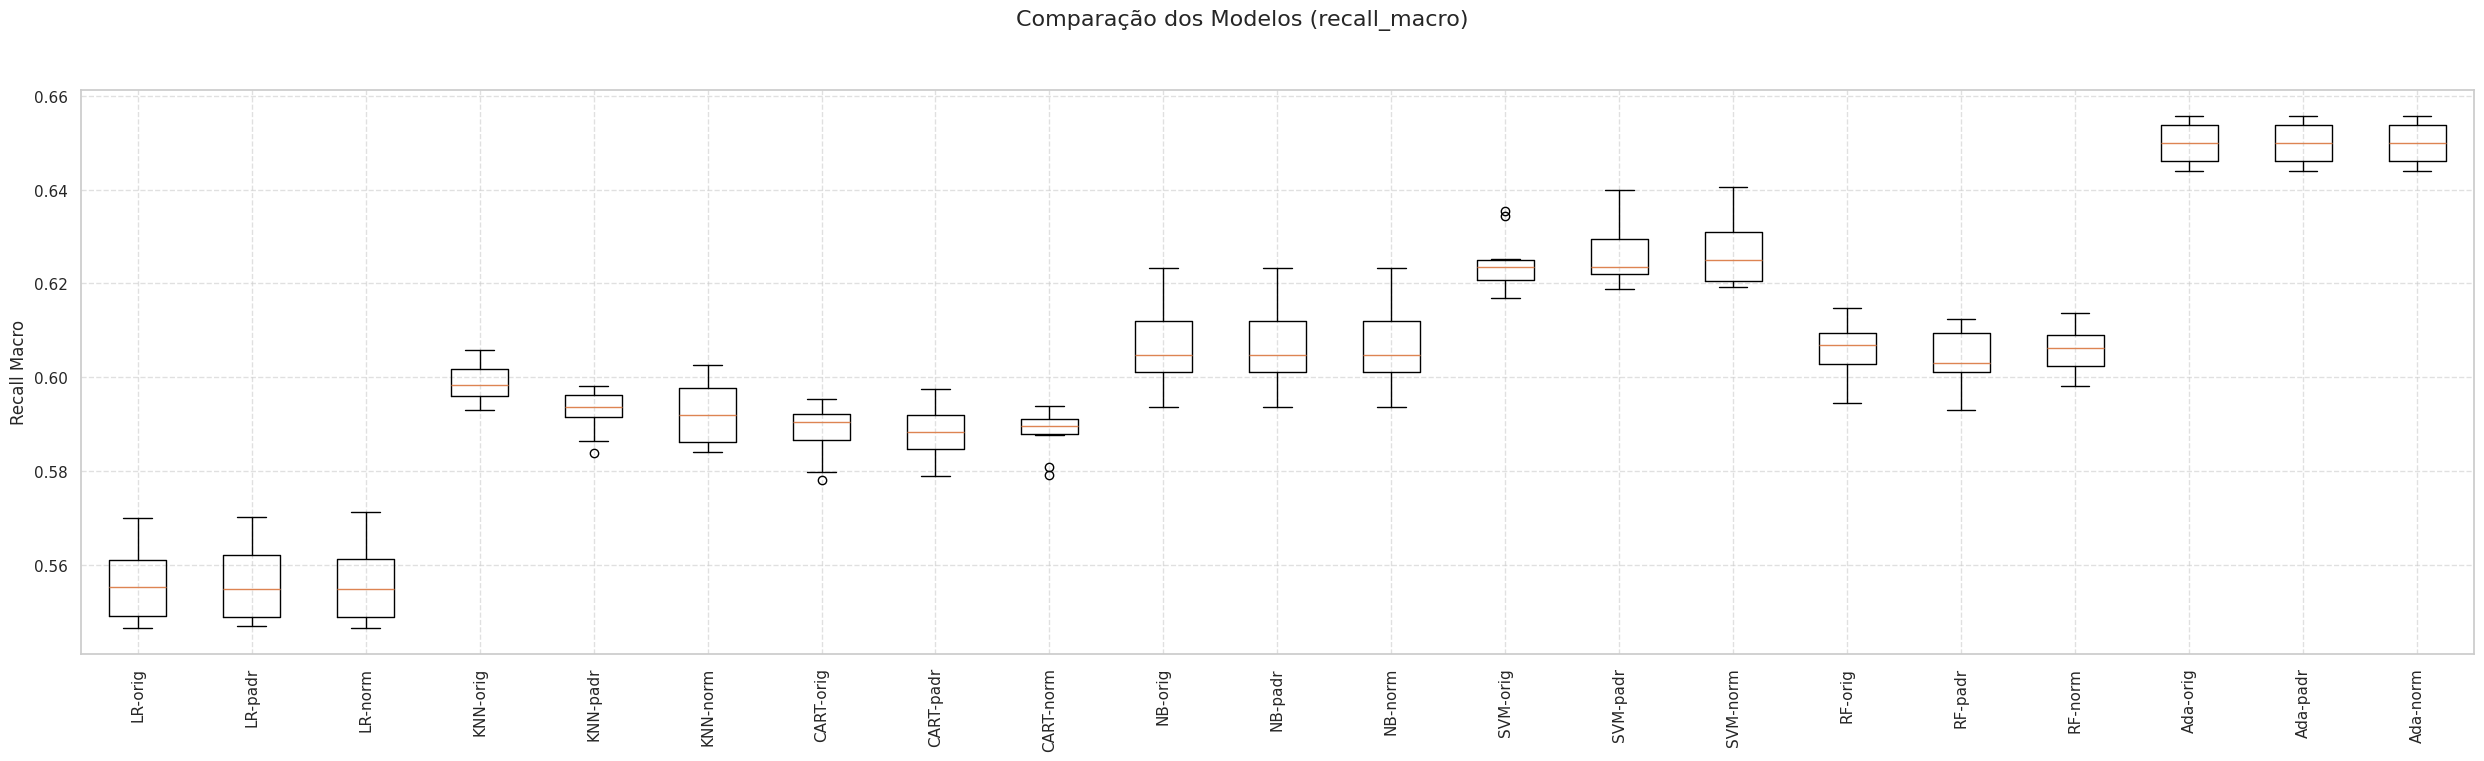

   pipeline_name  mean_f1_macro  mean_precision_macro  mean_recall_macro
0        LR-orig       0.555729              0.555917           0.555855
1        LR-padr       0.555757              0.555940           0.555879
2        LR-norm       0.555782              0.555965           0.555904
3       KNN-orig       0.597308              0.600429           0.598870
4       KNN-padr       0.591340              0.593838           0.592647
5       KNN-norm       0.590787              0.593393           0.592153
6      CART-orig       0.588446              0.588593           0.588524
7      CART-padr       0.588412              0.588527           0.588474
8      CART-norm       0.588217              0.588329           0.588276
9        NB-orig       0.600639              0.613310           0.606574
10       NB-padr       0.600639              0.613310           0.606574
11       NB-norm       0.600639              0.613310           0.606574
12      SVM-orig       0.607433              0.6508

In [ ]:
# #Bloqueado por demorar emais
# df_resultados4 = executar_comparacao_modelos(X4, y4, models=models_to_compare, scalers=scalers_to_compare)

# colunas_resumo4 = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados4[colunas_resumo4])

#Resultados parciais


| Modelo | Pré-processamento | F1 Macro | Precision Macro | Recall Macro |
| :--- | :--- | :--- | :--- | :--- |
| LR | orig | 0.556 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| LR | padr | 0.556 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| LR | norm | 0.556 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| KNN | orig | 0.597 (0.004) | 0.600 (0.004) | 0.599 (0.004) |
| KNN | padr | 0.591 (0.005) | 0.594 (0.004) | 0.593 (0.004) |
| KNN | norm | 0.591 (0.006) | 0.593 (0.006) | 0.592 (0.006) |
| CART | orig | 0.588 (0.006) | 0.589 (0.006) | 0.589 (0.006) |
| CART | padr | 0.588 (0.005) | 0.589 (0.005) | 0.588 (0.005) |
| CART | norm | 0.588 (0.005) | 0.588 (0.005) | 0.588 (0.005) |
| NB | orig | 0.601 (0.009) | 0.613 (0.009) | 0.607 (0.009) |
| NB | padr | 0.601 (0.009) | 0.613 (0.009) | 0.607 (0.009) |
| NB | norm | 0.601 (0.009) | 0.613 (0.009) | 0.607 (0.009) |
| SVM | orig | 0.607 (0.006) | 0.651 (0.007) | 0.625 (0.006) |
| SVM | padr | 0.608 (0.007) | 0.654 (0.008) | 0.626 (0.006) |
| SVM | norm | 0.609 (0.007) | 0.655 (0.008) | 0.627 (0.007) |
| RF | orig | 0.603 (0.006) | 0.609 (0.005) | 0.606 (0.006) |
| RF | padr | 0.601 (0.006) | 0.608 (0.006) | 0.604 (0.006) |
| RF | norm | 0.602 (0.004) | 0.609 (0.005) | 0.606 (0.005) |
| Ada | orig | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada | padr | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada | norm | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |


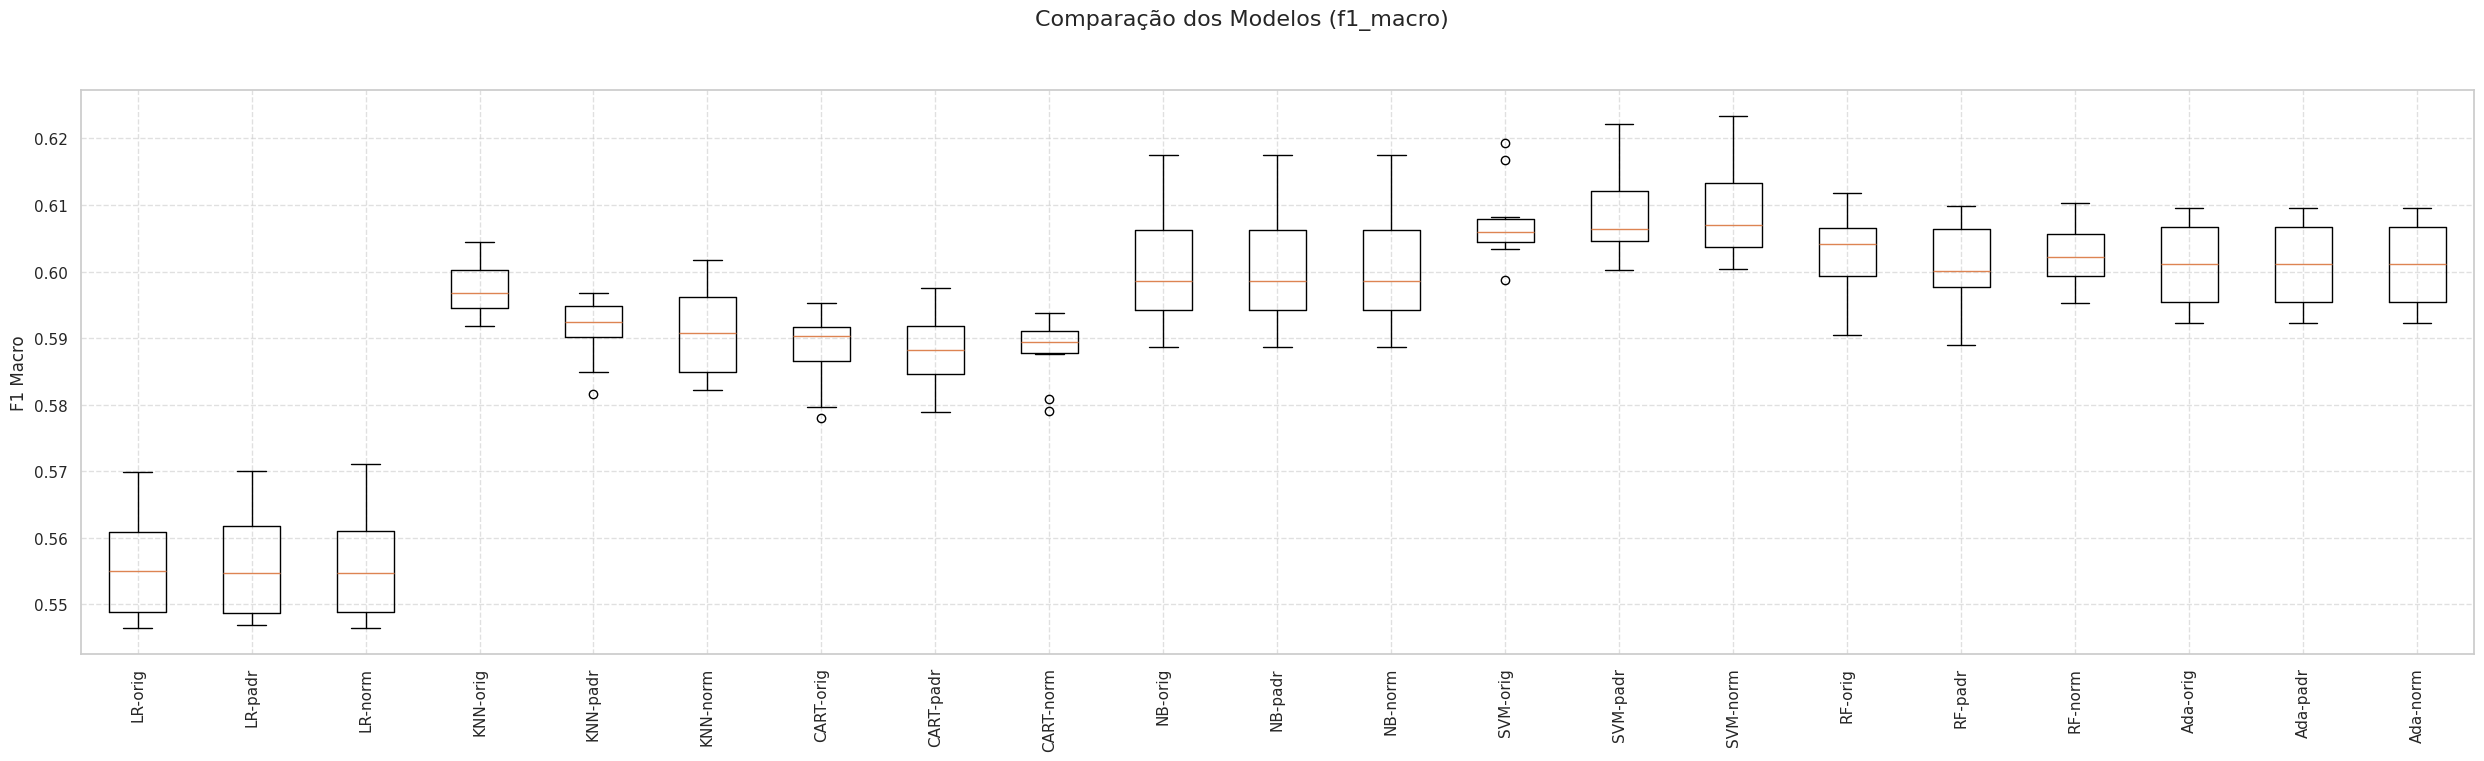


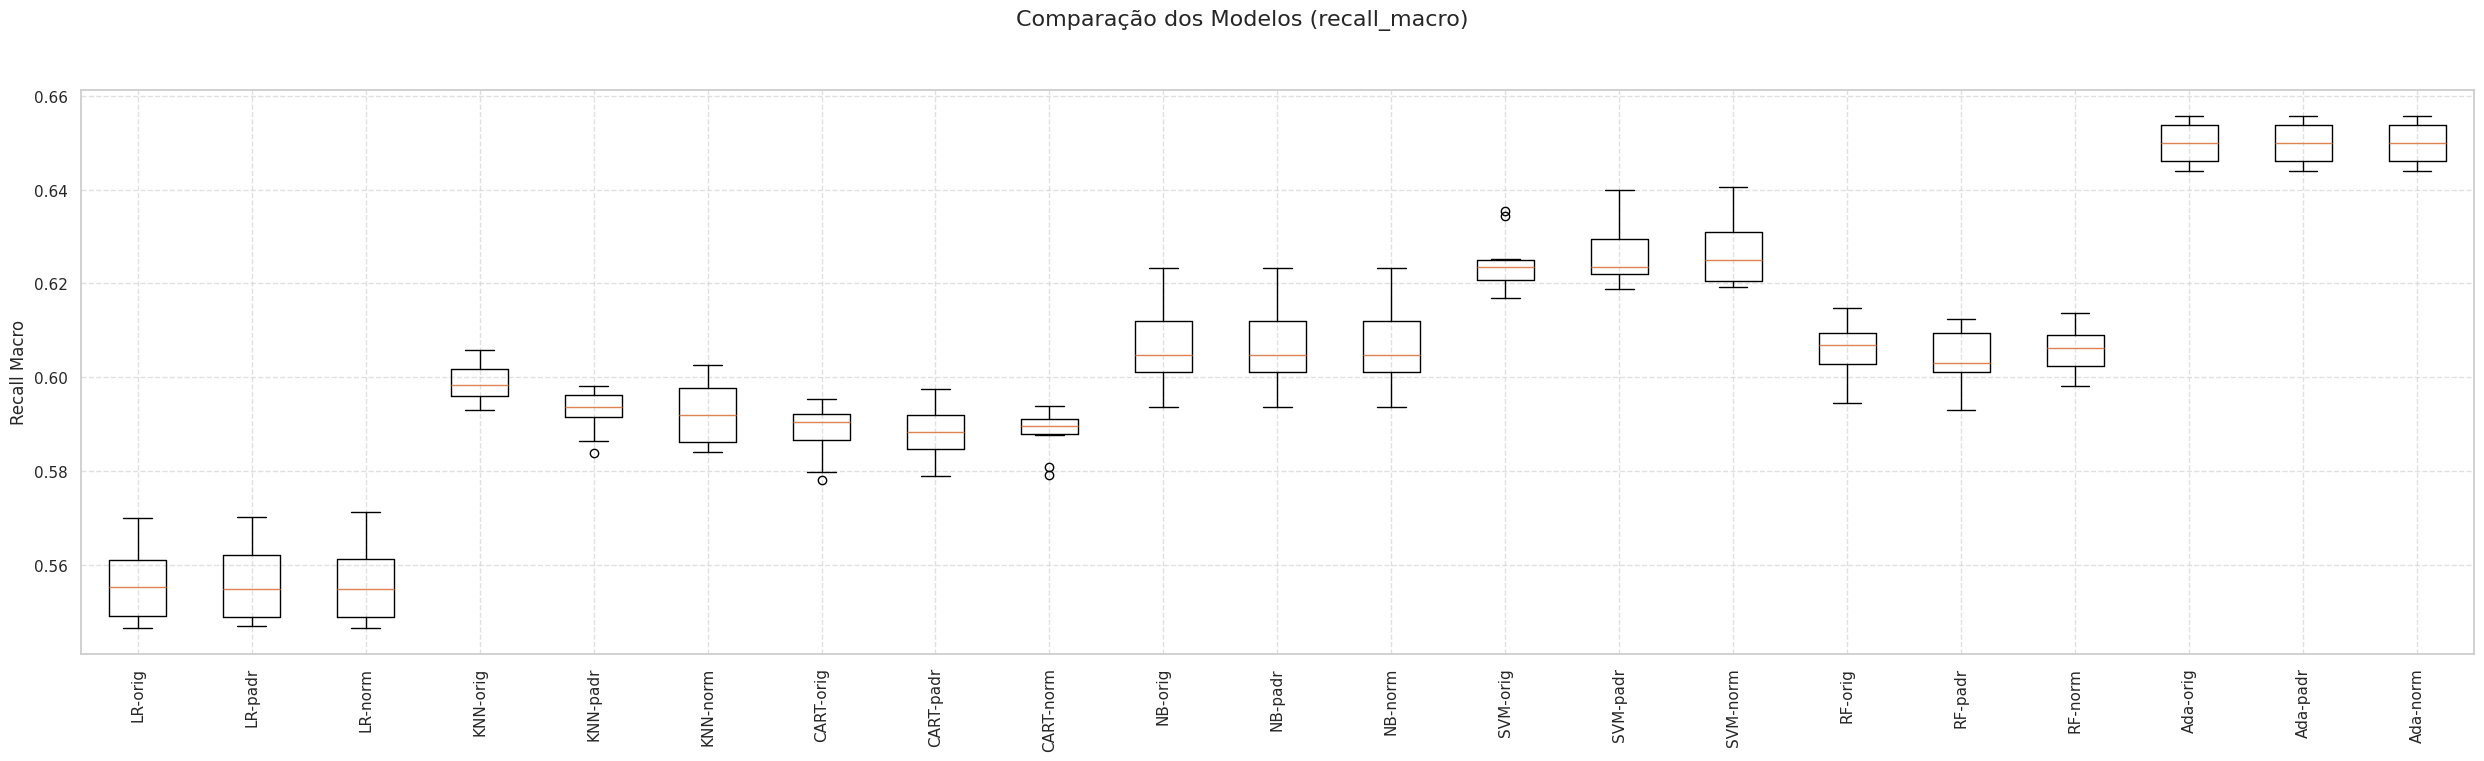


In [25]:
#Bloqueado por demorar demais
scaler5 = MinMaxScaler()
X_train_scaled5 = scaler5.fit_transform(X_train4)
X_test_scaled5 = scaler5.transform(X_test4)


# modelo_treinado_peq5, historico_peq5 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=32
# )

#Resultados parciais
Acurácia no conjunto de teste: 0.6226

F1-Score no conjunto de teste: 0.7007



### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.76 | 0.36 | 0.49 | 6075 |
| 1 | 0.58 | 0.88 | 0.70 | 6075 |
| **accuracy** | | | **0.62** | **12150** |
| **macro avg** | 0.67 | 0.62 | 0.59 | 12150 |
| **weighted avg** | 0.67 | 0.62 | 0.59 | 12150 |

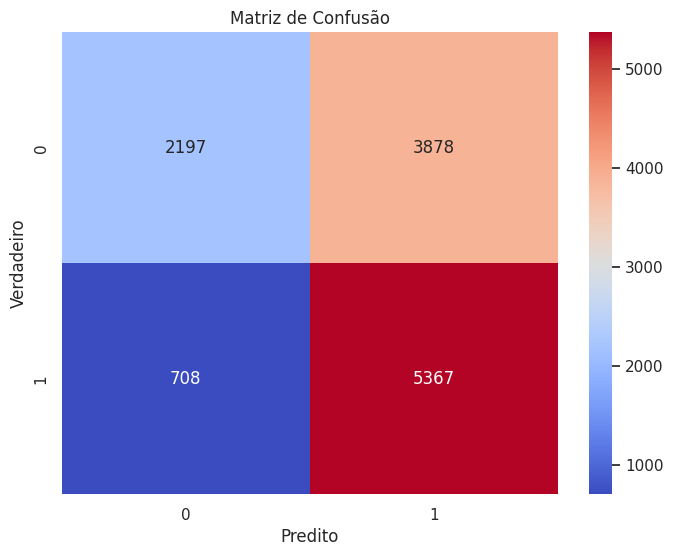

#Análise dos resultados
Com a eliminação das variáveis de data e hora, o modelo SVM apresentou resultados superiores na métrica "F1". Levando em consideração que o objetivo do modelo é evitar que um cancelamento seja feito, a métrica "recall" deve ser considerada, então entendo que o modelo Ada também é relevante. A partir disso vou alterar alguns parâmetros para tentar otimizar esse modelo.

Quanto a rede neural, as métricas melhoraram mas é necessário avaliar os hiperparâmetros para entender qual a melhor condição.

Por fim optou-se por usar os dados sem o atributo de data e hora e tentar otimizá-los pois há várias vantagens em relação a aplicação do modelo (sem problemas com relação aos feriados, sem combinações de horas que podem ser específicas de um ano, sem efeitos de um evento de um dia em um local específico e menos atributos necessários).

In [ ]:
#Análise dos modelos

#Bloqueado por demorar demais

models_to_compare_final = {



    # --- Variações do Ada ---
    'Ada-n200-lr0.1': AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=7),
    'Ada-n100-lr0.1': AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=7),
    'Ada-n100-lr1': AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=7),
    'Ada-n50-lr1': AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=7),

    # --- Variações do SVM ---
    'SVM-rbf-C1-gamma_scale': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=7),
    'SVM-rbf-C10-gamma_scale': SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=7),
    'SVM-rbf-C1-gamma_auto': SVC(kernel='rbf', C=1.0, gamma='auto', probability=True, random_state=7),
    'SVM-linear': SVC(kernel='linear', probability=True, random_state=7)

}

#Repetido pois já havia bloqueado a célula
scalers_to_compare = {
    'padr': StandardScaler(),
    'norm': MinMaxScaler()
}


df_resultados_final = executar_comparacao_modelos(X4, y4, models=models_to_compare_final, scalers=scalers_to_compare)

colunas_resumo5 = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
print(df_resultados_final[colunas_resumo5])

Iniciando comparação de modelos...
--- Ada-n200-lr0.1-orig ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n200-lr0.1-padr ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n200-lr0.1-norm ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n100-lr0.1-orig ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n100-lr0.1-padr ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n100-lr0.1-norm ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n100-lr1-orig ---
  f1_macro: 0.601 (0.006)
  precision_macro: 0.794 (0.001)
  recall_macro: 0.650 (0.004)
--- Ada-n100-lr1-padr ---
  f1_macro: 0.601 (0.006)
  precision_macro: 0.794 (0.001)
  recall_macro: 0.650 (0.004)
--- Ada-n100-lr1-norm ---
  f1_ma

#Resultados parciais


### Tabela de Resultados dos Modelos

| **Modelo** | **F1-Score (macro)** | **Precision (macro)** | **Recall (macro)** |
|:---|:---:|:---:|:---:|
| CART-depth-5-orig | 0.607 (0.006) | 0.780 (0.004) | 0.652 (0.004) |
| CART-depth-5-padr | 0.607 (0.006) | 0.780 (0.004) | 0.652 (0.004) |
| CART-depth-5-norm | 0.607 (0.006) | 0.780 (0.004) | 0.652 (0.004) |
| CART-depth-10-orig | 0.607 (0.005) | 0.772 (0.007) | 0.651 (0.004) |
| CART-depth-10-padr | 0.607 (0.005) | 0.772 (0.007) | 0.651 (0.004) |
| CART-depth-10-norm | 0.607 (0.005) | 0.772 (0.007) | 0.651 (0.004) |
| CART-leaf-5-orig | 0.611 (0.004) | 0.682 (0.006) | 0.636 (0.004) |
| CART-leaf-5-padr | 0.611 (0.004) | 0.682 (0.006) | 0.636 (0.004) |
| CART-leaf-5-norm | 0.611 (0.004) | 0.682 (0.006) | 0.636 (0.004) |
| SVM-linear-orig | 0.557 (0.008) | 0.564 (0.008) | 0.561 (0.007) |
| SVM-linear-padr | 0.557 (0.007) | 0.565 (0.007) | 0.562 (0.007) |
| SVM-linear-norm | 0.557 (0.007) | 0.565 (0.007) | 0.565 (0.007) |
| SVM-rbf-C10-orig | 0.608 (0.007) | 0.720 (0.010) | 0.643 (0.006) |
| SVM-rbf-C10-padr | 0.608 (0.007) | 0.726 (0.011) | 0.643 (0.006) |
| SVM-rbf-C10-norm | 0.606 (0.008) | 0.650 (0.009) | 0.624 (0.007) |
| SVM-rbf-C0.1-orig | 0.607 (0.007) | 0.667 (0.010) | 0.629 (0.007) |
| SVM-rbf-C0.1-padr | 0.604 (0.008) | 0.643 (0.010) | 0.620 (0.008) |
| SVM-rbf-C0.1-norm | 0.572 (0.006) | 0.683 (0.006) | 0.613 (0.005) |

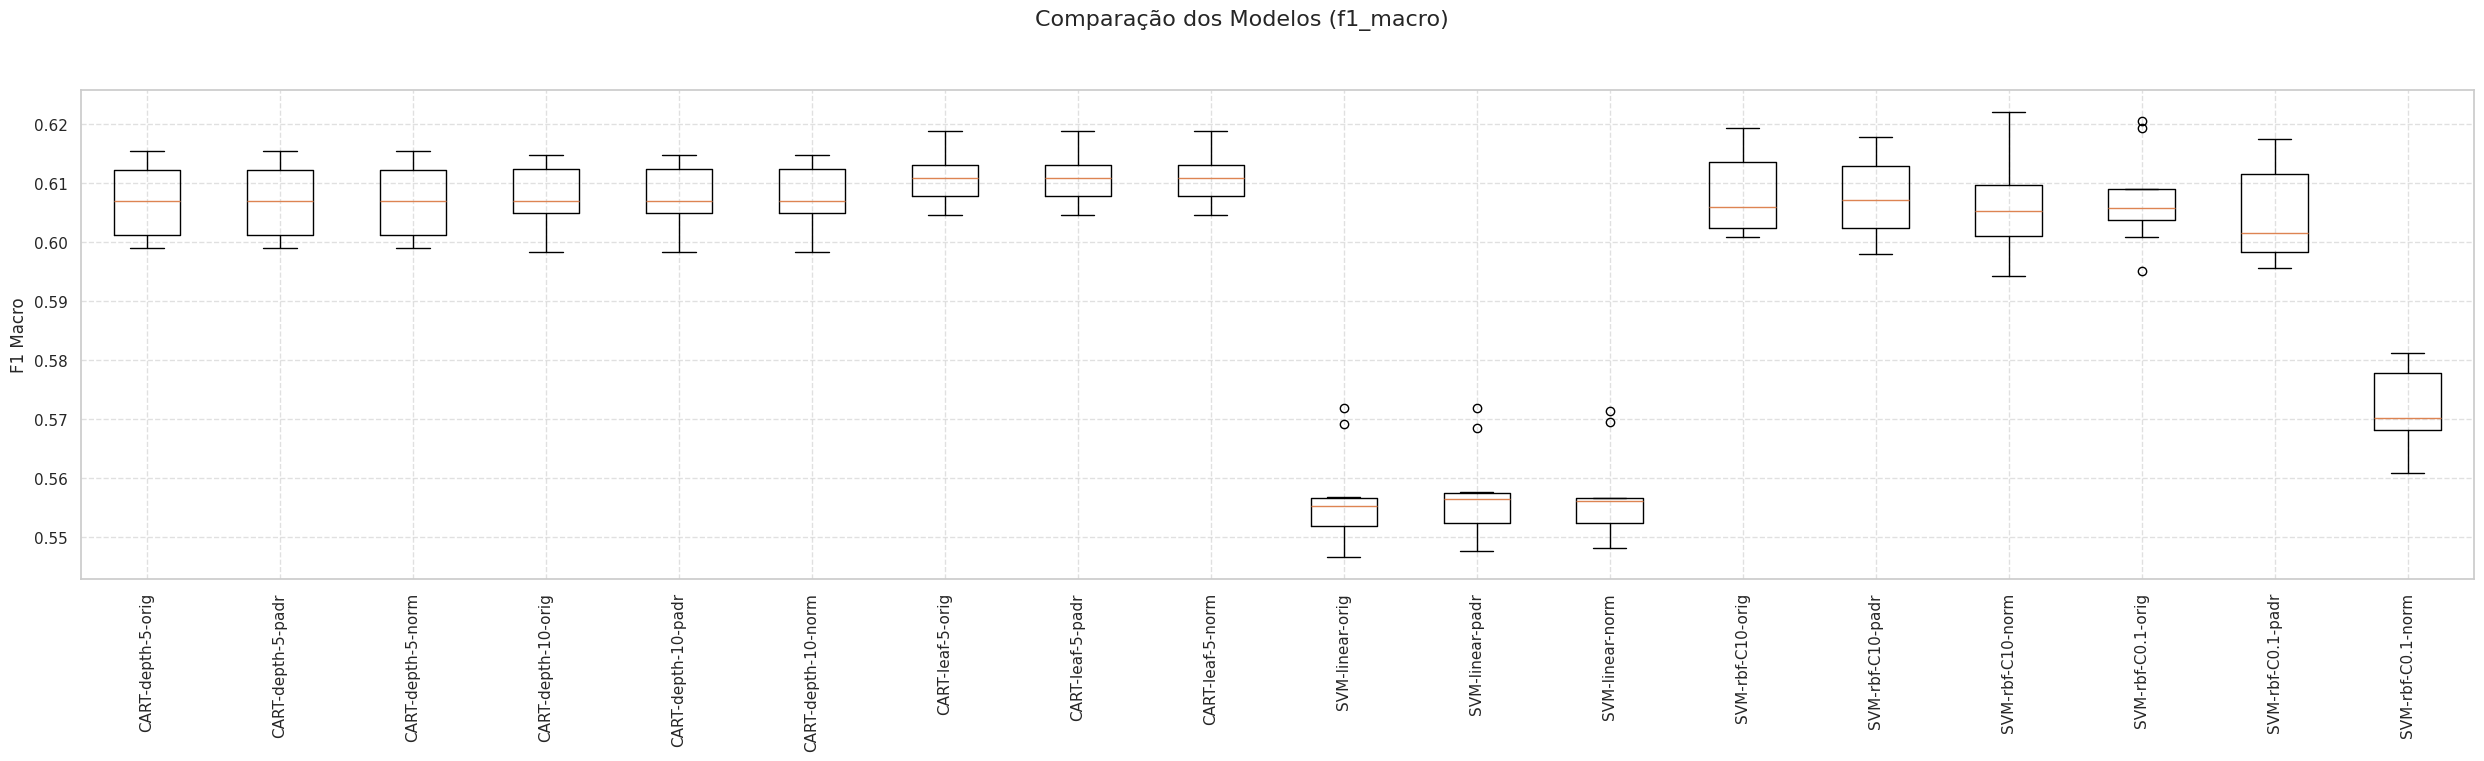

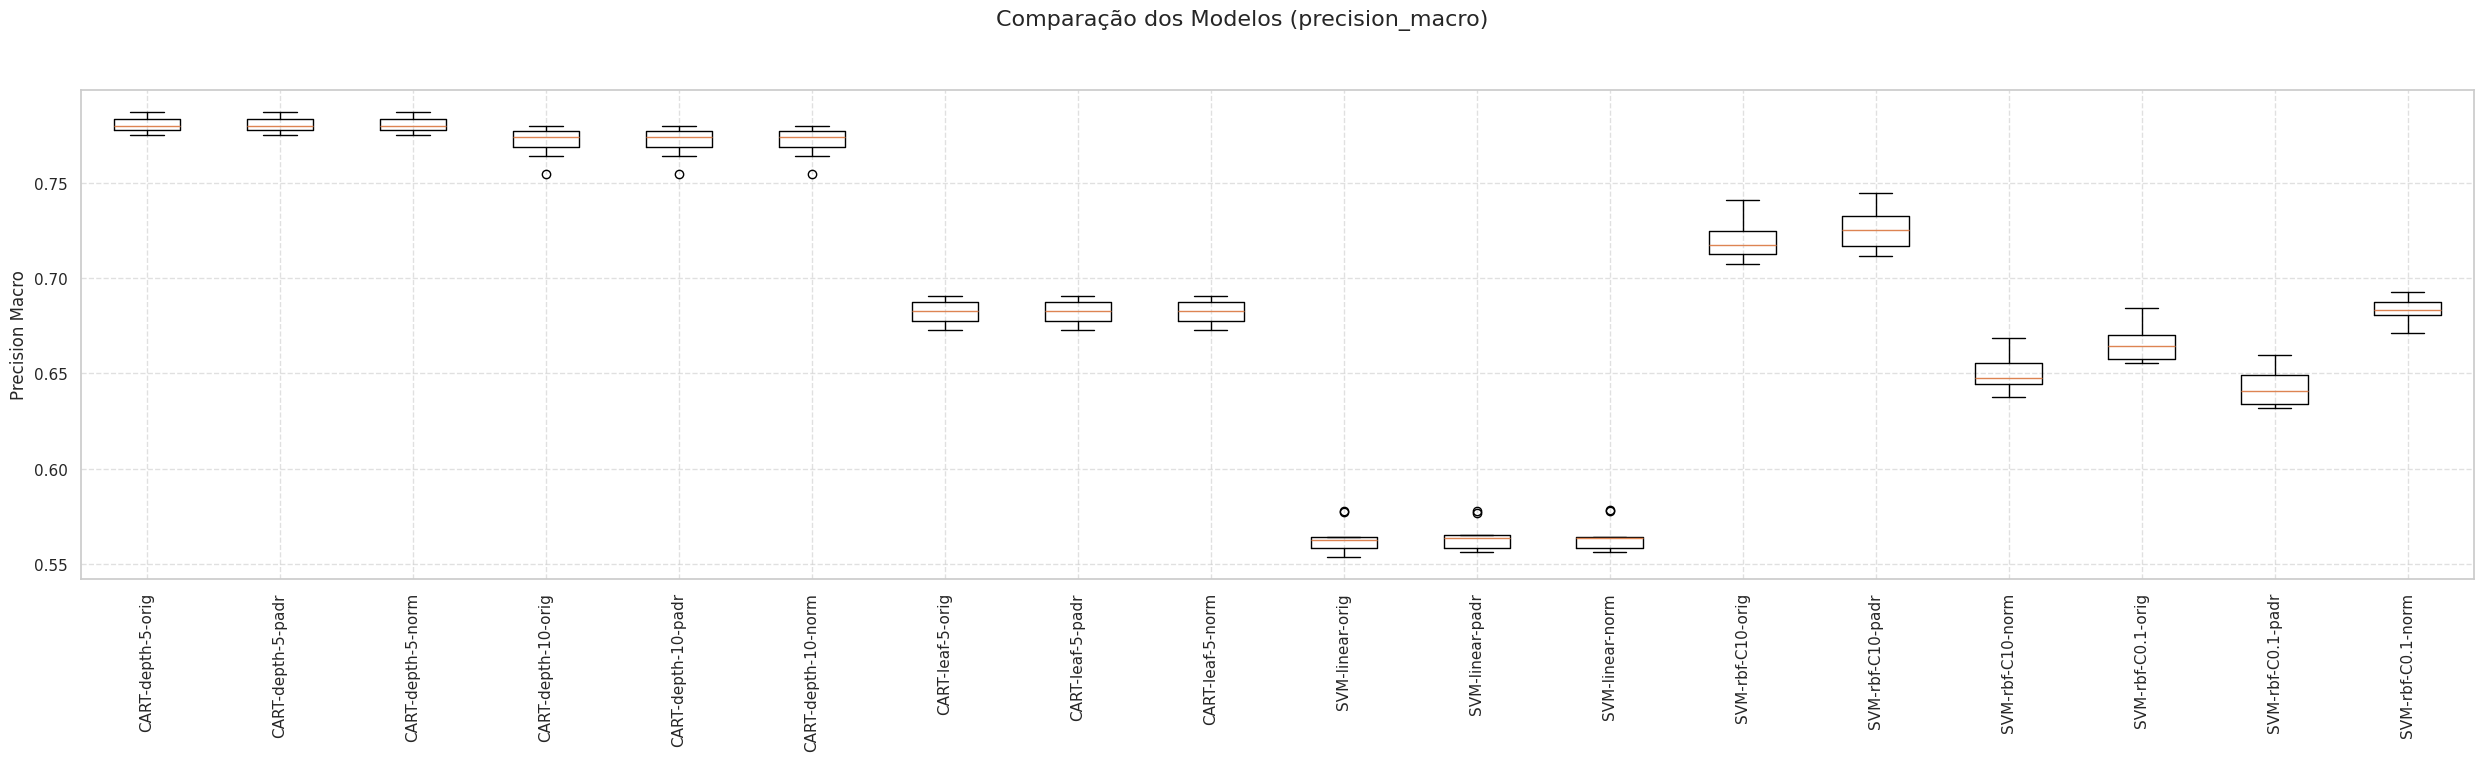

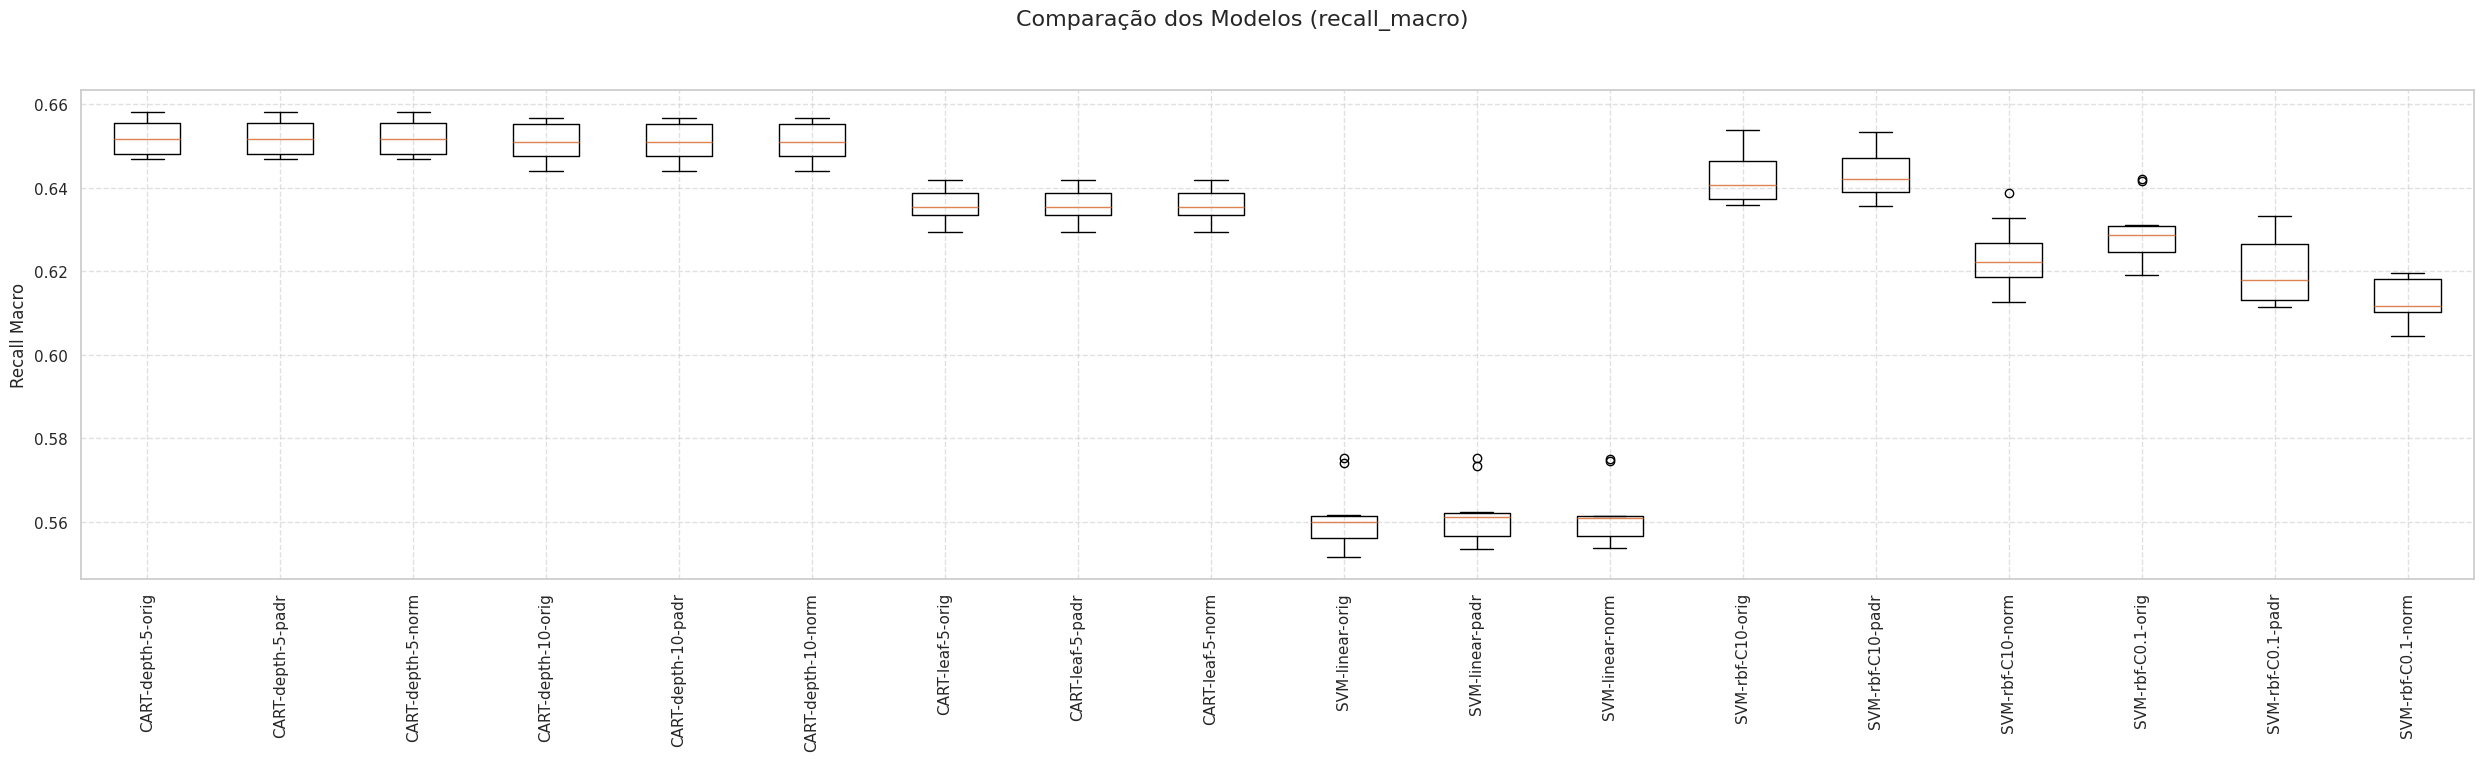

#Resultado da análise do modelo
O modelo CART-leaf-5 é o que apresentou melhor "f1" e o CART-depth-5 é o que apresento maior valor de "recall" sem reduzir o valor de "f1".

In [ ]:
#Salvando o primeiro modelo
# modelo_final_cart = DecisionTreeClassifier(min_samples_leaf=5, random_state=7)
# modelo_final_cart.fit(X4, y4)
# nome_arquivo_modelo = 'modelo_final_cart_leaf5.pkl'
# joblib.dump(modelo_final_cart, nome_arquivo_modelo)


In [ ]:
#Salvando o segundo modelo
# modelo_final_cart_depth = DecisionTreeClassifier(max_depth=5, random_state=7)
# modelo_final_cart_depth.fit(X4, y4)
# nome_arquivo_modelo2 = 'modelo_final_depth5.pkl'
# joblib.dump(modelo_final_cart_depth, nome_arquivo_modelo2)

#Início dos treinamentos de rede neural
Para esse treinamento algumas alterações serão feitas com o objetivo de avaliar diferentes condições. Pretendo alterar a quantidade de layers para identificar se há algo específico que os uma rede profunda pode identificar, número de épocas, optimizador e perda.


Resumo do Modelo:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 40 épocas com batch_size=32...
Epoch 1/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5210 - loss: 0.6914 - val_accuracy: 0.5547 - val_loss: 0.6800
Epoch 2/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5555 - loss: 0.6786 - val_accuracy: 0.5652 - val_loss: 0.6714
Epoch 3/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5649 - loss: 0.6696 - val_accuracy: 0.5763 - val_loss: 0.6618
Epoch 4/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5806 - loss: 0.6603 - val_accuracy: 0.5872 - val_loss: 0.6526
Epoch 5/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5905 - loss: 0.6517 - val_accuracy: 0.5933 - val_loss: 0.6451
Epoch 6/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6008 - loss: 0.6443 - val_accuracy: 0.6223 - val_loss: 0.6386
Epoch 7/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6156 - loss: 0.6380 - val_accu

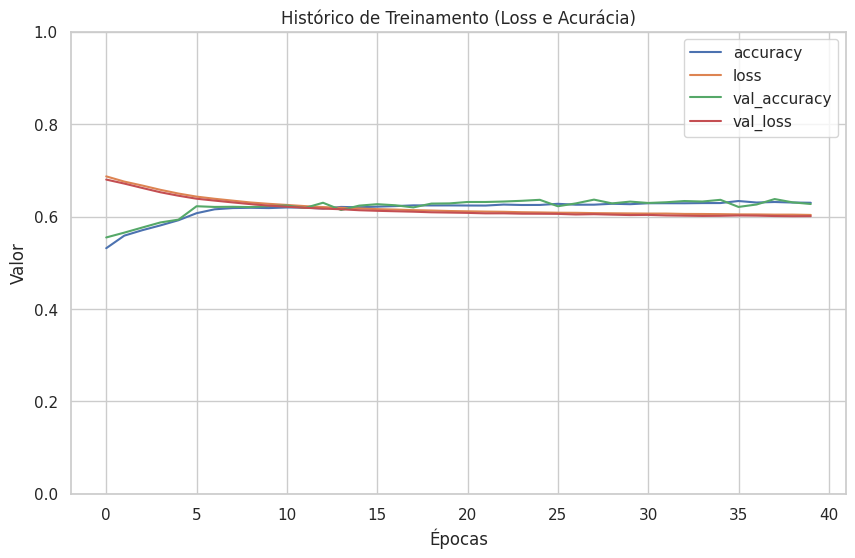

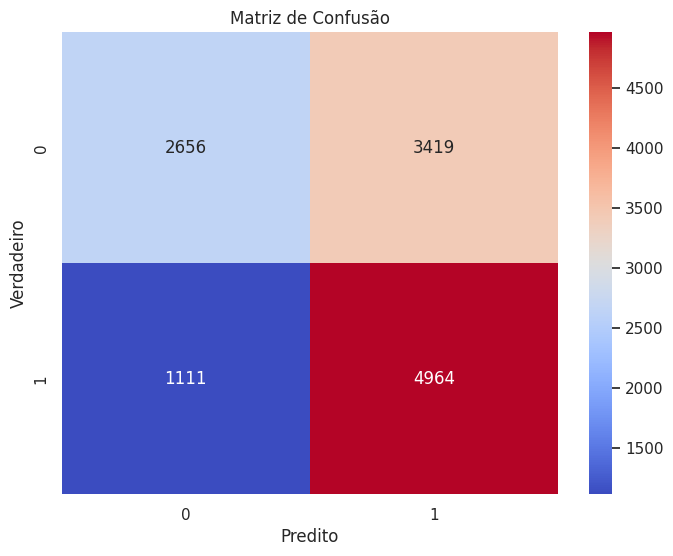


--- Processo Finalizado ---


In [23]:
#Bloqueado por demorar demais
# modelo_treinado_peq_f3, historico_peq_f3 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=40,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6272

F1-Score no conjunto de teste: 0.6867


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.71 | 0.44 | 0.54 | 6075 |
| 1 | 0.59 | 0.82 | 0.69 | 6075 |
| **accuracy** | | | **0.63** | **12150** |
| **macro avg** | 0.65 | 0.63 | 0.61 | 12150 |
| **weighted avg** | 0.65 | 0.63 | 0.61 | 12150 |

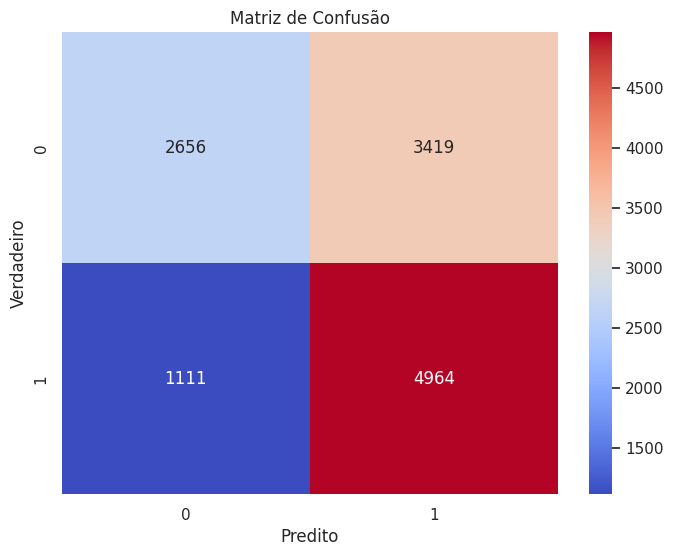


Resumo do Modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 40 épocas com batch_size=32...
Epoch 1/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5270 - loss: 0.6908 - val_accuracy: 0.5604 - val_loss: 0.6686
Epoch 2/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5750 - loss: 0.6636 - val_accuracy: 0.5848 - val_loss: 0.6515
Epoch 3/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5892 - loss: 0.6470 - val_accuracy: 0.6034 - val_loss: 0.6382
Epoch 4/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5999 - loss: 0.6367 - val_accuracy: 0.6187 - val_loss: 0.6281
Epoch 5/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6225 - loss: 0.6243 - val_accuracy: 0.6244 - val_loss: 0.6187
Epoch 6/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6208 - loss: 0.6199 - val_accuracy: 0.6285 - val_loss: 0.6130
Epoch 7/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6292 - loss: 0.6125 - val_accu

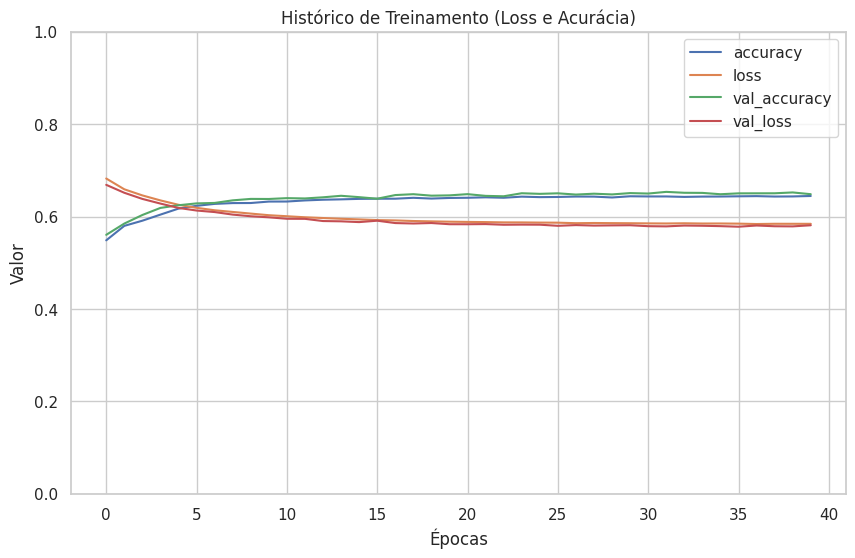

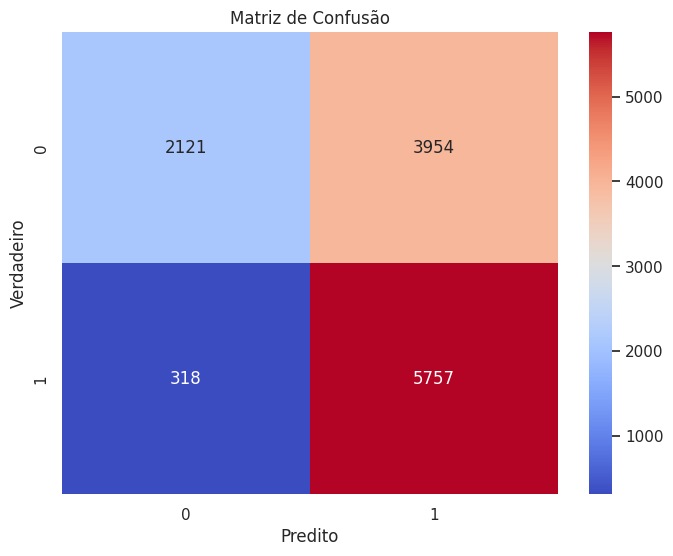


--- Processo Finalizado ---


In [26]:
#Deixei desbloqueado por ter sido escolhidos
modelo_treinado_med_f3, historico_med_f3 = treinar_e_avaliar_rede_neural_med(
    X_train=X_train_scaled5,
    y_train=y_train4,
    X_test=X_test_scaled5,
    y_test=y_test4,
    optimizer='adam',
    loss='binary_crossentropy',
    epochs=40,
    batch_size=32
)

#Resultados parciais

Acurácia no conjunto de teste: 0.6522

F1-Score no conjunto de teste: 0.7354


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.91 | 0.34 | 0.49 | 6075 |
| 1 | 0.59 | 0.97 | 0.74 | 6075 |
| **accuracy** | | | **0.65** | **12150** |
| **macro avg** | 0.75 | 0.65 | 0.61 | 12150 |
| **weighted avg** | 0.75 | 0.65 | 0.61 | 12150 |

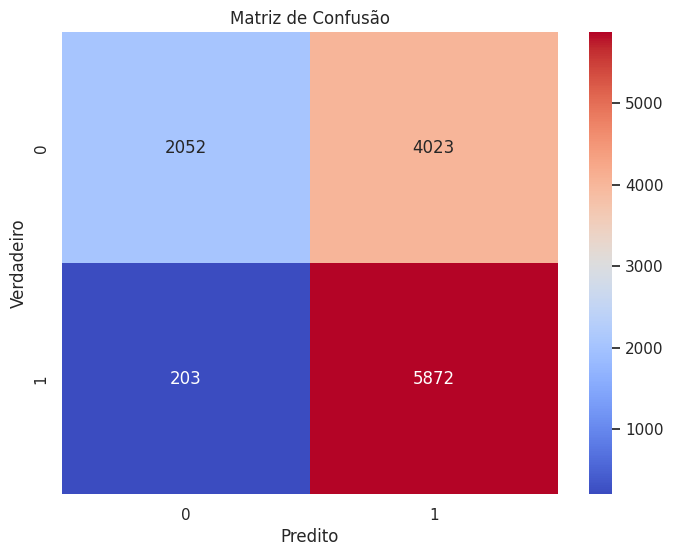


Resumo do Modelo:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 40 épocas com batch_size=32...
Epoch 1/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5461 - loss: 0.6853 - val_accuracy: 0.5798 - val_loss: 0.6507
Epoch 2/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5972 - loss: 0.6422 - val_accuracy: 0.6157 - val_loss: 0.6246
Epoch 3/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6135 - loss: 0.6268 - val_accuracy: 0.6204 - val_loss: 0.6151
Epoch 4/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6220 - loss: 0.6200 - val_accuracy: 0.6224 - val_loss: 0.6111
Epoch 5/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6290 - loss: 0.6133 - val_accuracy: 0.6235 - val_loss: 0.6174
Epoch 6/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6296 - loss: 0.6127 - val_accuracy: 0.6373 - val_loss: 0.6044
Epoch 7/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6347 - loss: 0.6083 - val_accu

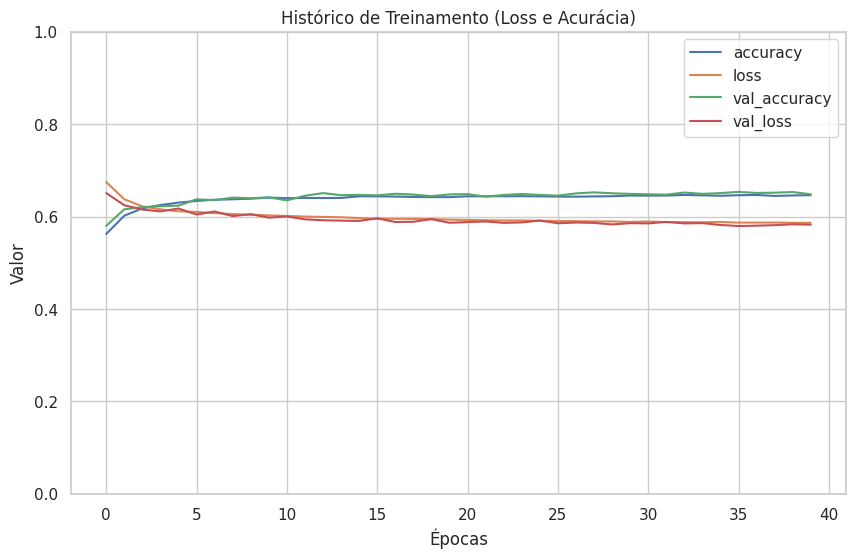

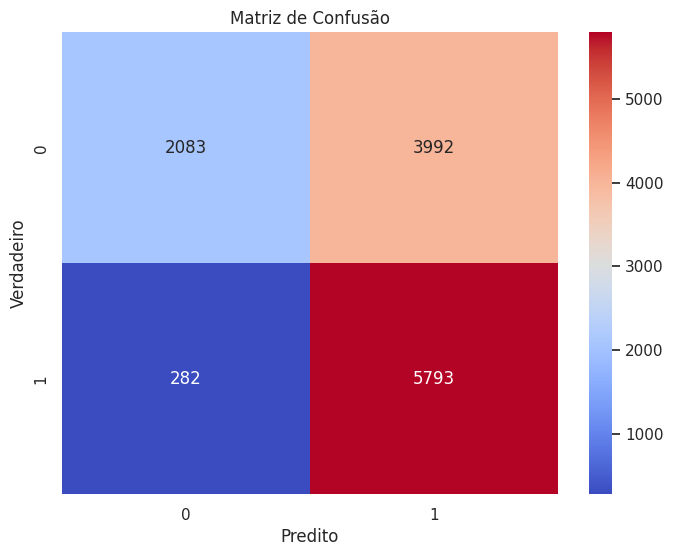


--- Processo Finalizado ---


In [26]:
#Bloqueado por demorar demais
# modelo_treinado_gra_f3, historico_gra_f3 = treinar_e_avaliar_rede_neural_gra(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=40,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6482

F1-Score no conjunto de teste: 0.7305


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.88 | 0.34 | 0.49 | 6075 |
| 1 | 0.59 | 0.95 | 0.73 | 6075 |
| **accuracy** | | | **0.65** | **12150** |
| **macro avg** | 0.74 | 0.65 | 0.61 | 12150 |
| **weighted avg** | 0.74 | 0.65 | 0.61 | 12150 |


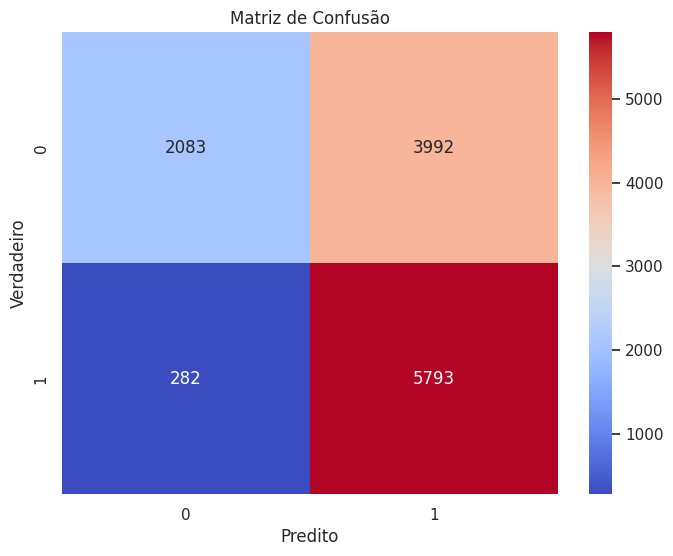


Resumo do Modelo:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 40 épocas com batch_size=64...
Epoch 1/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4915 - loss: 0.7023 - val_accuracy: 0.5197 - val_loss: 0.6919
Epoch 2/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5364 - loss: 0.6881 - val_accuracy: 0.5419 - val_loss: 0.6859
Epoch 3/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5467 - loss: 0.6824 - val_accuracy: 0.5598 - val_loss: 0.6789
Epoch 4/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5617 - loss: 0.6757 - val_accuracy: 0.5602 - val_loss: 0.6742
Epoch 5/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5634 - loss: 0.6716 - val_accuracy: 0.5750 - val_loss: 0.6695
Epoch 6/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5803 - loss: 0.6663 - val_accuracy: 0.5765 - val_loss: 0.6652
Epoch 7/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5794 - loss: 0.6635 - val_accu

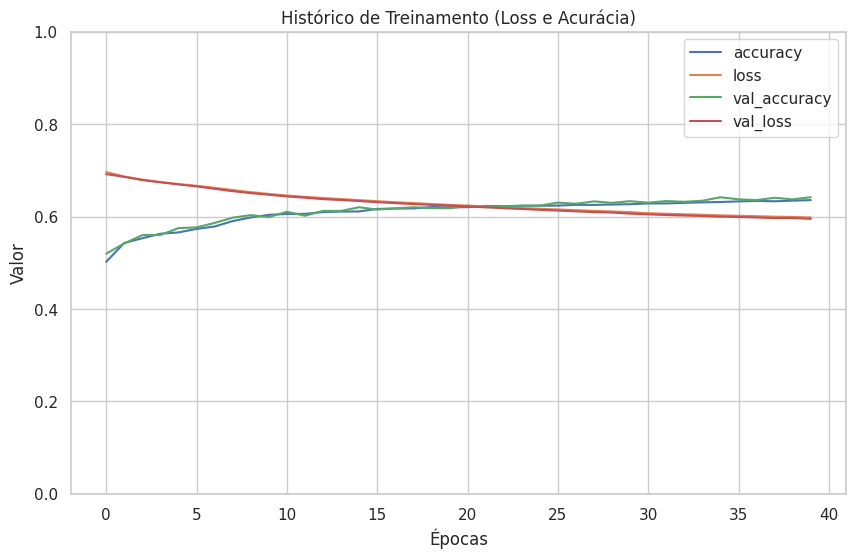

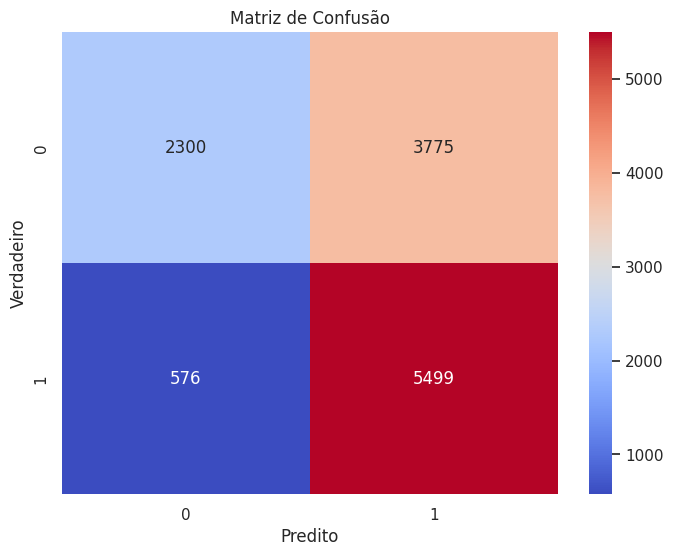


--- Processo Finalizado ---


In [27]:
#Bloqueado por demorar demais
# modelo_treinado_peq_f4, historico_peq_f4 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=40,
#     batch_size=64
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6419

F1-Score no conjunto de teste: 0.7165


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.80 | 0.38 | 0.51 | 6075 |
| 1 | 0.59 | 0.91 | 0.72 | 6075 |
| **accuracy** | | | **0.64** | **12150** |
| **macro avg** | 0.70 | 0.64 | 0.62 | 12150 |
| **weighted avg** | 0.70 | 0.64 | 0.62 | 12150 |


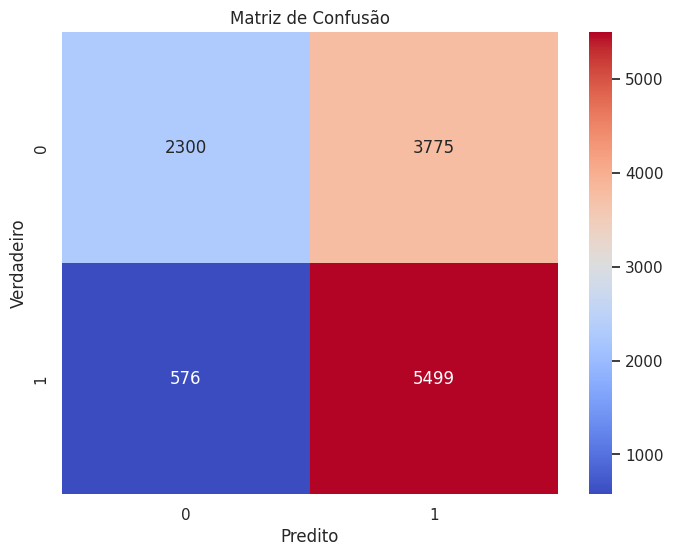


Resumo do Modelo:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='RMSprop' and loss='binary_crossentropy'...

Iniciando o treinamento por 40 épocas com batch_size=64...
Epoch 1/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5305 - loss: 0.6911 - val_accuracy: 0.5657 - val_loss: 0.6862
Epoch 2/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5560 - loss: 0.6840 - val_accuracy: 0.5630 - val_loss: 0.6813
Epoch 3/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5547 - loss: 0.6793 - val_accuracy: 0.5625 - val_loss: 0.6764
Epoch 4/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5632 - loss: 0.6748 - val_accuracy: 0.5603 - val_loss: 0.6726
Epoch 5/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5665 - loss: 0.6710 - val_accuracy: 0.5746 - val_loss: 0.6680
Epoch 6/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5708 - loss: 0.6666 - val_accuracy: 0.5750 - val_loss: 0.6632
Epoch 7/40
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5789 - loss: 0.6611 - val_a

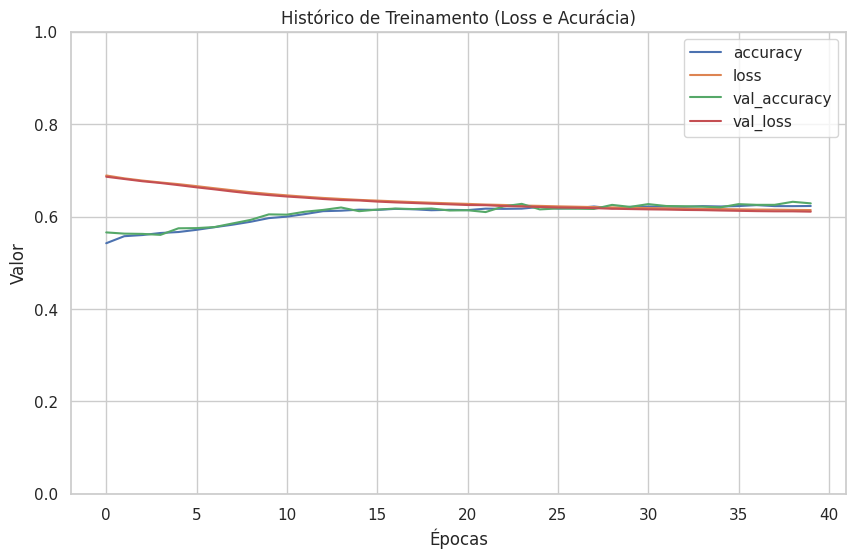

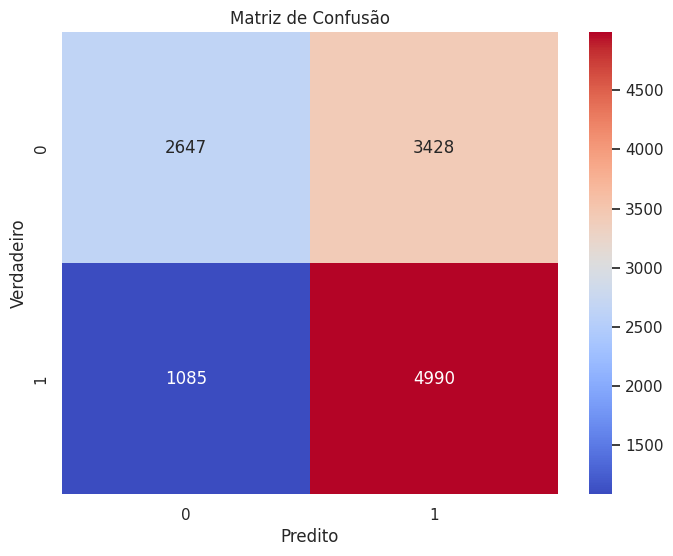


--- Processo Finalizado ---


In [28]:
#Bloqueado por demorar demais
# modelo_treinado_peq_f6, historico_peq_f6 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='RMSprop',
#     loss='binary_crossentropy',
#     epochs=40,
#     batch_size=64
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6286

F1-Score no conjunto de teste: 0.6886



### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.71 | 0.44 | 0.54 | 6075 |
| 1 | 0.59 | 0.82 | 0.69 | 6075 |
| **accuracy** | | | **0.63** | **12150** |
| **macro avg** | 0.65 | 0.63 | 0.61 | 12150 |
| **weighted avg** | 0.65 | 0.63 | 0.61 | 12150 |

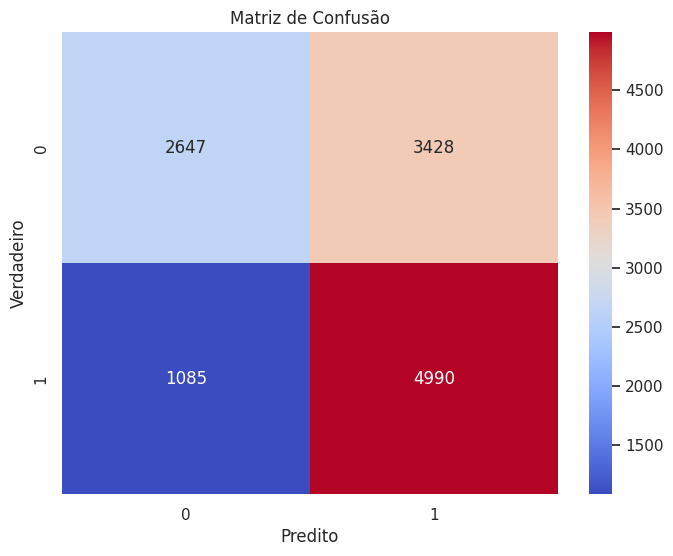


Resumo do Modelo:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 80 épocas com batch_size=32...
Epoch 1/80
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5124 - loss: 0.6936 - val_accuracy: 0.5642 - val_loss: 0.6843
Epoch 2/80
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5607 - loss: 0.6816 - val_accuracy: 0.5513 - val_loss: 0.6790
Epoch 3/80
886/886 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5618 - loss: 0.6775 - val_accuracy: 0.5466 - val_loss: 0.6753
Epoch 4/80
886/886 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5617 - loss: 0.6725 - val_accuracy: 0.5717 - val_loss: 0.6700
Epoch 5/80
886/886 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5718 - loss: 0.6673 - val_accuracy: 0.5744 - val_loss: 0.6648
Epoch 6/80
886/886 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5749 - loss: 0.6631 - val_accuracy: 0.5904 - val_loss: 0.6589
Epoch 7/80
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5926 - loss: 0.6569 - val_accu

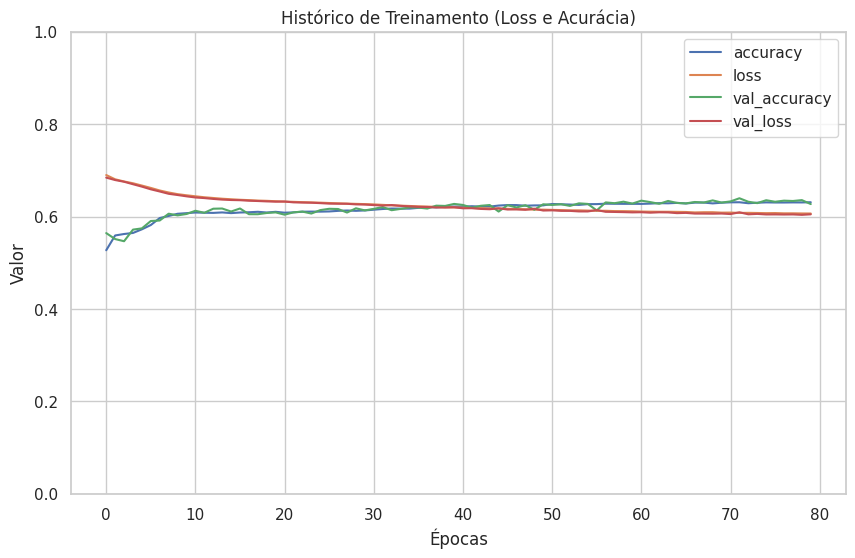

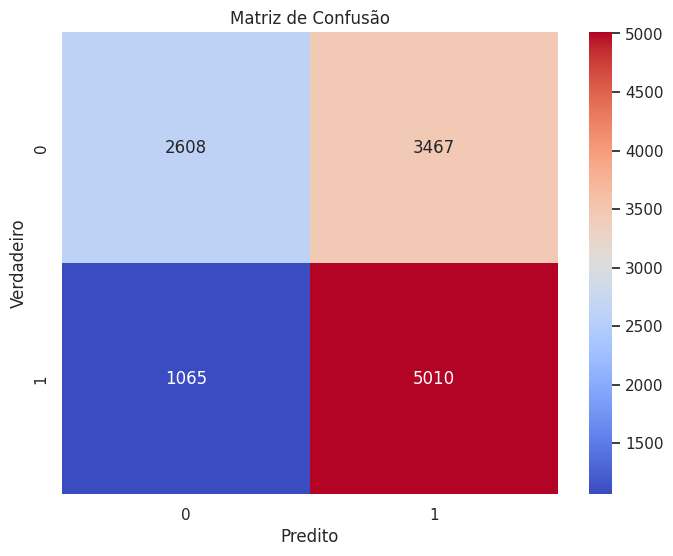


--- Processo Finalizado ---


In [29]:
#Bloqueado por demorar demais
# modelo_treinado_peq_f7, historico_peq_f7 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=80,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6570

F1-Score no conjunto de teste: 0.6886




### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.71 | 0.43 | 0.54 | 6075 |
| 1 | 0.59 | 0.82 | 0.69 | 6075 |
| **accuracy** | | | **0.63** | **12150** |
| **macro avg** | 0.65 | 0.63 | 0.61 | 12150 |
| **weighted avg** | 0.65 | 0.63 | 0.61 | 12150 |


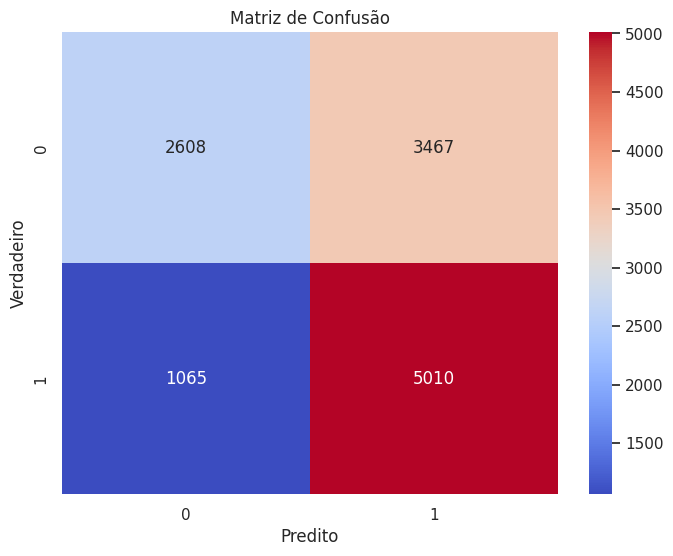

#Análise da rede neural
Para definir qual o melhor modelo, utilizaram-se como critério o valor médio do "f1" e do "recall". Por conseguinte a configuração que deu melhor resultado foi o modelo_treinado_med_f3.

---
**Configurações do modelo**

- Modelo com três layers

 - modelo_treinado_med_f3, historico_med_f3 = treinar_e_avaliar_rede_neural_med(
    X_train=X_train_scaled5,
    y_train=y_train4,
    X_test=X_test_scaled5,
    y_test=y_test4,
    optimizer='adam',
    loss='binary_crossentropy',
    epochs=40,
    batch_size=32
)

In [27]:
#Salvando o modelo e o scaler
joblib.dump(scaler5, 'scaler.pkl')

modelo_treinado_med_f3.save('modelo_neural.keras')

In [ ]:
url_do_modelo = 'https://raw.githubusercontent.com/enakirimoto/Machine-Learning-and-Analytics/refs/heads/main/modelo_final_cart_leaf5.pkl'
!wget -q {url_do_modelo} -O modelo_do_github.pkl
modelo_github = joblib.load('modelo_do_github.pkl')

In [ ]:
url_do_scaler = 'https://raw.githubusercontent.com/enakirimoto/Machine-Learning-and-Analytics/refs/heads/main/scaler.pkl'
!wget -q {url_do_scaler} -O scaler_do_github.pkl
scaler_github = joblib.load('scaler_do_github.pkl')

In [ ]:
dados_novos = pd.DataFrame({
    # Substitua com valores reais para sua previsão
    'Avg VTAT': [25.5],
    'Type_Bike': [0],
    'Type_Go Mini': [0],
    'Type_Go Sedan': [1],
    'Type_Premier Sedan': [0],
    'Type_Uber XL': [0],
    'Type_eBike': [0],
    'cancellation_rate_percent_drop': [15],
    'cancellation_rate_percent_pickup': [20]
})

dados_novos_scaled = scaler_github.transform(dados_novos)
previsao = modelo_github.predict(dados_novos_scaled)
probabilidade = modelo_github.predict_proba(dados_novos_scaled)

print(f"\nResultado da Previsão: {'Corrida será Cancelada' if previsao[0] == 1 else 'Corrida NÃO será Cancelada'}")
print(f"Probabilidade de NÃO Cancelar (Classe 0): {probabilidade[0][0]:.2%}")
print(f"Probabilidade de CANCELAR (Classe 1): {probabilidade[0][1]:.2%}")

#Conclusão
Esse trabalho foi desenvolvido com o objetivo de não se tornar um produto, por conseguinte não havia um requisito claro de acurácia, porém, os resultados encontrados foram extremamente positivos no ponto de vista do desenvolvedor. Entende-se que se esse modelo entrasse em produção, os motoristas disponíveis poderiam ser préviamente classificados e priorizados. Exemplo, focar para enviar as corridas para os motoristas sem risco de cancelamento. Isso gera menos prejuizos para a plataforma e para os usuários.

É sabido que podem ocorrer cenários que todos os motoristas disponíveis tenham riscos elevados, mas sabendo disso, a plataforma pode pensar em benefícios para evitar esse tipo de cancelamento.





In [ ]:
# dx = df.groupby("Cancelled Rides by Driver").
# print(dx)


## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)


In [ ]:
# modelo_02 = keras.Sequential([
# layers.Dense(units=16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
# layers.Dense(units=8, activation='relu'),
# layers.Dense(units=1, activation='sigmoid')
# ])

# modelo_02.summary()

# modelo_02.compile(
# optimizer='adam',
# loss='binary_crossentropy',
# metrics=['accuracy']
# )

# history = modelo_02.fit(
# X_train_scaled,
# y_train2,
# epochs=40,
# batch_size=32,
# validation_data=(X_test_scaled, y_test2),
# verbose=1
# )

# loss, accuracy = modelo_02.evaluate(X_test_scaled, y_test2, verbose=0)
# print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

# y_pred_probs2 = modelo_02.predict(X_test_scaled)
# y_pred_classes2 = (y_pred_probs2 > 0.5).astype(int)

# f12 = f1_score(y_test2, y_pred_classes2)
# print(f"F1-Score no conjunto de teste: {f12:.4f}")

# print("\nRelatório de Classificação Detalhado:")
# print(classification_report(y_test2, y_pred_classes2))

# pd.DataFrame(history.history).plot(figsize =(8, 5))
# plt.grid(True)
# plt.gca().set_ylim(0,1)
# plt.show

#Resultado
# Acurácia no conjunto de teste: 0.6998
# F1-Score no conjunto de teste: 0.0020

# Relatório de Classificação Detalhado:
#               precision    recall  f1-score   support

#            0       0.70      1.00      0.82     14175
#            1       0.38      0.00      0.00      6075

#     accuracy                           0.70     20250
#    macro avg       0.54      0.50      0.41     20250
# weighted avg       0.60      0.70      0.58     20250

In [ ]:
# modelo_03 = keras.Sequential([
# layers.Dense(units=32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
# layers.Dense(units=16, activation='relu'),
# layers.Dense(units=1, activation='sigmoid')
# ])

# modelo_03.summary()

# modelo_03.compile(
# optimizer='adam',
# loss='binary_crossentropy',
# metrics=['accuracy']
# )

# history = modelo_03.fit(
# X_train_scaled,
# y_train2,
# epochs=40,
# batch_size=32,
# validation_data=(X_test_scaled, y_test2),
# verbose=1
# )

# loss, accuracy = modelo_03.evaluate(X_test_scaled, y_test2, verbose=0)
# print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

# y_pred_probs2 = modelo_03.predict(X_test_scaled)
# y_pred_classes2 = (y_pred_probs2 > 0.5).astype(int)

# f12 = f1_score(y_test2, y_pred_classes2)
# print(f"F1-Score no conjunto de teste: {f12:.4f}")

# print("\nRelatório de Classificação Detalhado:")
# print(classification_report(y_test2, y_pred_classes2))

# pd.DataFrame(history.history).plot(figsize =(8, 5))
# plt.grid(True)
# plt.gca().set_ylim(0,1)
# plt.show

#Resultado
# Acurácia no conjunto de teste: 0.6999
# F1-Score no conjunto de teste: 0.0020

# Relatório de Classificação Detalhado:
#               precision    recall  f1-score   support

#            0       0.70      1.00      0.82     14175
#            1       0.40      0.00      0.00      6075

#     accuracy                           0.70     20250
#    macro avg       0.55      0.50      0.41     20250
# weighted avg       0.61      0.70      0.58     20250


In [ ]:
# modelo_04 = keras.Sequential([
# layers.Dense(units=16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
# layers.Dense(units=8, activation='relu'),
# layers.Dense(units=1, activation='sigmoid')
# ])

# modelo_04.summary()

# modelo_04.compile(
# optimizer='RMSprop',
# loss='binary_crossentropy',
# metrics=['accuracy']
# )

# history = modelo_04.fit(
# X_train_scaled,
# y_train2,
# epochs=40,
# batch_size=32,
# validation_data=(X_test_scaled, y_test2),
# verbose=1
# )

# loss, accuracy = modelo_04.evaluate(X_test_scaled, y_test2, verbose=0)
# print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

# y_pred_probs2 = modelo_04.predict(X_test_scaled)
# y_pred_classes2 = (y_pred_probs2 > 0.5).astype(int)

# f12 = f1_score(y_test2, y_pred_classes2)
# print(f"F1-Score no conjunto de teste: {f12:.4f}")

# print("\nRelatório de Classificação Detalhado:")
# print(classification_report(y_test2, y_pred_classes2))

# pd.DataFrame(history.history).plot(figsize =(8, 5))
# plt.grid(True)
# plt.gca().set_ylim(0,1)
# plt.show

#Resultado
# Acurácia no conjunto de teste: 0.6999
# F1-Score no conjunto de teste: 0.0003

# Relatório de Classificação Detalhado:
#               precision    recall  f1-score   support

#            0       0.70      1.00      0.82     14175
#            1       0.25      0.00      0.00      6075

#     accuracy                           0.70     20250
#    macro avg       0.47      0.50      0.41     20250
# weighted avg       0.56      0.70      0.58     20250

In [ ]:
# modelo_05 = keras.Sequential([
# layers.Dense(units=16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
# layers.Dense(units=8, activation='relu'),
# layers.Dense(units=1, activation='sigmoid')
# ])

# modelo_05.summary()

# modelo_05.compile(
# optimizer='adam',
# loss='binary_crossentropy',
# metrics=['accuracy']
# )

# history = modelo_05.fit(
# X_train_scaled,
# y_train2,
# epochs=40,
# batch_size=64,
# validation_data=(X_test_scaled, y_test2),
# verbose=1
# )

# loss, accuracy = modelo_05.evaluate(X_test_scaled, y_test2, verbose=0)
# print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

# y_pred_probs2 = modelo_05.predict(X_test_scaled)
# y_pred_classes2 = (y_pred_probs2 > 0.5).astype(int)

# f12 = f1_score(y_test2, y_pred_classes2)
# print(f"F1-Score no conjunto de teste: {f12:.4f}")

# print("\nRelatório de Classificação Detalhado:")
# print(classification_report(y_test2, y_pred_classes2))

# pd.DataFrame(history.history).plot(figsize =(8, 5))
# plt.grid(True)
# plt.gca().set_ylim(0,1)
# plt.show

#Resultado
# Acurácia no conjunto de teste: 0.7000
# F1-Score no conjunto de teste: 0.0000
# Relatório de Classificação Detalhado:
#               precision    recall  f1-score   support

#            0       0.70      1.00      0.82     14175
#            1       0.00      0.00      0.00      6075

#     accuracy                           0.70     20250
#    macro avg       0.35      0.50      0.41     20250
# weighted avg       0.49      0.70      0.58     20250

In [ ]:

# # Dicionário para armazenar os resultados de cada métrica
# results_f13 = []
# results_precision3 = []
# results_recall3 = []

# # Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
# pipelines3 = []
# results3 = []
# names3 = []


# # Criando os elementos do pipeline
# # Definindo os parâmetros do classificador base para o BaggingClassifier
# base = DecisionTreeClassifier()
# num_trees = 100
# max_features = 3

# # Criando os modelos para o VotingClassifier
# bases = []
# model1 = LogisticRegression(max_iter=200)
# bases.append(('logistic', model1))
# model2 = DecisionTreeClassifier()
# bases.append(('cart', model2))
# model3 = SVC()
# bases.append(('svm', model3))


# kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)
# scoring = ['f1_macro', 'precision_macro', 'recall_macro']

# # Algoritmos que serão utilizados
# reg_log = ('LR', LogisticRegression(max_iter=200))
# knn = ('KNN', KNeighborsClassifier())
# cart = ('CART', DecisionTreeClassifier())
# naive_bayes = ('NB', GaussianNB())
# svm = ('SVM', SVC())
# bagging = ('Bag', BaggingClassifier(estimator=base, n_estimators=num_trees))
# random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
# extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
# adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
# gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
# voting = ('Voting', VotingClassifier(bases))

# # Transformações que serão utilizadas
# standard_scaler = ('StandardScaler', StandardScaler())
# min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# # Montando os pipelines

# # Dataset original
# pipelines3.append(('LR-orig', Pipeline([reg_log])))
# pipelines3.append(('KNN-orig', Pipeline([knn])))
# pipelines3.append(('CART-orig', Pipeline([cart])))
# pipelines3.append(('NB-orig', Pipeline([naive_bayes])))
# pipelines3.append(('SVM-orig', Pipeline([svm])))
# pipelines3.append(('Bag-orig', Pipeline([bagging])))
# pipelines3.append(('RF-orig', Pipeline([random_forest])))
# pipelines3.append(('ET-orig', Pipeline([extra_trees])))
# pipelines3.append(('Ada-orig', Pipeline([adaboost])))
# pipelines3.append(('GB-orig', Pipeline([gradient_boosting])))
# pipelines3.append(('Vot-orig', Pipeline([voting])))

# # Dataset Padronizado
# pipelines3.append(('LR-padr', Pipeline([standard_scaler, reg_log])))
# pipelines3.append(('KNN-padr', Pipeline([standard_scaler, knn])))
# pipelines3.append(('CART-padr', Pipeline([standard_scaler, cart])))
# pipelines3.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
# pipelines3.append(('SVM-padr', Pipeline([standard_scaler, svm])))
# pipelines3.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
# pipelines3.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
# pipelines3.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
# pipelines3.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
# pipelines3.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
# pipelines3.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# # Dataset Normalizado
# pipelines3.append(('LR-norm', Pipeline([min_max_scaler, reg_log])))
# pipelines3.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
# pipelines3.append(('CART-norm', Pipeline([min_max_scaler, cart])))
# pipelines3.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
# pipelines3.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
# pipelines3.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
# pipelines3.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
# pipelines3.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
# pipelines3.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
# pipelines3.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
# pipelines3.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# # Executando os pipelines
# for name, model in pipelines3:
#     cv_results3 = cross_validate(model, X_train3, y_train3, cv=kfold, scoring=scoring)
#     results_f13.append(cv_results3['test_f1_macro'])
#     results_precision3.append(cv_results3['test_precision_macro'])
#     results_recall3.append(cv_results3['test_recall_macro'])
#     names3.append(name)
#     msg = (f"{name}: \n" f"  F1: {cv_results3['test_f1_macro'].mean():.3f} ({cv_results3['test_f1_macro'].std():.3f})\n"
#            f"  Precision: {cv_results3['test_precision_macro'].mean():.3f} ({cv_results3['test_precision_macro'].std():.3f})\n"
#            f"  Recall: {cv_results3['test_recall_macro'].mean():.3f} ({cv_results3['test_recall_macro'].std():.3f})")
#     print(msg)


# # Boxplot de comparação dos modelos
# # Boxplot para F1-Score
# fig_f1 = plt.figure(figsize=(25, 6))
# fig_f1.suptitle('Comparação dos Modelos (F1-Score) - Original, Padronizado e Normalizado')
# ax_f1 = fig_f1.add_subplot(111)
# plt.boxplot(results_f13)
# ax_f1.set_xticklabels(names3, rotation=90)
# ax_f1.set_ylabel('F1-Score (macro)')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

# # Boxplot para Precision
# fig_prec = plt.figure(figsize=(25, 6))
# fig_prec.suptitle('Comparação dos Modelos (Precision) - Original, Padronizado e Normalizado')
# ax_prec = fig_prec.add_subplot(111)
# plt.boxplot(results_precision3)
# ax_prec.set_xticklabels(names3, rotation=90)
# ax_prec.set_ylabel('Precision (macro)')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

# # Boxplot para Recall
# fig_rec = plt.figure(figsize=(25, 6))
# fig_rec.suptitle('Comparação dos Modelos (Recall) - Original, Padronizado e Normalizado')
# ax_rec = fig_rec.add_subplot(111)
# plt.boxplot(results_recall3)
# ax_rec.set_xticklabels(names3, rotation=90)
# ax_rec.set_ylabel('Recall (macro)')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

#Resultado
# LR-orig:
#   F1: 0.482 (0.052)
#   Precision: 0.474 (0.076)
#   Recall: 0.499 (0.016)
# KNN-orig:
#   F1: 0.499 (0.006)
#   Precision: 0.499 (0.006)
#   Recall: 0.499 (0.006)
# CART-orig:
#   F1: 0.588 (0.010)
#   Precision: 0.588 (0.010)
#   Recall: 0.588 (0.010)
# NB-orig:
#   F1: 0.491 (0.012)
#   Precision: 0.495 (0.010)
#   Recall: 0.495 (0.010)
# SVM-orig:
#   F1: 0.365 (0.064)
#   Precision: 0.298 (0.097)
#   Recall: 0.498 (0.003)
# Bag-orig:
#   F1: 0.597 (0.009)
#   Precision: 0.604 (0.009)
#   Recall: 0.601 (0.009)
# RF-orig:
#   F1: 0.600 (0.005)
#   Precision: 0.607 (0.005)
#   Recall: 0.603 (0.005)
# ET-orig:
#   F1: 0.594 (0.006)
#   Precision: 0.597 (0.006)
#   Recall: 0.595 (0.006)
# Ada-orig:
#   F1: 0.598 (0.009)
#   Precision: 0.793 (0.002)
#   Recall: 0.648 (0.006)
# GB-orig:
#   F1: 0.605 (0.008)
#   Precision: 0.773 (0.004)
#   Recall: 0.649 (0.005)
# Vot-orig:
#   F1: 0.497 (0.058)
#   Precision: 0.521 (0.093)
#   Recall: 0.536 (0.023)
# LR-padr:
#   F1: 0.548 (0.007)
#   Precision: 0.548 (0.007)
#   Recall: 0.548 (0.007)
# KNN-padr:
#   F1: 0.579 (0.007)
#   Precision: 0.582 (0.007)
#   Recall: 0.580 (0.007)
# CART-padr:
#   F1: 0.584 (0.007)
#   Precision: 0.584 (0.007)
#   Recall: 0.584 (0.007)
# NB-padr:
#   F1: 0.598 (0.006)
#   Precision: 0.613 (0.009)
#   Recall: 0.605 (0.007)
# SVM-padr:
#   F1: 0.604 (0.008)
#   Precision: 0.648 (0.009)
#   Recall: 0.621 (0.007)
# Bag-padr:
#   F1: 0.599 (0.010)
#   Precision: 0.606 (0.011)
#   Recall: 0.602 (0.010)
# RF-padr:
#   F1: 0.599 (0.008)
#   Precision: 0.607 (0.007)
#   Recall: 0.603 (0.007)
# ET-padr:
#   F1: 0.595 (0.008)
#   Precision: 0.599 (0.008)
#   Recall: 0.597 (0.008)
# Ada-padr:
#   F1: 0.598 (0.009)
#   Precision: 0.793 (0.002)
#   Recall: 0.648 (0.006)
# GB-padr:
#   F1: 0.605 (0.008)
#   Precision: 0.772 (0.003)
#   Recall: 0.650 (0.005)
# Vot-padr:
#   F1: 0.598 (0.007)
#   Precision: 0.611 (0.007)
#   Recall: 0.604 (0.007)
# LR-norm:
#   F1: 0.548 (0.006)
#   Precision: 0.548 (0.006)
#   Recall: 0.548 (0.006)
# KNN-norm:
#   F1: 0.579 (0.009)
#   Precision: 0.581 (0.009)
#   Recall: 0.580 (0.009)
# CART-norm:
#   F1: 0.584 (0.009)
#   Precision: 0.585 (0.009)
#   Recall: 0.585 (0.009)
# NB-norm:
#   F1: 0.598 (0.006)
#   Precision: 0.613 (0.009)
#   Recall: 0.605 (0.007)
# SVM-norm:
#   F1: 0.600 (0.008)
#   Precision: 0.669 (0.008)
#   Recall: 0.626 (0.007)
# Bag-norm:
#   F1: 0.603 (0.010)
#   Precision: 0.611 (0.010)
#   Recall: 0.607 (0.010)
# RF-norm:
#   F1: 0.598 (0.006)
#   Precision: 0.605 (0.006)
#   Recall: 0.602 (0.006)
# ET-norm:
#   F1: 0.596 (0.006)
#   Precision: 0.600 (0.005)
#   Recall: 0.598 (0.005)
# Ada-norm:
#   F1: 0.598 (0.009)
#   Precision: 0.793 (0.002)
#   Recall: 0.648 (0.006)
# GB-norm:
#   F1: 0.605 (0.008)
#   Precision: 0.772 (0.003)
#   Recall: 0.650 (0.005)
# Vot-norm:
#   F1: 0.596 (0.008)
#   Precision: 0.614 (0.008)
#   Recall: 0.605 (0.007)

In [ ]:

# np.random.seed(7) # definindo uma semente global para este bloco

# # Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
# pipelines = []
# results = []
# names = []


# # Criando os elementos do pipeline

# # Algoritmos que serão utilizados
# reg_log = ('LR', LogisticRegression(max_iter=200))
# knn = ('KNN', KNeighborsClassifier())
# cart = ('CART', DecisionTreeClassifier())
# naive_bayes = ('NB', GaussianNB())
# svm = ('SVM', SVC())
# bagging = ('Bag', BaggingClassifier(estimator=base, n_estimators=num_trees))
# random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
# extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
# adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
# gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
# voting = ('Voting', VotingClassifier(bases))

# # Transformações que serão utilizadas
# standard_scaler = ('StandardScaler', StandardScaler())
# min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# # Montando os pipelines

# # Dataset original
# pipelines.append(('LR-orig', Pipeline([reg_log])))
# pipelines.append(('KNN-orig', Pipeline([knn])))
# pipelines.append(('CART-orig', Pipeline([cart])))
# pipelines.append(('NB-orig', Pipeline([naive_bayes])))
# pipelines.append(('SVM-orig', Pipeline([svm])))
# pipelines.append(('Bag-orig', Pipeline([bagging])))
# pipelines.append(('RF-orig', Pipeline([random_forest])))
# pipelines.append(('ET-orig', Pipeline([extra_trees])))
# pipelines.append(('Ada-orig', Pipeline([adaboost])))
# pipelines.append(('GB-orig', Pipeline([gradient_boosting])))
# pipelines.append(('Vot-orig', Pipeline([voting])))

# # Dataset Padronizado
# pipelines.append(('LR-padr', Pipeline([standard_scaler, reg_log])))
# pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
# pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
# pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
# pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))
# pipelines.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
# pipelines.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
# pipelines.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
# pipelines.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
# pipelines.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
# pipelines.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# # Dataset Normalizado
# pipelines.append(('LR-norm', Pipeline([min_max_scaler, reg_log])))
# pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
# pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
# pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
# pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
# pipelines.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
# pipelines.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
# pipelines.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
# pipelines.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
# pipelines.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
# pipelines.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# # Executando os pipelines
# for name, model in pipelines:
#     cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
#     results.append(cv_results)
#     names.append(name)
#     msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
#     print(msg)

# # Boxplot de comparação dos modelos
# fig = plt.figure(figsize=(25,6))
# fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
# ax = fig.add_subplot(111)
# plt.boxplot(results)
# ax.set_xticklabels(names, rotation=90)
# plt.show()

# LR-orig: 0.847 (0.000)
# KNN-orig: 0.828 (0.001)
# CART-orig: 0.748 (0.003)
# NB-orig: 0.847 (0.000)
# SVM-orig: 0.847 (0.000)
# Bag-orig: 0.834 (0.002)
# RF-orig: 0.837 (0.002)
# ET-orig: 0.830 (0.001)
# Ada-orig: 0.847 (0.000)
# GB-orig: 0.847 (0.000)
# Vot-orig: 0.847 (0.000)
# LR-padr: 0.847 (0.000)
# KNN-padr: 0.822 (0.002)
# CART-padr: 0.749 (0.004)
# NB-padr: 0.847 (0.000)
# SVM-padr: 0.847 (0.000)
# Bag-padr: 0.838 (0.002)
# RF-padr: 0.837 (0.002)
# ET-padr: 0.830 (0.001)
# Ada-padr: 0.847 (0.000)
# GB-padr: 0.847 (0.000)
# Vot-padr: 0.847 (0.000)
# LR-norm: 0.847 (0.000)
# KNN-norm: 0.822 (0.001)
# CART-norm: 0.750 (0.003)
# NB-norm: 0.847 (0.000)
# SVM-norm: 0.847 (0.000)
# Bag-norm: 0.837 (0.002)
# RF-norm: 0.837 (0.001)
# ET-norm: 0.830 (0.001)
# Ada-norm: 0.847 (0.000)
# GB-norm: 0.847 (0.000)
# Vot-norm: 0.847 (0.000)



In [ ]:
# import keras
# from keras import layers
# from keras import ops
# from keras.models import Sequential
# from sklearn.metrics import classification_report

# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train2)
# X_test_scaled = scaler.transform(X_test2)

# modelo_01 = keras.Sequential([
#     layers.Dense(units=16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
#     layers.Dense(units=1, activation='sigmoid')
# ])

# modelo_01.summary()

# modelo_01.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# history = modelo_01.fit(
#     X_train_scaled,
#     y_train2,
#     epochs=20,
#     batch_size=32,
#     validation_data=(X_test_scaled, y_test2),
#     verbose=1
# )
# loss, accuracy = modelo_01.evaluate(X_test_scaled, y_test2, verbose=0)
# print(f"Acurácia no conjunto de teste: {accuracy:.4f}")
# y_pred_probs = modelo_01.predict(X_test_scaled)
# y_pred_classes = (y_pred_probs > 0.5).astype(int)
# f1 = f1_score(y_test2, y_pred_classes)
# print(f"F1-Score no conjunto de teste: {f1:.4f}")
# print("\nRelatório de Classificação Detalhado:")
# print(classification_report(y_test2, y_pred_classes))

# pd.DataFrame(history.history).plot(figsize =(8, 5))
# plt.grid(True)
# plt.gca().set_ylim(0,1)
# plt.show

#Resultado
# Acurácia no conjunto de teste: 0.7000
# F1-Score no conjunto de teste: 0.0000

# Relatório de Classificação Detalhado:
#               precision    recall  f1-score   support

#            0       0.70      1.00      0.82     14175
#            1       0.00      0.00      0.00      6075

#     accuracy                           0.70     20250
#    macro avg       0.35      0.50      0.41     20250
# weighted avg       0.49      0.70      0.58     20250



## 1. Escopo, objetivo e definição do problema
**TODO:** Explique brevemente:
- Contexto do problema e objetivo (ex.: previsão de churn, detecção de fraude, previsão de demanda, segmentação de clientes etc.).  
- Tipo de tarefa: **classificação**, **regressão**, **clusterização** ou **séries temporais (forecasting)**.  
- Área de aplicação: visão computacional, NLP, dados tabulares, sensores, etc.  
- Valor para o negócio/usuário.



## 2. Reprodutibilidade e ambiente
Especifique o ambiente. Por exemplo:
- Bibliotecas usadas.
- Seeds fixas para reprodutibilidade.

In [ ]:
# === Setup básico e reprodutibilidade ===
import os, random, time, sys, math
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score)

from sklearn.model_selection import StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Para frameworks que suportam seed adicional (ex.: PyTorch/TensorFlow), documente aqui:
# import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# import tensorflow as tf; tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

Python: 3.12.11
Seed global: 42



### 2.1 Dependências (opcional)
Instale pacotes extras se necessário. **Mantenha o projeto enxuto** para facilitar a correção.


In [ ]:

# Exemplo: descomente o que precisar
# !pip install -q scikit-learn imbalanced-learn xgboost lightgbm catboost optuna
# !pip install -q pandas-profiling ydata-profiling
# !pip install -q matplotlib seaborn plotly
# !pip install -q statsmodels pmdarima


### 2.2 Funções python (opcional)
Defina, se necessário, funções em Python para reutilizar seu código e torná-lo mais organizado. Essa é uma boa prática de programação que facilita a leitura, manutenção e evolução do seu projeto.

In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    auc = roc_auc_score(y_true, proba[:,1]) if (proba is not None and proba.shape[1]==2) else np.nan
    return {"accuracy": acc, "f1_weighted": f1w, "roc_auc": auc}

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

def evaluate_clustering(X_original, model):
    # Silhouette requer >1 cluster e dados transformados
    try:
        if hasattr(model.named_steps["pre"], "transform"):
            X_emb = model.named_steps["pre"].fit_transform(X_original)  # cuidado: apenas para demo
        else:
            X_emb = X_original
        labels = model.named_steps["model"].fit_predict(X_emb)
        sil = silhouette_score(X_emb, labels)
        return {"silhouette": sil}
    except Exception as e:
        return {"silhouette": np.nan, "erro": str(e)}


## 3. Dados: carga, entendimento e qualidade
**TODO:** descreva a origem dos dados, dicionário de variáveis e licença/ética quando aplicável.  
Evite **vazamento de dados**. Se usar feature store ou dados sintéticos, explique.


In [ ]:

# === Carga dos dados ===

# Exemplo:
# df = pd.read_csv('dados.csv')

# Placeholder para não quebrar o template:
df = pd.DataFrame({
    "feature_num_1": np.random.normal(size=500),
    "feature_num_2": np.random.uniform(0, 10, size=500),
    "feature_cat_1": np.random.choice(["A","B","C"], size=500),
    "target_reg": np.random.normal(loc=50, scale=10, size=500),
    "target_clf": np.random.choice([0,1], size=500, p=[0.6,0.4]),
    "timestamp": pd.date_range('2024-01-01', periods=500, freq='D')
})
df.head()


,feature_num_1,feature_num_2,feature_cat_1,target_reg,target_clf,timestamp
0,0.496714,6.459172,B,46.969684,1,2024-01-01
1,-0.138264,5.707783,A,49.652967,1,2024-01-02
2,0.647689,3.560967,C,38.115133,0,2024-01-03
3,1.523030,9.865152,C,53.120794,1,2024-01-04
4,-0.234153,6.057748,C,62.691772,1,2024-01-05


In [ ]:

# === Verificações iniciais ===
display(df.sample(5))
print("\nFormato:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())


,feature_num_1,feature_num_2,feature_cat_1,target_reg,target_clf,timestamp
334,0.975120,2.721451,A,66.389408,0,2024-11-30
485,-1.422254,5.657320,C,42.705453,1,2025-04-30
444,-1.304470,8.837859,C,64.385425,1,2025-03-20
196,-0.883857,2.051396,B,44.071721,1,2024-07-15
242,0.504987,2.078863,C,25.682864,1,2024-08-30



Formato: (500, 6)

Tipos:
feature_num_1           float64
feature_num_2           float64
feature_cat_1            object
target_reg              float64
target_clf                int64
timestamp        datetime64[ns]
dtype: object

Valores ausentes por coluna:
feature_num_1    0
feature_num_2    0
feature_cat_1    0
target_reg       0
target_clf       0
timestamp        0
dtype: int64



### 3.1 Análise exploratória resumida (EDA)
**TODO:** inclua gráficos e tabelas essenciais para entender o problema e levantar hipóteses.  
Evite EDA muito extensa — foque no que afeta as decisões de modelagem.


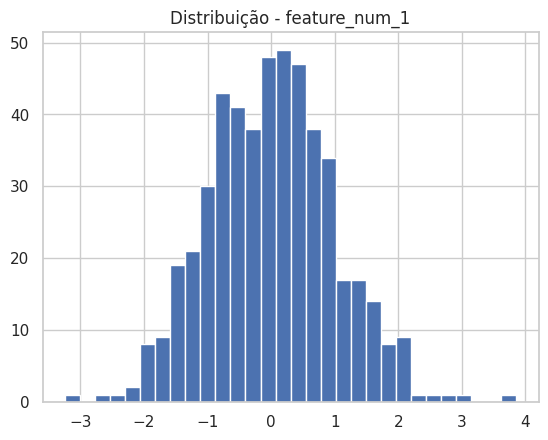

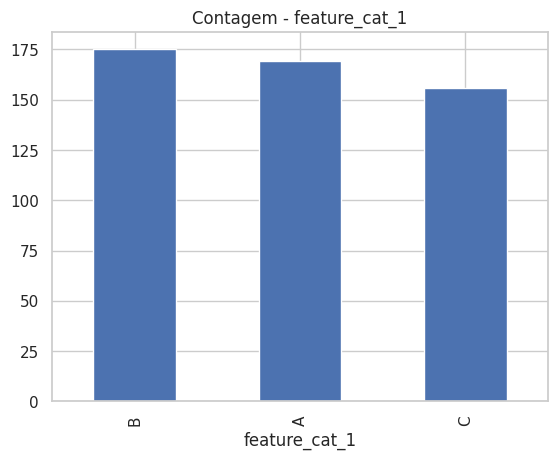

In [ ]:
# Histograma numérico (exemplo)
_ = df["feature_num_1"].hist(bins=30)
plt.title("Distribuição - feature_num_1")
plt.show()

# Contagem categórica (exemplo)
_ = df["feature_cat_1"].value_counts().plot(kind="bar")
plt.title("Contagem - feature_cat_1")
plt.show()



## 4. Definição do target, variáveis e divisão dos dados
**TODO:** escolha o **target** (ou defina a tarefa de clusterização/forecast).  
- Em **séries temporais**, **não embaralhe** e use divisões temporais (ex.: `TimeSeriesSplit`).
- Em **classificação desequilibrada**, considere **estratégias para desbalanceamento** (ex.: `class_weight`, undersampling/oversampling).

> **Atenção:** Todas as **transformações** aprendidas devem ser **ajustadas no treino** e **aplicadas no validação/teste**. Recomendamos usar **pipelines**.


In [ ]:
# Selecione o tipo de problema: 'classificacao' | 'regressao' | 'clusterizacao' | 'serie_temporal'
PROBLEM_TYPE = "classificacao"  # TODO: ajuste

# Defina features e target conforme o problema
if PROBLEM_TYPE == "classificacao":
    target = "target_clf"
    features = [c for c in df.columns if c not in [target, "timestamp"]]
elif PROBLEM_TYPE == "regressao":
    target = "target_reg"
    features = [c for c in df.columns if c not in [target, "timestamp"]]
elif PROBLEM_TYPE == "clusterizacao":
    target = None
    features = [c for c in df.columns if c not in ["target_clf","target_reg","timestamp"]]
elif PROBLEM_TYPE == "serie_temporal":
    target = "target_reg"  # Exemplo
    features = [c for c in df.columns if c not in [target]]
else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))

# Divisão dos dados
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y if PROBLEM_TYPE=="classificacao" else None
    )
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    # Sem target — você pode reservar um hold-out para avaliação externa se fizer sentido de negócio.
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "serie_temporal":
    # Ordenar por tempo e criar cortes temporais (exemplo simples hold-out temporal)
    df_sorted = df.sort_values("timestamp")
    cutoff = int(len(df_sorted)*0.8)
    train, test = df_sorted.iloc[:cutoff], df_sorted.iloc[cutoff:]
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test   = test.drop(columns=[target]),  test[target]
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

PROBLEM_TYPE: classificacao
Target: target_clf
N features: 4
Treino: (400, 4) | Teste: (100, 4)



## 5. Tratamento de dados e **Pipeline** de pré-processamento
Crie um **Pipeline** com as etapas necessárias (limpeza, imputação, encoding, escala, seleção de atributos, etc.)  
Isso garante **reprodutibilidade** e evita **vazamento**.


In [ ]:
num_cols = [c for c in X_train.columns if str(X_train[c].dtype).startswith(("float","int"))]
cat_cols = [c for c in X_train.columns if c not in num_cols and c != "timestamp"]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("num_cols:", num_cols[:5], "...")
print("cat_cols:", cat_cols[:5], "...")

num_cols: ['feature_num_1', 'feature_num_2', 'target_reg'] ...
cat_cols: ['feature_cat_1'] ...



## 6. Baseline e modelos candidatos
Se possivek, comece com uma **baseline simples** (ex.: DummyClassifier/Regressor) e evolua para modelos mais fortes. O baseline pode ser seu primeiro modelo!  

**Compare** ao menos **duas abordagens**.

> Para **deep learning** (visão computacional/NLP/séries), crie uma seção específica (p. ex., `TensorFlow`/`PyTorch`) e documente arquitetura, parâmetros e tempo de treino.


In [ ]:
# === Baselines ===
if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))])
    candidates = {
        "LogisticRegression": Pipeline([("pre", preprocess), ("model", LogisticRegression(max_iter=200, random_state=SEED))]),
        "RandomForest": Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))])
    }
elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyRegressor(strategy="median"))])
    candidates = {
        "Ridge": Pipeline([("pre", preprocess), ("model", Ridge(random_state=SEED))]),
        "RandomForestReg": Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    }
elif PROBLEM_TYPE == "clusterizacao":
    # baseline não se aplica diretamente; use um método simples (ex.: KMeans com k fixo) como referência.
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", KMeans(n_clusters=3, random_state=SEED))])
    candidates = {
        "KMeans_k3": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=3, random_state=SEED))]),
        "KMeans_k5": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=5, random_state=SEED))])
    }
elif PROBLEM_TYPE == "serie_temporal":
    # Em séries temporais, a baseline pode ser "naive" (último valor) — aqui, apenas um placeholder.
    # Para modelos clássicos, pode considerar por exemplo Regressores com janelas (feature engineering temporal).
    baseline = None
    candidates = {}
else:
    raise ValueError("PROBLEM_TYPE inválido.")

baseline


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['feature_num_1',
                                                   'feature_num_2',
                                                   'target_reg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['feature_cat_1'])])),
                ('model',
                 DummyClassifier(random_state=42, strategy='most_frequent'))])


### 6.1 Treino e avaliação rápida (baseline vs candidatos)
Use **métricas adequadas** ao tipo de problema. Documente suas observações.


In [ ]:
results = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    t1 = time.time()
    if PROBLEM_TYPE == "classificacao":
        y_pred = baseline.predict(X_test)
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        y_pred = baseline.predict(X_test)
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(t1 - t0, 3)

    # Candidatos
    for name, pipe in candidates.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        t1 = time.time()
        if PROBLEM_TYPE == "classificacao":
            y_pred = pipe.predict(X_test)
            proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            y_pred = pipe.predict(X_test)
            results[name] = evaluate_regression(y_test, y_pred)
        results[name]["train_time_s"] = round(t1 - t0, 3)

elif PROBLEM_TYPE == "clusterizacao":
    # Baseline e candidatos (ex.: silhouette)
    # Observação: em um projeto real, evite refit em dados de teste fora de validação apropriada.
    results["baseline"] = evaluate_clustering(X_test, baseline)
    for name, pipe in candidates.items():
        results[name] = evaluate_clustering(X_test, pipe)

elif PROBLEM_TYPE == "serie_temporal":
    # TODO: implemente métricas específicas (ex.: MAE/MAPE/RMSE out-of-time)
    results["baseline_naive"] = {"MAE": None, "MAPE": None, "RMSE": None, "obs": "Implementar baseline temporal."}

pd.DataFrame(results).T


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.60,0.450000,0.500000,0.020
LogisticRegression,0.57,0.465415,0.550000,0.041
RandomForest,0.57,0.549299,0.543333,0.250



## 7. Validação e Otimização de Hiperparâmetros
Use **validação cruzada** apropriada ao problema (Ex: **`StratifiedKFold`** para classificação; **`KFold`** para regressão).  
Faça **tuning** com `GridSearchCV`/`RandomizedSearchCV`.


In [ ]:
if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model = Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scorer = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model = Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scorer = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "clusterizacao":
    # Clusterização: tuning diferente (ex.: número de clusters). Métricas internas (silhouette) ou externas (se houver rótulos).
    cv = None
    model = Pipeline([("pre", preprocess), ("model", KMeans(random_state=SEED))])
    param_dist = {"model__n_clusters": randint(2, 10)}
    scorer = None

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    # Ex.: usar um regressor com janelas/defasagens previamente criadas
    model = Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 300),
        "model__max_depth": randint(3, 15)
    }
    scorer = "neg_mean_absolute_error"

# Executar busca aleatória (exemplo geral — ajuste para seu caso)
if PROBLEM_TYPE != "clusterizacao":
    search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, cv=cv, scoring=scorer, random_state=SEED, n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    print("Melhor score (CV):", search.best_score_)
    print("Melhores parâmetros:", search.best_params_)
else:
    print("Para clusterização, avalie k em um range e compare silhouette/indíces de validade. Ex.: varra k de 2 a 10.")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor score (CV): 0.5402276617001536
Melhores parâmetros: {'model__max_depth': 14, 'model__min_samples_split': 2, 'model__n_estimators': 148}



## 8. Avaliação final, análise de erros e limitações
- **Compare** baseline vs melhor modelo.  
- Faça **análise de erros** (ex.: matriz de confusão, casos pior previstos, resíduos).  
- Discuta **limitações**: dados, métricas, viés, generalização.


              precision    recall  f1-score   support

           0       0.60      0.72      0.65        60
           1       0.39      0.28      0.32        40

    accuracy                           0.54       100
   macro avg       0.50      0.50      0.49       100
weighted avg       0.52      0.54      0.52       100



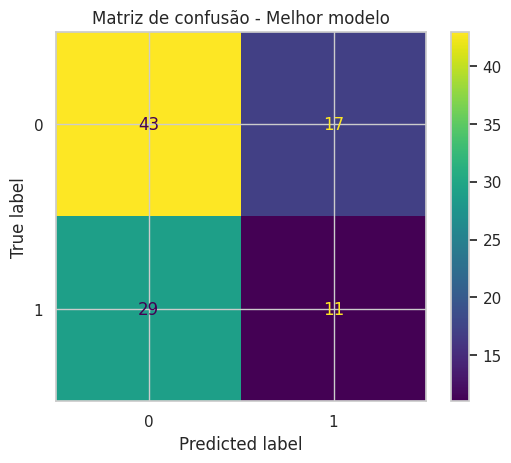

In [ ]:
# Exemplo de re-treino no conjunto de treino+validação (se aplicável) e avaliação no teste

if PROBLEM_TYPE in ["classificacao", "regressao"] and 'search' in globals() and hasattr(search, "best_estimator_"):
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        from sklearn.metrics import classification_report, ConfusionMatrixDisplay
        print(classification_report(y_test, y_pred))
        try:
            ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
            plt.title("Matriz de confusão - Melhor modelo")
            plt.show()
        except Exception as e:
            print("Não foi possível plotar a matriz de confusão:", e)
    else:
        print('Metricas para avaliar a regressão: ', evaluate_regression(y_test, y_pred))
elif PROBLEM_TYPE == "clusterizacao":
    print("Realize análise qualitativa/negócio dos clusters. Visualize centros e perfis.")
elif PROBLEM_TYPE == "serie_temporal":
    print("Avalie métricas fora do tempo; plote série real vs prevista.")


## 9. Engenharia de atributos (detalhe)
**TODO:** Documente as escolhas: seleção/extração, encoding, criação de variáveis temporais (lags, médias móveis), TF-IDF/embeddings (NLP), augmentations (visão), etc.



## 10. (Opcional) Deep Learning / Fine-tuning
Se usar DL, descreva: arquitetura, hiperparâmetros, _early stopping_, tamanho do batch, épocas, e se houve **fine-tuning** de modelos pré-treinados.



## 11. Boas práticas e rastreabilidade
- **Baseline** claro e justificativas para melhorias.  
- **Pipelines** (evitar vazamento).  
- **Decisões de projeto** documentadas (o que tentou e por quê).



## 12. Conclusões e próximos passos
**TODO:** Resuma resultados, trade-offs, e proponha melhorias futuras (mais dados, features, modelos, tuning).



## 13. Salvando artefatos (modelos e pipeline)
Se o treinamento dos modelos demora mais de 3 minutos, recomendamos salvar o **modelo/pipeline** após o treinamento e depois apenas carregar o arquivo (ex: .pkl, .h5) salvo em outra célula, sem precisar treinar novamente.  